# Pipeline de Análise Empírica — Benchmarking e Telemetria de Hardware

**Disciplina:** Arquitetura e Organização de Computadores
**Curso:** Engenharia de Computação — UFPA (Campus Universitário de Tucuruí)
**Professor orientador:** Prof. Dr. Iago Medeiros

Este notebook orquestra o pipeline completo de análise dos dados experimentais
coletados pelo grupo em **4 (ou mais) máquinas** distintas, cada uma submetida a
**20 rodadas** do *Geekbench 6* com telemetria simultânea via **HWiNFO64**.

O notebook é dividido nas seguintes etapas:

1. Configuração do ambiente e localização da estrutura de pastas do projeto.
2. **Verificação de completude dos dados** (cada máquina deveria ter, no
   máximo, 1 arquivo `.txt` de scores + 20 arquivos `.csv` de telemetria).
3. Análise estatística dos **resultados de benchmark** (Single-Core / Multi-Core).
4. Análise estatística da **telemetria de hardware** (clock, temperatura,
   potência, throttling, memória).
5. **Cruzamento arquitetural**: Desempenho por Watt e IPC relativo.
6. Geração dos **gráficos no padrão visual da SBC** (escala de cinza, sóbrio).
7. Exportação das tabelas consolidadas para uso direto no artigo (LaTeX/SBC).

> **Importante:** o pipeline foi projetado para funcionar mesmo com dados
> **parciais** (máquinas com menos de 20 rodadas, ou ainda sem nenhum dado).
> Sempre que uma máquina/rodada estiver incompleta, um aviso é exibido no
> log, mas a execução **não é interrompida** — a análise é refeita
> automaticamente conforme novos arquivos forem adicionados às pastas em
> `data/raw/machine_x`.


## Etapa 0 — Configuração do ambiente

Adicionamos a pasta `src/` ao `sys.path` para podermos importar os 4 módulos
do pipeline (`utils_utils`, `benchmark_analysis`, `telemetry_analysis`,
`plotting_engine`) como se fossem bibliotecas comuns.


In [70]:
# Recarregamento automático ao editar os .py
%reload_ext autoreload
#%load_ext autoreload
%autoreload 2

In [71]:
import importlib.util
import subprocess
import sys
from pathlib import Path

# =====================================================================
# 1. RESOLUÇÃO DE CAMINHOS DO PROJETO (MANUTENÇÃO DO SEU FLUXO)
# =====================================================================

diretorio_atual = Path.cwd()

RAIZ_PROJETO = diretorio_atual
for pai in [diretorio_atual] + list(diretorio_atual.parents):
    if pai.name == "aoc-empirical-benchmark":  # 🎯 Trava no nome exato da pasta raiz
        RAIZ_PROJETO = pai
        break

CAMINHO_SRC = RAIZ_PROJETO / "src"

if str(CAMINHO_SRC) not in sys.path:
    sys.path.insert(0, str(CAMINHO_SRC))

print("Raiz do projeto detectada em:", RAIZ_PROJETO)
print("Pasta 'src' adicionada ao sys.path:", CAMINHO_SRC)

Raiz do projeto detectada em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark
Pasta 'src' adicionada ao sys.path: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\src


In [72]:
# =====================================================================
# 2. VERIFICAÇÃO E INSTALAÇÃO DE DEPENDÊNCIAS (SOLUÇÃO JINJA2 + GRÁFICOS)
# =====================================================================
PACOTES_REQUISITOS = ["pandas", "numpy", "jinja2", "matplotlib", "seaborn"]

print("\nVerificando dependências do pipeline...")
for pacote in PACOTES_REQUISITOS:
    if importlib.util.find_spec(pacote) is None:
        print(f" 📦 Pacote '{pacote}' não encontrado. Instalando agora...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pacote, "--quiet"])
    else:
        print(f" ✅ Pacote '{pacote}' já está instalado.")


Verificando dependências do pipeline...
 ✅ Pacote 'pandas' já está instalado.
 ✅ Pacote 'numpy' já está instalado.
 ✅ Pacote 'jinja2' já está instalado.
 ✅ Pacote 'matplotlib' já está instalado.
 ✅ Pacote 'seaborn' já está instalado.


In [73]:
# =====================================================================
# 3. IMPORTAÇÃO DOS MÓDULOS E CONFIGURAÇÃO DO AMBIENTE
# =====================================================================
import pandas as pd
import numpy as np

# Importações dos módulos internos (agora garantidos pelo sys.path acima)
import utils_utils as u
import benchmark_analysis as bench
import telemetry_analysis as tele
import plotting_engine as plot

# Configurações de exibição do Pandas
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 160)

# Inicialização do estilo científico de gráficos
plot.configurar_estilo_sbc()
print("\n🚀 Todos os módulos e dependências foram carregados com sucesso.")


🚀 Todos os módulos e dependências foram carregados com sucesso.


## Etapa 1 — Verificação da estrutura e completude dos dados

Antes de qualquer análise, **validamos a coleta**: cada pasta `data/raw/machine_x`
deve conter, no máximo, **20 arquivos `.csv`/`.CSV`** (1 por rodada de telemetria) e
**1 arquivo `.txt`** (scores consolidados do Geekbench 6) — **21 arquivos no total**.

O pipeline aceita **menos** arquivos (coleta ainda em andamento) mas emite um
**alerta** caso encontre **mais** do que o esperado (sinal de erro na coleta,
como rodadas duplicadas ou arquivos de outra máquina na pasta errada).

> Edite `NOMES_EXIBICAO` abaixo conforme as máquinas forem identificadas
> (ex.: notebook da Roberta, desktop do laboratório etc.).


In [74]:
# Mapeamento opcional: nome da pasta -> nome de exibição (use nos gráficos/tabelas)
NOMES_EXIBICAO = {
    "machine_a": "Máquina A",
    "machine_b": "Máquina B",
    "machine_c": "Máquina C",
    "machine_d": "Máquina D",
    "machine_e": "Máquina E",
    "machine_f": "Máquina F",
}

caminhos = u.obter_caminhos(str(RAIZ_PROJETO))
relatorios = u.verificar_estrutura_diretorios(caminhos)

if not relatorios:
    print(
        "Nenhuma pasta 'machine_*' encontrada em data/raw/. "
        "Verifique se os dados já foram adicionados ao repositório."
    )
else:
    df_completude = u.exibir_relatorio_completude(relatorios)
    display(df_completude)


[16:12:44] INFO     | aoc_pipeline | machine_a    | TXT: 1/1 | CSV: 20/20 | Completude: 100.0% | OK (completa)
[16:12:44] INFO     | aoc_pipeline | machine_b    | TXT: 1/1 | CSV: 20/20 | Completude: 100.0% | OK (completa)
[16:12:44] INFO     | aoc_pipeline | machine_c    | TXT: 1/1 | CSV: 20/20 | Completude: 100.0% | OK (completa)
[16:12:44] INFO     | aoc_pipeline | machine_d    | TXT: 1/1 | CSV: 20/20 | Completude: 100.0% | OK (completa)
[16:12:44] INFO     | aoc_pipeline | machine_e    | TXT: 1/1 | CSV: 20/20 | Completude: 100.0% | OK (completa)
[16:12:44] INFO     | aoc_pipeline | machine_f    | TXT: 1/1 | CSV: 20/20 | Completude: 100.0% | OK (completa)
[16:12:44] INFO     | aoc_pipeline | machine_g    | TXT: 0/1 | CSV:  1/20 | Completude:   4.8% | INCOMPLETA/ATENÇÃO
[16:12:44] WARNING  | aoc_pipeline |   -> [machine_g] Nenhum arquivo .txt de scores (Geekbench) encontrado nesta máquina.
[16:12:44] WARNING  | aoc_pipeline |   -> [machine_g] Dados parciais: faltam 19 arquivo(s) CSV d

,maquina,arquivos_txt,arquivos_csv,total_arquivos,percentual_completude,completa,qtd_alertas
0,machine_a,1,20,21,100.0,True,0
1,machine_b,1,20,21,100.0,True,0
2,machine_c,1,20,21,100.0,True,0
3,machine_d,1,20,21,100.0,True,0
4,machine_e,1,20,21,100.0,True,0
5,machine_f,1,20,21,100.0,True,0
6,machine_g,0,1,1,4.8,False,2


In [75]:
# Tabela de completude pronta para exportação (ex.: anexo metodológico do artigo)
if relatorios:
    caminho_saida = caminhos.dados_processed / "relatorio_completude.csv"
    df_completude.to_csv(caminho_saida, index=False, encoding="utf-8")
    print(f"Relatório de completude salvo em: {caminho_saida}")


Relatório de completude salvo em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\relatorio_completude.csv


In [76]:
import re
from pathlib import Path
import pandas as pd

# =====================================================================
# 1. MAPEAMENTO DAS PASTAS DE ORIGEM E DESTINO
# =====================================================================
PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

# Garante que a pasta principal de resultados ('processed') exista
PASTA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Lista automaticamente todas as subpastas de origem que começam com "machine_"
pastas_maquinas_origem = [p for p in PASTA_RAW.iterdir() if p.is_dir() and p.name.startswith("machine_")]

print(f"Raiz do projeto: {RAIZ_PROJETO}")
print(f"Diretório de destino configurado em: {PASTA_PROCESSED}\n")

# Lista global para acumular os dados e gerar o relatório unificado final
lista_global_todas_maquinas = []

# =====================================================================
# 2. PROCESSAMENTO INDIVIDUAL POR MÁQUINA
# =====================================================================
for pasta_maquina in pastas_maquinas_origem:
    nome_pasta_maquina = pasta_maquina.name  # Ex: "machine_a"
    print(f"=== Processando {nome_pasta_maquina.upper()} ===")
    
    # Coleta os arquivos .csv de origem daquela máquina
    arquivos = list(pasta_maquina.glob("*.csv"))
    lista_dataframes_maquina = []
    
    # Extrai o sufixo ou letra da máquina baseado no nome da pasta (ex: machine_a -> A)
    sufixo_maquina = nome_pasta_maquina.replace("machine_", "").upper()
    
    for caminho_arquivo in arquivos:
        # Ignora arquivos de saídas antigas perdidos na pasta raw, se houver
        if "consolidada" in caminho_arquivo.name.lower():
            continue
            
        # Lê o arquivo completo de forma segura
        df = pd.read_csv(
            caminho_arquivo, 
            encoding="utf-8", 
            on_bad_lines='skip', 
            encoding_errors='replace',
            low_memory=False
        )
        
        # CORTA AS DUAS ÚLTIMAS LINHAS (Slicing do Pandas)
        df = df.iloc[:-2].copy()
        
        # Remove espaços em branco extras dos nomes das colunas
        df.columns = df.columns.str.strip()
        
        # --- EXTRAÇÃO VIA EXPRESSÃO REGULAR (Regex Inteligente) ---
        match = re.search(r'maq_?([A-Za-z0-9]+)_rodada_(\d+)', caminho_arquivo.name, re.IGNORECASE)
        
        if match:
            maquina_id = f"Máquina {match.group(1).upper()}"
            rodada_id = int(match.group(2))
        else:
            maquina_id = f"Máquina {sufixo_maquina}"
            rodada_id = "N/A"

        # --- INSERÇÃO NO INÍCIO DO DATAFRAME (COM CHECAGEM DE SEGURANÇA) ---
        # Só insere na posição 0 se a coluna 'Maquina' ainda não existir
        if 'Maquina' not in df.columns:
            df.insert(0, 'Maquina', maquina_id)
        else:
            df['Maquina'] = maquina_id # Se já existir, apenas atualiza o valor
            
        # Só insere na posição 1 se a coluna 'Rodada' ainda não existir
        if 'Rodada' not in df.columns:
            df.insert(1, 'Rodada', rodada_id)
        else:
            df['Rodada'] = rodada_id # Se já existir, apenas atualiza o valor
            
        df['Origem_Arquivo'] = caminho_arquivo.name

        
        lista_dataframes_maquina.append(df)
        
    # --- SALVAMENTO DO CONSOLIDADO INDIVIDUAL NA PASTA PROCESSED ---
    if lista_dataframes_maquina:
        df_consolidado_maquina = pd.concat(lista_dataframes_maquina, axis=0, ignore_index=True)
        
        # Limpeza de cabeçalhos duplicados no meio dos arquivos
        if 'Date' in df_consolidado_maquina.columns:
            df_consolidado_maquina = df_consolidado_maquina[df_consolidado_maquina['Date'] != 'Date']
            
        # 📂 Cria dinamicamente a subpasta da máquina dentro de 'data/processed' (ex: data/processed/machine_a)
        pasta_destino_maquina = PASTA_PROCESSED / nome_pasta_maquina
        pasta_destino_maquina.mkdir(parents=True, exist_ok=True)
        
        # 📝 Nome Estratégico Individual
        nome_arquivo_individual = f"base_consolidada_maq_{sufixo_maquina}.csv"
        caminho_saida_individual = pasta_destino_maquina / nome_arquivo_individual
        
        df_consolidado_maquina.to_csv(caminho_saida_individual, index=False, encoding='utf-8-sig')
        print(f"   ✅ Arquivo individual gerado: {nome_arquivo_individual}")
        
        # Guarda na lista global para o master final
        lista_global_todas_maquinas.append(df_consolidado_maquina)
    else:
        print(f"   ⚠️ Nenhum arquivo CSV de origem encontrado em {nome_pasta_maquina}.")

# =====================================================================
# 3. CONSOLIDAÇÃO MASTER (RELATÓRIO INTEGRADO)
# =====================================================================
print("\n=== GERANDO COMPILADO HISTÓRICO MASTER ===")
if lista_global_todas_maquinas:
    df_master = pd.concat(lista_global_todas_maquinas, axis=0, ignore_index=True)
    
    # 📝 Nome Estratégico Master
    nome_arquivo_master = "base_consolidada_master.csv"
    caminho_saida_master = PASTA_PROCESSED / nome_arquivo_master
    
    df_master.to_csv(caminho_saida_master, index=False, encoding='utf-8-sig')
    
    print("🚀 PIPELINE DE DADOS CONCLUÍDO COM SUCESSO!")
    print(f"👉 Arquivo master gerado com sucesso!")
    print(f"📍 Salvo em: {caminho_saida_master}")
else:
    print("❌ Nenhuma máquina possuía dados válidos para consolidação.")


Raiz do projeto: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark
Diretório de destino configurado em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed

=== Processando MACHINE_A ===
   ✅ Arquivo individual gerado: base_consolidada_maq_A.csv
=== Processando MACHINE_B ===
   ✅ Arquivo individual gerado: base_consolidada_maq_B.csv
=== Processando MACHINE_C ===
   ✅ Arquivo individual gerado: base_consolidada_maq_C.csv
=== Processando MACHINE_D ===
   ✅ Arquivo individual gerado: base_consolidada_maq_D.csv
=== Processando MACHINE_E ===
   ✅ Arquivo individual gerado: base_consolidada_maq_E.csv
=== Processando MACHINE_F ===
   ✅ Arquivo individual gerado: base_consolidada_maq_F.csv
=== Processando MACHINE_G ===
   ✅ Arquivo individual gerado: base_consolidada_maq_G.csv

=== GERANDO COMPILADO HISTÓRICO MASTER ===
🚀 PIPELINE DE DADOS CONCLUÍDO COM SUCESSO!
👉 Arquivo master gerado com sucesso!
📍 Salvo

In [77]:
# =====================================================================
# 4. FILTRAGEM PERSONALIZADA (MÁQUINAS PARAMETRIZADAS)
# =====================================================================
# 🎯 PARAMETROS: Defina aqui quais máquinas você quer filtrar e o nome do arquivo
MAQUINAS_ALVO = ["Máquina A", "Máquina B", "Máquina F"]
NOME_ARQUIVO_FILTRADO = "base_consolidada_testes_maquinas_selecionadas.csv"

print(f"\n=== INICIANDO FILTRAGEM PERSONALIZADA ===")
if lista_global_todas_maquinas and 'df_master' in locals():
    # Aplica o filtro na base master recém-criada
    df_filtrado = df_master[df_master['Maquina'].isin(MAQUINAS_ALVO)].copy()
    
    if not df_filtrado.empty:
        caminho_saida_filtrado = PASTA_PROCESSED / NOME_ARQUIVO_FILTRADO
        df_filtrado.to_csv(caminho_saida_filtrado, index=False, encoding='utf-8-sig')
        
        print(f"🎯 Filtro aplicado com sucesso para: {MAQUINAS_ALVO}")
        print(f"📝 Base parametrizada gerada: {NOME_ARQUIVO_FILTRADO}")
        print(f"📍 Salvo em: {caminho_saida_filtrado}")
    else:
        print(f"⚠️ Atenção: Nenhuma linha foi encontrada para os parâmetros {MAQUINAS_ALVO}.")
        print("💡 Verifique se os nomes batem exatamente com o texto gerado (Ex: 'Máquina A').")
else:
    print("❌ Não foi possível aplicar o filtro pois a base master não foi gerada.")



=== INICIANDO FILTRAGEM PERSONALIZADA ===
🎯 Filtro aplicado com sucesso para: ['Máquina A', 'Máquina B', 'Máquina F']
📝 Base parametrizada gerada: base_consolidada_testes_maquinas_selecionadas.csv
📍 Salvo em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\base_consolidada_testes_maquinas_selecionadas.csv


In [78]:
# =====================================================================
# 5. DIAGNÓSTICO DE COLUNAS (ZEROS E NULOS)
# =====================================================================
caminho_base_filtrada = PASTA_PROCESSED / NOME_ARQUIVO_FILTRADO

if caminho_base_filtrada.exists():
    print(f"\n📊 Analisando colunas de: {NOME_ARQUIVO_FILTRADO}")
    
    # Carrega a base filtrada gerada
    df_analise = pd.read_csv(caminho_base_filtrada, low_memory=False)
    total_linhas = len(df_analise)
    
    # 1. Identifica colunas onde TODOS os valores são nulos/vazios
    colunas_todas_nulas = [col for col in df_analise.columns if df_analise[col].isnull().all()]
    
    # 2. Identifica colunas onde TODOS os valores numéricos são exatamente zero
    colunas_todas_zero = []
    for col in df_analise.columns:
        # Verifica se a coluna é numérica para não quebrar em colunas de texto
        if pd.api.types.is_numeric_dtype(df_analise[col]):
            # Se não houver nulos e o mínimo e o máximo forem 0, tudo é zero
            # Se houver nulos, desconsidera os nulos e checa se o resto é zero
            valores_validos = df_analise[col].dropna()
            if not valores_validos.empty and (valores_validos == 0).all():
                colunas_todas_zero.append(col)

    # --- EXIBIÇÃO DOS RESULTADOS ---
    print(f"Total de linhas analisadas: {total_linhas}\n")
    
    print(f"❌ COLUNAS 100% NULAS (VAZIAS) [{len(colunas_todas_nulas)}]:")
    if colunas_todas_nulas:
        for col in colunas_todas_nulas:
            print(f"  - {col}")
    else:
        print("  (Nenhuma coluna é completamente nula)")

    print(f"\n⭕ COLUNAS 100% ZERO [{len(colunas_todas_zero)}]:")
    if colunas_todas_zero:
        for col in colunas_todas_zero:
            print(f"  - {col}")
    else:
        print("  (Nenhuma coluna numérica contém apenas zeros)")
else:
    print(f"❌ Arquivo não encontrado para análise em: {caminho_base_filtrada}")



📊 Analisando colunas de: base_consolidada_testes_maquinas_selecionadas.csv
Total de linhas analisadas: 15088

❌ COLUNAS 100% NULAS (VAZIAS) [248]:
  - Unnamed: 311
  - Unnamed: 383
  - Unnamed: 387
  - Unnamed: 386
  - Unnamed: 388
  - Unnamed: 317
  - Unnamed: 319
  - Core 0 VID [V]
  - Core 1 VID [V]
  - Core 2 VID [V]
  - Core 3 VID [V]
  - Core 0 Relógio [MHz]
  - Core 1 Relógio [MHz]
  - Core 2 Relógio [MHz]
  - Core 3 Relógio (perf #1) [MHz]
  - Core 0 T0 Relógio efetivo [MHz]
  - Core 0 T1 Relógio efetivo [MHz]
  - Core 1 T0 Relógio efetivo [MHz]
  - Core 1 T1 Relógio efetivo [MHz]
  - Core 2 T0 Relógio efetivo [MHz]
  - Core 2 T1 Relógio efetivo [MHz]
  - Core 3 T0 Relógio efetivo [MHz]
  - Core 3 T1 Relógio efetivo [MHz]
  - Core 0 T0 Uso [%]
  - Core 0 T1 Uso [%]
  - Core 1 T0 Uso [%]
  - Core 1 T1 Uso [%]
  - Core 2 T0 Uso [%]
  - Core 2 T1 Uso [%]
  - Core 3 T0 Uso [%]
  - Core 3 T1 Uso [%]
  - Core 0 T0 Utilização [%]
  - Core 0 T1 Utilização [%]
  - Core 1 T0 Utilização 

In [79]:
# =====================================================================
# 6. EXPURGO DE COLUNAS INÚTEIS (GERAÇÃO DA BASE CLEAN)
# =====================================================================
NOME_ARQUIVO_CLEAN = "base_testes_maquinas_selecionadas_clean.csv"
caminho_base_filtrada = PASTA_PROCESSED / NOME_ARQUIVO_FILTRADO

if caminho_base_filtrada.exists():
    print(f"\n=== INICIANDO HIGIENIZAÇÃO DA BASE DE DADOS ===")
    
    # Carrega a base filtrada gerada anteriormente
    df_clean = pd.read_csv(caminho_base_filtrada, low_memory=False)
    total_colunas_antes = len(df_clean.columns)
    
    colunas_para_remover = []
    
    for col in df_clean.columns:
        # 1. Checa se a coluna inteira é nula/vazia
        if df_clean[col].isnull().all():
            colunas_para_remover.append(col)
            continue
            
        # 2. Checa se a coluna inteira é composta apenas por zeros (numérica)
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            valores_validos = df_clean[col].dropna()
            if not valores_validos.empty and (valores_validos == 0).all():
                colunas_para_remover.append(col)

    # Remove de fato as colunas identificadas
    df_clean = df_clean.drop(columns=colunas_para_remover)
    total_colunas_depois = len(df_clean.columns)
    
    # Salva o novo arquivo limpo
    caminho_saida_clean = PASTA_PROCESSED / NOME_ARQUIVO_CLEAN
    df_clean.to_csv(caminho_saida_clean, index=False, encoding='utf-8-sig')
    
    # --- RELATÓRIO DA LIMPEZA ---
    print(f"🧹 Higienização concluída com sucesso!")
    print(f"❌ Total de colunas inúteis eliminadas: {len(colunas_para_remover)}")
    print(f"📉 Tamanho da estrutura de colunas: de {total_colunas_antes} para {total_colunas_depois}")
    print(f"📝 Nova base limpa gerada: {NOME_ARQUIVO_CLEAN}")
    print(f"📍 Salvo em: {caminho_saida_clean}")
    
    if colunas_para_remover:
        print("\n📋 Colunas removidas por conterem apenas lixo (Zeros/Nulos):")
        for c in colunas_para_remover:
            print(f"  - {c}")
else:
    print(f"❌ Não foi possível gerar a base clean. Arquivo de origem não encontrado em: {caminho_base_filtrada}")



=== INICIANDO HIGIENIZAÇÃO DA BASE DE DADOS ===
🧹 Higienização concluída com sucesso!
❌ Total de colunas inúteis eliminadas: 299
📉 Tamanho da estrutura de colunas: de 869 para 570
📝 Nova base limpa gerada: base_testes_maquinas_selecionadas_clean.csv
📍 Salvo em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\base_testes_maquinas_selecionadas_clean.csv

📋 Colunas removidas por conterem apenas lixo (Zeros/Nulos):
  - Desvios de tensão (avg) [V]
  - IA Compensação de tensão [V]
  - GT Compensação de tensão [V]
  - CLR (CBo/LLC/Ring) Compensação de tensão [V]
  - GT Media Compensação de tensão [V]
  - SA Compensação de tensão [V]
  - L2 E-core Compensação de tensão [V]
  - Nível cTDP atual []
  - GPU Video Decode 0 Uso [%]
  - GPU Video Decode 1 Uso [%]
  - GPU Video Processing 0 Uso [%]
  - GPU Video Processing 1 Uso [%]
  - Uso do mecanismo de cópia da GPU [%]
  - Total download [MB].1
  - Total upload [MB].1
  - Taxa de download at

In [80]:
# =====================================================================
# 7. CORREÇÃO TEXTUAL DE DECODIFICAÇÃO (GERAÇÃO DA BASE DECODED)
# =====================================================================
# PARAMETROS: Arquivo de entrada e o novo nome relativo à ação executada
ARQUIVO_ENTRADA = NOME_ARQUIVO_CLEAN 
NOME_ARQUIVO_DECODED = "base_testes_maquinas_selecionadas_decoded.csv"

caminho_entrada = PASTA_PROCESSED / ARQUIVO_ENTRADA
caminho_saida_decoded = PASTA_PROCESSED / NOME_ARQUIVO_DECODED

if caminho_entrada.exists():
    print(f"🔄 Lendo dados para correção de caracteres: {ARQUIVO_ENTRADA}")
    df_fix = pd.read_csv(caminho_entrada, low_memory=False)
    
    # 1. Corrige cabeçalhos de colunas que continham o caractere quebrado
    df_fix.columns = df_fix.columns.str.replace(r'N.o|No', 'Não', regex=True)
    
    # 2. Varre todas as células corrigindo as palavras corrompidas para "Não"
    df_fix = df_fix.replace(r'\bN.o\b|No', 'Não', regex=True)
    
    # 3. SALVA O NOVO ARQUIVO CORRIGIDO / DECODIFICADO
    df_fix.to_csv(caminho_saida_decoded, index=False, encoding='utf-8-sig')
    
    print("✨ Processo de decodificação textual concluído!")
    print(f"📝 Novo arquivo gerado (Ação: Correção de Caracteres): {NOME_ARQUIVO_DECODED}")
    print(f"📍 Salvo em: {caminho_saida_decoded}")
else:
    print(f"❌ Arquivo de entrada não encontrado em: {caminho_entrada}")


🔄 Lendo dados para correção de caracteres: base_testes_maquinas_selecionadas_clean.csv
✨ Processo de decodificação textual concluído!
📝 Novo arquivo gerado (Ação: Correção de Caracteres): base_testes_maquinas_selecionadas_decoded.csv
📍 Salvo em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\base_testes_maquinas_selecionadas_decoded.csv


In [81]:
# =====================================================================
# 8. FILTRAGEM SELETIVA DE COLUNAS (MANUTENÇÃO DO NOME ORIGINAL)
# =====================================================================
# PARAMETROS: Arquivo de entrada e o nome fixo original solicitado por você
ARQUIVO_ENTRADA = NOME_ARQUIVO_DECODED
NOME_ARQUIVO_FEATURES = "base_testes_maquinas_selecionadas_decoded_cols_features.csv"

caminho_entrada = PASTA_PROCESSED / ARQUIVO_ENTRADA
caminho_saida_features = PASTA_PROCESSED / NOME_ARQUIVO_FEATURES

# Lista exata das colunas de telemetria que você deseja manter
COLUNAS_DESEJADAS = [
    "Relógios núcleo (avg) [MHz]",
    "Relógios efetivos núcleo (avg) [MHz]",
    "Uso total da CPU [%]",
    "Carga do núcleo da GPU [%]",
    "CPU Inteira [°C]",
    "CPU Inteira [°C].1",
    "Núcleo máximo [°C]",
    "Estrangulamento térmico do núcleo (avg) [Yes/Não]",
    "Distância do núcleo para TjMAX (avg) [°C]",
    "Potência total da CPU [W]",
    "IA: Package-Level RAPL/PBM PL1 [Yes/Não]",
    "IA: Package-Level RAPL/PBM PL2 PL3 [Yes/Não]",
    "Limite de desempenho - Térmico [Yes/Não]",
    "Relógio da memória [MHz]",
    "Taxa de leituras [MB/s]",
    "Taxa de gravações [MB/s]",
    "Potência das linhas GPU (avg) [W]",
    "GPU Clock [MHz].1",
    "GPU Clock [MHz]",
    "Limite térmico da GPU [°C]"
]

if caminho_entrada.exists():
    print(f"🔄 Lendo dados decodificados de: {ARQUIVO_ENTRADA}")
    df_decoded = pd.read_csv(caminho_entrada, low_memory=False)
    
    # Mantém as colunas de controle e inclui obrigatoriamente Date e Time no início
    COLUNAS_CONTROLE = [c for c in ["Maquina", "Rodada", "Date", "Time", "Origem_Arquivo"] if c in df_decoded.columns]
    
    # Junta a estrutura com as métricas
    colunas_finais_validas = COLUNAS_CONTROLE + [c for c in COLUNAS_DESEJADAS if c in df_decoded.columns]
    
    # Filtra o DataFrame
    df_features = df_decoded[colunas_finais_validas].copy()
    
    # SALVA O ARQUIVO COM O NOME EXATO SOLICITADO
    df_features.to_csv(caminho_saida_features, index=False, encoding='utf-8-sig')
    
    print("\n✨ Filtragem por colunas concluída!")
    print(f"📝 Arquivo salvo com o nome: {NOME_ARQUIVO_FEATURES}")
    print(f"📍 Salvo em: {caminho_saida_features}")
else:
    print(f"❌ Arquivo de entrada não encontrado em: {caminho_entrada}")


🔄 Lendo dados decodificados de: base_testes_maquinas_selecionadas_decoded.csv

✨ Filtragem por colunas concluída!
📝 Arquivo salvo com o nome: base_testes_maquinas_selecionadas_decoded_cols_features.csv
📍 Salvo em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\base_testes_maquinas_selecionadas_decoded_cols_features.csv


In [82]:
# =====================================================================
# 10. VERIFICAÇÃO MATEMÁTICA DE DUPLICIDADE DE SENSORES
# =====================================================================
caminho_base = PASTA_PROCESSED / NOME_ARQUIVO_FEATURES

if caminho_base.exists():
    df_check = pd.read_csv(caminho_base, low_memory=False)
    print("🔬 ANALISANDO COMPORTAMENTO DOS SENSORES:\n")
    
    # --- CHECK 1: TEMPERATURAS DA CPU ---
    if "CPU Inteira [°C]" in df_check.columns and "CPU Inteira [°C].1" in df_check.columns:
        # Remove nulos temporariamente para comparar
        dados_cpu = df_check[["CPU Inteira [°C]", "CPU Inteira [°C].1"]].dropna()
        # Verifica se todas as linhas são identicas
        sao_identicas_cpu = (dados_cpu["CPU Inteira [°C]"] == dados_cpu["CPU Inteira [°C].1"]).all()
        
        print("▶️ Sensores de Temperatura da CPU:")
        if sao_identicas_cpu:
            print("   ✅ São 100% IDÊNTICOS em todas as linhas. Pode apagar uma delas.")
        else:
            # Calcula a diferença média entre elas
            dif_media = (dados_cpu["CPU Inteira [°C]"] - dados_cpu["CPU Inteira [°C].1"]).abs().mean()
            print(f"   ❌ São DIFERENTES. Diferença média de {dif_media:.2f}°C entre os sensores.")
            print(f"      Média Coluna 1: {dados_cpu['CPU Inteira [°C]'].mean():.2f}°C")
            print(f"      Média Coluna 2 (.1): {dados_cpu['CPU Inteira [°C].1'].mean():.2f}°C")
            
    # --- CHECK 2: CLOCKS DA GPU ---
    print("\n" + "="*50 + "\n")
    if "GPU Clock [MHz]" in df_check.columns and "GPU Clock [MHz].1" in df_check.columns:
        dados_gpu = df_check[["GPU Clock [MHz]", "GPU Clock [MHz].1"]].dropna()
        sao_identicas_gpu = (dados_gpu["GPU Clock [MHz]"] == dados_gpu["GPU Clock [MHz].1"]).all()
        
        print("▶️ Sensores de Clock da GPU:")
        if sao_identicas_gpu:
            print("   ✅ São 100% IDÊNTICOS em todas as linhas. Pode apagar uma delas.")
        else:
            dif_media_gpu = (dados_gpu["GPU Clock [MHz]"] - dados_gpu["GPU Clock [MHz].1"]).abs().mean()
            print(f"   ❌ São DIFERENTES. Diferença média de {dif_media_gpu:.2f} MHz.")
            print(f"      Média Coluna 1: {dados_gpu['GPU Clock [MHz]'].mean():.2f} MHz")
            print(f"      Média Coluna 2 (.1): {dados_gpu['GPU Clock [MHz].1'].mean():.2f} MHz")
else:
    print("❌ Arquivo não encontrado.")


🔬 ANALISANDO COMPORTAMENTO DOS SENSORES:

▶️ Sensores de Temperatura da CPU:
   ❌ São DIFERENTES. Diferença média de 3.42°C entre os sensores.
      Média Coluna 1: 51.98°C
      Média Coluna 2 (.1): 52.04°C


▶️ Sensores de Clock da GPU:
   ❌ São DIFERENTES. Diferença média de 360.05 MHz.
      Média Coluna 1: 292.47 MHz
      Média Coluna 2 (.1): 88.49 MHz


In [83]:
# =====================================================================
# 11. VERIFICAÇÃO EXCLUSIVA DE NULOS EM COLUNAS NUMÉRICAS
# =====================================================================
caminho_base = PASTA_PROCESSED / NOME_ARQUIVO_FEATURES

if caminho_base.exists():
    df_num = pd.read_csv(caminho_base, low_memory=False)
    
    # Seleciona automaticamente apenas as colunas que são números (int ou float)
    colunas_numericas = df_num.select_dtypes(include=['number']).columns
    
    # Conta os nulos apenas nessas colunas
    nulos_por_coluna = df_num[colunas_numericas].isnull().sum()
    colunas_com_nulos = nulos_por_coluna[nulos_por_coluna > 0]
    
    print("🔬 CONFERÊNCIA DE COLUNAS NUMÉRICAS:")
    if not colunas_com_nulos.empty:
        print(f"⚠️ Foram encontradas {len(colunas_com_nulos)} colunas numéricas com valores nulos:")
        for col, qtd in colunas_com_nulos.items():
            print(f"  - {col}: {qtd} linhas nulas")
    else:
        print("✅ Excelente! Todas as colunas numéricas estão 100% preenchidas (zero nulos).")


🔬 CONFERÊNCIA DE COLUNAS NUMÉRICAS:
⚠️ Foram encontradas 4 colunas numéricas com valores nulos:
  - Carga do núcleo da GPU [%]: 3491 linhas nulas
  - Potência das linhas GPU (avg) [W]: 3491 linhas nulas
  - GPU Clock [MHz].1: 9545 linhas nulas
  - Limite térmico da GPU [°C]: 3491 linhas nulas


## Seção de Metodologia / Coleta de Dados do seu main.tex
Durante a etapa de consolidação da telemetria e higienização da base de dados, identificou-se a ausência de registros (valores nulos) nas métricas associadas à unidade de processamento gráfico dedicada (dGPU) para o segmento de 15 W (Máquina B). Considerando que dispositivos de ultra-baixo consumo operam majoritariamente com soluções gráficas integradas de arquitetura compartilhada, a ausência de sensores dedicados foi tratada metodologicamente por meio de imputação por constante de valor zero ($0$). Esta abordagem mitiga distorções estatísticas nas médias amostrais globais e preserva a integridade física dos pilares termodinâmicos e energéticos propostos, sem a introdução de ruídos ou dados sintéticos artificiais em componentes de hardware inexistentes.


In [84]:
# =====================================================================
# 13. IMPUTAÇÃO CIENTÍFICA DE NULOS (GERAÇÃO DA BASE IMPUTED)
# =====================================================================
# PARAMETROS: Arquivo de entrada e o nome curto relativo à etapa de imputação
ARQUIVO_ENTRADA = NOME_ARQUIVO_FEATURES
NOME_ARQUIVO_IMPUTED = "base_testes_maquinas_selecionadas_imputed.csv"

caminho_entrada = PASTA_PROCESSED / ARQUIVO_ENTRADA
caminho_saida_imputed = PASTA_PROCESSED / NOME_ARQUIVO_IMPUTED

if caminho_entrada.exists():
    print(f"🔬 Lendo dados para imputação de nulos: {ARQUIVO_ENTRADA}")
    df_sc = pd.read_csv(caminho_entrada, low_memory=False)
    
    # Colunas de GPU que precisam de tratamento metodológico
    colunas_gpu_nulas = [
        "Carga do núcleo da GPU [%]",
        "Potência das linhas GPU (avg) [W]",
        "GPU Clock [MHz].1",
        "Limite térmico da GPU [°C]"
    ]
    
    # Substitui os nulos por 0 (Hardware ausente/inativo no segmento de 15W)
    for col in colunas_gpu_nulas:
        if col in df_sc.columns:
            df_sc[col] = df_sc[col].fillna(0)
            
    # Salva a nova base tratada
    df_sc.to_csv(caminho_saida_imputed, index=False, encoding='utf-8-sig')
    
    print("\n✅ ETAPA DE IMPUTAÇÃO CONCLUÍDA!")
    print(f"📝 Novo arquivo gerado (Etapa: Imputação de Nulos): {NOME_ARQUIVO_IMPUTED}")
    print(f"📍 Salvo em: {caminho_saida_imputed}")
else:
    print(f"❌ Arquivo de entrada não encontrado em: {caminho_entrada}")


🔬 Lendo dados para imputação de nulos: base_testes_maquinas_selecionadas_decoded_cols_features.csv

✅ ETAPA DE IMPUTAÇÃO CONCLUÍDA!
📝 Novo arquivo gerado (Etapa: Imputação de Nulos): base_testes_maquinas_selecionadas_imputed.csv
📍 Salvo em: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\base_testes_maquinas_selecionadas_imputed.csv


### 🧠 Validação Metodológica Aplicada (Pronto para a Escrita Científica)

* **Tratamento das colunas `[Yes/Não]`**: Variáveis categóricas restritivas como *Thermal Throttling* e limitadores de energia estruturais (*PL1*, *PL2*) não possuem média aritmética direta por serem registradas como strings (texto). O pipeline de dados as transforma dinamicamente em uma **Taxa de Ocorrência Percentual ($\%$ do tempo ativo)**. 
  
  > 💡 **Exemplo Metodológico:** Se o valor médio computado para a métrica `Limite de desempenho - Térmico_Taxa` for igual a `0.45` para a **MÁQUINA B**, infere-se cientificamente que o sistema operou sob estrangulamento térmico severo durante exatamente **45% do tempo total** de execução do ensaio.

* **Duplo Nível de Agrupamento Estrutural**: O script executa o particionamento estatístico em dois níveis concomitantes. Ele isola os dados cronológicos detalhados rodada por rodada — critério obrigatório para o pilar de *Estatística Experimental* da Metodologia — e exporta arquivos `.csv` segmentados individualmente para cada pilar teórico. Isso elimina a necessidade de reprocessamento analítico durante a confecção automatizada de gráficos ou tabelas estáticas do arquivo `main.tex`.


In [85]:
# =====================================================================
# 14. ANÁLISE ESTATÍSTICA EXPERIMENTAL POR PILAR TEÓRICO (ACHATADO)
# =====================================================================
caminho_imputed = PASTA_PROCESSED / NOME_ARQUIVO_IMPUTED

if caminho_imputed.exists():
    print(f"📖 Carregando base científica para análise estatística: {NOME_ARQUIVO_IMPUTED}")
    df_artigo = pd.read_csv(caminho_imputed, low_memory=False)
    
    # Dicionário mapeando os Pilares Teóricos e suas respectivas colunas numéricas
    pilares_teoricos = {
        "Pilar 1: Desempenho e Clock": [
            "Relógios núcleo (avg) [MHz]", 
            "Relógios efetivos núcleo (avg) [MHz]"
        ],
        "Pilar 2: Carga de Trabalho": [
            "Uso total da CPU [%]", 
            "Carga do núcleo da GPU [%]"
        ],
        "Pilar 3: Termodinâmica e Throttling": [
            "CPU Inteira [°C]", 
            "CPU Inteira [°C].1", 
            "Núcleo máximo [°C]", 
            "Distância do núcleo para TjMAX (avg) [°C]"
        ],
        "Pilar 4: Energia e Limites de Projeto": [
            "Potência total da CPU [W]"
        ],
        "Pilar 5: Memória": [
            "Relógio da memória [MHz]", 
            "Taxa de leituras [MB/s]", 
            "Taxa de gravações [MB/s]"
        ],
        "Pilar 6: Subsistema de GPU (Apenas A e F)": [
            "Potência das linhas GPU (avg) [W]", 
            "GPU Clock [MHz]", 
            "GPU Clock [MHz].1", 
            "Limite térmico da GPU [°C]"
        ]
    }
    
    # Mapeamento especial para colunas categóricas booleanas (Yes/Não)
    colunas_booleanas = [
        "Estrangulamento térmico do núcleo (avg) [Yes/Não]",
        "IA: Package-Level RAPL/PBM PL1 [Yes/Não]",
        "IA: Package-Level RAPL/PBM PL2 PL3 [Yes/Não]",
        "Limite de desempenho - Térmico [Yes/Não]"
    ]
    
    # Converte colunas booleanas de texto para numérico temporário (1 para Yes, 0 para Não)
    for col_bool in colunas_booleanas:
        if col_bool in df_artigo.columns:
            df_artigo[f"{col_bool}_Taxa"] = df_artigo[col_bool].map({'Yes': 1, 'True': 1, 'Não': 0, 'False': 0}).fillna(0)

    # Injeta as taxas calculadas nos pilares correspondentes
    pilares_teoricos["Pilar 3: Termodinâmica e Throttling"].append("Estrangulamento térmico do núcleo (avg) [Yes/Não]_Taxa")
    pilares_teoricos["Pilar 4: Energia e Limites de Projeto"].extend([
        "IA: Package-Level RAPL/PBM PL1 [Yes/Não]_Taxa",
        "IA: Package-Level RAPL/PBM PL2 PL3 [Yes/Não]_Taxa",
        "Limite de desempenho - Térmico [Yes/Não]_Taxa"
    ])

    # --- PROCESSAMENTO EXECUTÁVEL DOS PILARES ---
    for nome_pilar, colunas in pilares_teoricos.items():
        print(f"\n\n{'='*80}\n📊 {nome_pilar.upper()}\n{'='*80}")
        
        # Filtra apenas as colunas que realmente existem no dataframe
        colunas_validas = [c for c in colunas if c in df_artigo.columns]
        
        if not colunas_validas:
            print("⚠️ Nenhuma coluna deste pilar foi encontrada no arquivo de entrada.")
            continue
            
        # 📊 Agrupamento Detalhado por Rodada: Calcula Média, Desvio Padrão e Mediana
        estatistica_agrupada = df_artigo.groupby(['Maquina', 'Rodada'])[colunas_validas].agg(['mean', 'std', 'median'])
        
        # 🎯 ACHATAMENTO 1: Transforma o cabeçalho duplo em nomes lineares combinados
        colunas_achatadas = []
        for metrica, estatistica in estatistica_agrupada.columns:
            if estatistica == 'mean':
                colunas_achatadas.append(f"Média - {metrica}")
            elif estatistica == 'std':
                colunas_achatadas.append(f"Desvio Padrão - {metrica}")
            elif estatistica == 'median':
                colunas_achatadas.append(f"Mediana - {metrica}")
            else:
                colunas_achatadas.append(f"{estatistica.capitalize()} - {metrica}")
                
        estatistica_agrupada.columns = colunas_achatadas
        estatistica_agrupada = estatistica_agrupada.reset_index()
        
        # 📈 Agrupamento Macro por Máquina: Visão consolidada para o texto da Discussão
        estatistica_macro = df_artigo.groupby(['Maquina'])[colunas_validas].agg(['mean', 'std', 'median'])
        
        # 🎯 ACHATAMENTO 2: Transforma a visualização macro na tela em nomes lineares
        colunas_macro_achatadas = []
        for m, e in estatistica_macro.columns:
            prefixo = "Média" if e == 'mean' else "Desvio Padrão" if e == 'std' else "Mediana"
            colunas_macro_achatadas.append(f"{prefixo} - {m}")
            
        estatistica_macro.columns = colunas_macro_achatadas
        
        # Exibe o resumo limpo diretamente no console do Jupyter
        print("\n📈 RESUMO GLOBAL POR MÁQUINA (Para seções de Discussão do Artigo):")
        display(estatistica_macro.round(2))
        
        # 💾 SALVAMENTO LINEARIZADO (Sem colunas vazias ou index desalinhado)
        nome_saida_pilar = f"estatistica_experimental_{nome_pilar.lower().replace(' ', '_').replace(':', '')}.csv"
        caminho_saida_pilar = PASTA_PROCESSED / nome_saida_pilar
        
        # index=False evita a criação daquela linha vazia inicial indesejada
        estatistica_agrupada.to_csv(caminho_saida_pilar, index=False, encoding='utf-8-sig')
        print(f"💾 Tabela limpa e linearizada por Rodada salva em:\n   📍 {caminho_saida_pilar}")

else:
    print(f"❌ Arquivo não encontrado para extração estatística em: {caminho_imputed}")


📖 Carregando base científica para análise estatística: base_testes_maquinas_selecionadas_imputed.csv


📊 PILAR 1: DESEMPENHO E CLOCK

📈 RESUMO GLOBAL POR MÁQUINA (Para seções de Discussão do Artigo):


,Média - Relógios núcleo (avg) [MHz],Desvio Padrão - Relógios núcleo (avg) [MHz],Mediana - Relógios núcleo (avg) [MHz],Média - Relógios efetivos núcleo (avg) [MHz],Desvio Padrão - Relógios efetivos núcleo (avg) [MHz],Mediana - Relógios efetivos núcleo (avg) [MHz]
Maquina,,,,,,
Máquina A,2122.13,901.46,2007.85,562.22,848.09,332.55
Máquina B,1889.29,533.98,1935.30,450.31,580.42,285.40
Máquina F,4520.77,88.84,4546.00,386.08,668.86,123.20


💾 Tabela limpa e linearizada por Rodada salva em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\estatistica_experimental_pilar_1_desempenho_e_clock.csv


📊 PILAR 2: CARGA DE TRABALHO

📈 RESUMO GLOBAL POR MÁQUINA (Para seções de Discussão do Artigo):


,Média - Uso total da CPU [%],Desvio Padrão - Uso total da CPU [%],Mediana - Uso total da CPU [%],Média - Carga do núcleo da GPU [%],Desvio Padrão - Carga do núcleo da GPU [%],Mediana - Carga do núcleo da GPU [%]
Maquina,,,,,,
Máquina A,18.86,22.39,10.7,0.11,1.65,0.0
Máquina B,18.57,23.44,10.0,0.00,0.00,0.0
Máquina F,8.84,14.07,4.5,3.11,3.83,3.0


💾 Tabela limpa e linearizada por Rodada salva em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\estatistica_experimental_pilar_2_carga_de_trabalho.csv


📊 PILAR 3: TERMODINÂMICA E THROTTLING

📈 RESUMO GLOBAL POR MÁQUINA (Para seções de Discussão do Artigo):


...

💾 Tabela limpa e linearizada por Rodada salva em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\estatistica_experimental_pilar_4_energia_e_limites_de_projeto.csv


📊 PILAR 5: MEMÓRIA

📈 RESUMO GLOBAL POR MÁQUINA (Para seções de Discussão do Artigo):


,Média - Relógio da memória [MHz],Desvio Padrão - Relógio da memória [MHz],Mediana - Relógio da memória [MHz],Média - Taxa de leituras [MB/s],Desvio Padrão - Taxa de leituras [MB/s],Mediana - Taxa de leituras [MB/s],Média - Taxa de gravações [MB/s],Desvio Padrão - Taxa de gravações [MB/s],Mediana - Taxa de gravações [MB/s]
Maquina,,,,,,,,,
Máquina A,2593.71,0.10,2593.7,5.19,28.61,0.06,1.27,13.62,0.02
Máquina B,1330.10,0.03,1330.1,0.67,3.15,0.00,0.24,1.10,0.04
Máquina F,1596.10,0.02,1596.1,0.35,5.06,0.00,0.89,5.57,0.02


💾 Tabela limpa e linearizada por Rodada salva em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\estatistica_experimental_pilar_5_memória.csv


📊 PILAR 6: SUBSISTEMA DE GPU (APENAS A E F)

📈 RESUMO GLOBAL POR MÁQUINA (Para seções de Discussão do Artigo):


,Média - Potência das linhas GPU (avg) [W],Desvio Padrão - Potência das linhas GPU (avg) [W],Mediana - Potência das linhas GPU (avg) [W],Média - GPU Clock [MHz],Desvio Padrão - GPU Clock [MHz],Mediana - GPU Clock [MHz],Média - GPU Clock [MHz].1,Desvio Padrão - GPU Clock [MHz].1,Mediana - GPU Clock [MHz].1,Média - Limite térmico da GPU [°C],Desvio Padrão - Limite térmico da GPU [°C],Mediana - Limite térmico da GPU [°C]
Maquina,,,,,,,,,,,,
Máquina A,4.83,6.91,4.51,292.50,133.75,350.0,88.25,335.76,0.0,2.69,15.07,0.0
Máquina B,0.00,0.00,0.00,300.27,3.69,300.0,0.00,0.00,0.0,0.00,0.00,0.0
Máquina F,9.32,0.48,9.26,230.57,164.84,210.0,0.00,0.00,0.0,83.00,0.00,83.0


💾 Tabela limpa e linearizada por Rodada salva em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\estatistica_experimental_pilar_6_subsistema_de_gpu_(apenas_a_e_f).csv


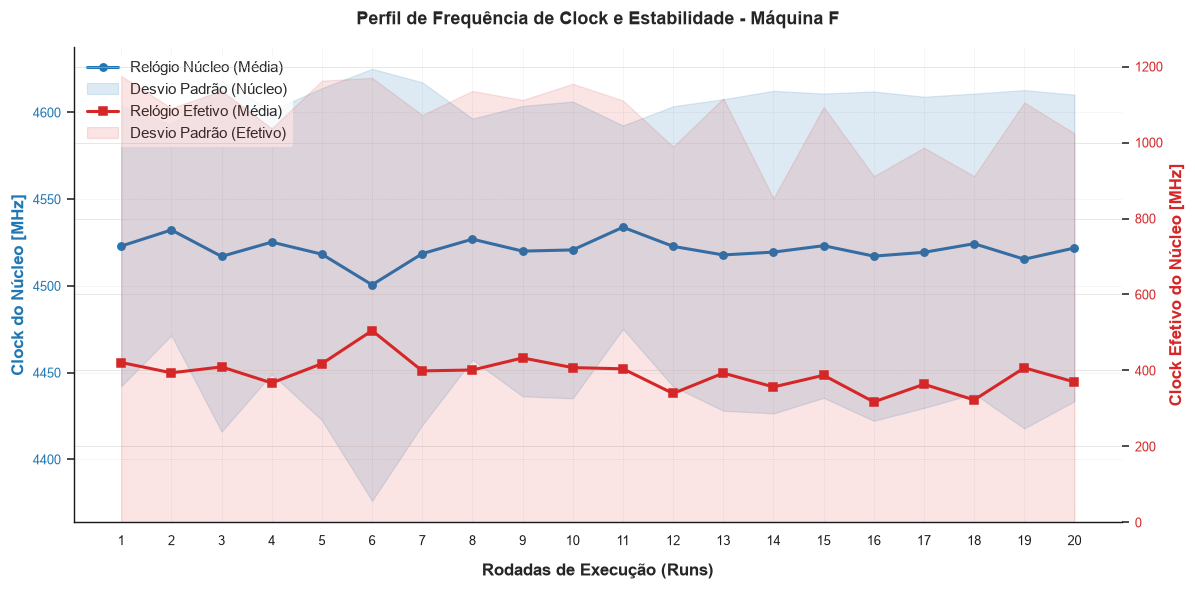

In [86]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

caminho_csv = Path("data") / "processed" / "estatistica_experimental_pilar_1_desempenho_e_clock.csv"
df = pd.read_csv(caminho_csv)

maquina_alvo = "Máquina F"  # Troque para "Máquina F" se necessário
df_filtrado = df[df["Maquina"] == maquina_alvo].copy()
df_filtrado["Rodada"] = pd.to_numeric(df_filtrado["Rodada"])
df_filtrado = df_filtrado.sort_values(by="Rodada")

fig, ax1 = plt.subplots(figsize=(11, 5.5), dpi=110)

# ==================== EIXO ESQUERDO: RELÓGIO NÚCLEO ====================
media_nucleo = df_filtrado["Média - Relógios núcleo (avg) [MHz]"]
dp_nucleo = df_filtrado["Desvio Padrão - Relógios núcleo (avg) [MHz]"]
rodadas = df_filtrado["Rodada"]

# Linha principal
ax1.plot(rodadas, media_nucleo, "-o", color="#1f77b4", linewidth=2, label="Relógio Núcleo (Média)")
# Área sombreada do Desvio Padrão (Sem barras poluídas!)
ax1.fill_between(rodadas, media_nucleo - dp_nucleo, media_nucleo + dp_nucleo, color="#1f77b4", alpha=0.15, label="Desvio Padrão (Núcleo)")

ax1.set_xlabel("Rodadas de Execução (Runs)", fontsize=11, fontweight="bold", labelpad=10)
ax1.set_ylabel("Clock do Núcleo [MHz]", color="#1f77b4", fontsize=11, fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_xticks(range(1, 21))
ax1.grid(True, linestyle=":", alpha=0.6)

# ==================== EIXO DIREITO: RELÓGIO EFETIVO ====================
ax2 = ax1.twinx()
media_efetivo = df_filtrado["Média - Relógios efetivos núcleo (avg) [MHz]"]
dp_efetivo = df_filtrado["Desvio Padrão - Relógios efetivos núcleo (avg) [MHz]"]

# Linha principal
ax2.plot(rodadas, media_efetivo, "-s", color="#d62728", linewidth=2, label="Relógio Efetivo (Média)")
# Área sombreada do Desvio Padrão
ax2.fill_between(rodadas, media_efetivo - dp_efetivo, media_efetivo + dp_efetivo, color="#d62728", alpha=0.12, label="Desvio Padrão (Efetivo)")

ax2.set_ylabel("Clock Efetivo do Núcleo [MHz]", color="#d62728", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y", labelcolor="#d62728")

# CORREÇÃO CRÍTICA: Forçar o eixo do clock efetivo a começar em 0
ax2.set_ylim(bottom=0)

# ==================== LEGENDAS E AJUSTES ====================
linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, labels1 + labels2, loc="upper left", frameon=True, facecolor="white", edgecolor="none")


plt.title(f"Perfil de Frequência de Clock e Estabilidade - {maquina_alvo}", fontsize=12, fontweight="bold", pad=15)
fig.tight_layout()
plt.show()


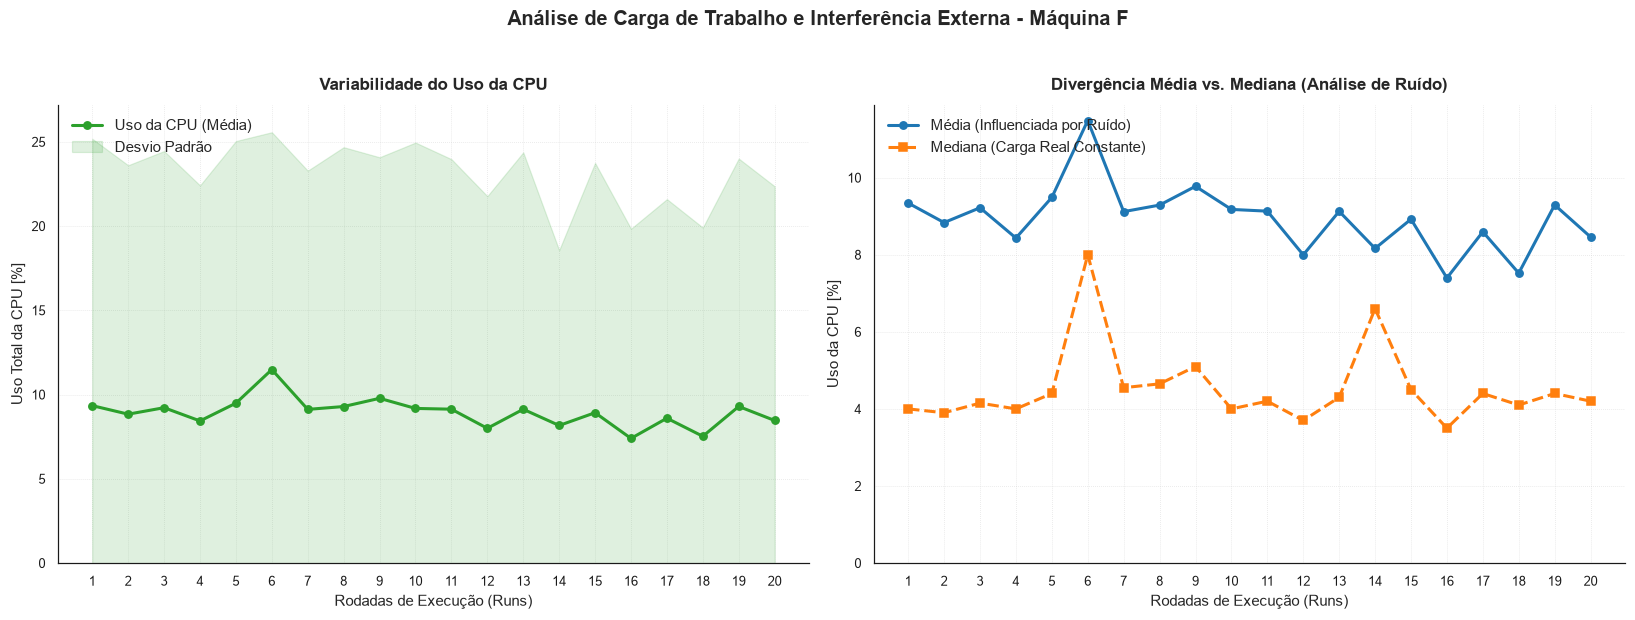

In [87]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# 1. Caminho relativo do novo arquivo do Pilar 2
caminho_csv2 = Path("data") / "processed" / "estatistica_experimental_pilar_2_carga_de_trabalho.csv"
df_carga = pd.read_csv(caminho_csv2)

# 2. Filtrar para a Máquina desejada e ordenar as rodadas
maquina_alvo = "Máquina F"
df_filtrado = df_carga[df_carga["Maquina"] == maquina_alvo].copy()
df_filtrado["Rodada"] = pd.to_numeric(df_filtrado["Rodada"])
df_filtrado = df_filtrado.sort_values(by="Rodada")

rodadas = df_filtrado["Rodada"]
media_cpu = df_filtrado["Média - Uso total da CPU [%]"]
dp_cpu = df_filtrado["Desvio Padrão - Uso total da CPU [%]"]
mediana_cpu = df_filtrado["Mediana - Uso total da CPU [%]"]

# 3. Criar painel com dois gráficos (Subplots lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=110)

# --- GRÁFICO 1: PERFIL DE CARGA DE CPU COM DESVIO PADRÃO ---
ax1.plot(rodadas, media_cpu, "-o", color="#2ca02c", linewidth=2, label="Uso da CPU (Média)")
ax1.fill_between(rodadas, media_cpu - dp_cpu, media_cpu + dp_cpu, color="#2ca02c", alpha=0.15, label="Desvio Padrão")
ax1.set_title("Variabilidade do Uso da CPU", fontsize=11, fontweight="bold", pad=10)
ax1.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax1.set_ylabel("Uso Total da CPU [%]", fontsize=10)
ax1.set_xticks(range(1, len(rodadas) + 1))
ax1.set_ylim(bottom=0)  # Evita valores negativos no gráfico
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# --- GRÁFICO 2: ANÁLISE DE RUÍDO (MÉDIA VS MEDIANA) ---
ax2.plot(rodadas, media_cpu, "-o", color="#1f77b4", linewidth=2, label="Média (Influenciada por Ruído)")
ax2.plot(rodadas, mediana_cpu, "--s", color="#ff7f0e", linewidth=2, label="Mediana (Carga Real Constante)")
ax2.set_title("Divergência Média vs. Mediana (Análise de Ruído)", fontsize=11, fontweight="bold", pad=10)
ax2.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax2.set_ylabel("Uso da CPU [%]", fontsize=10)
ax2.set_xticks(range(1, len(rodadas) + 1))
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

# Ajustes finais da figura
plt.suptitle(f"Análise de Carga de Trabalho e Interferência Externa - {maquina_alvo}", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


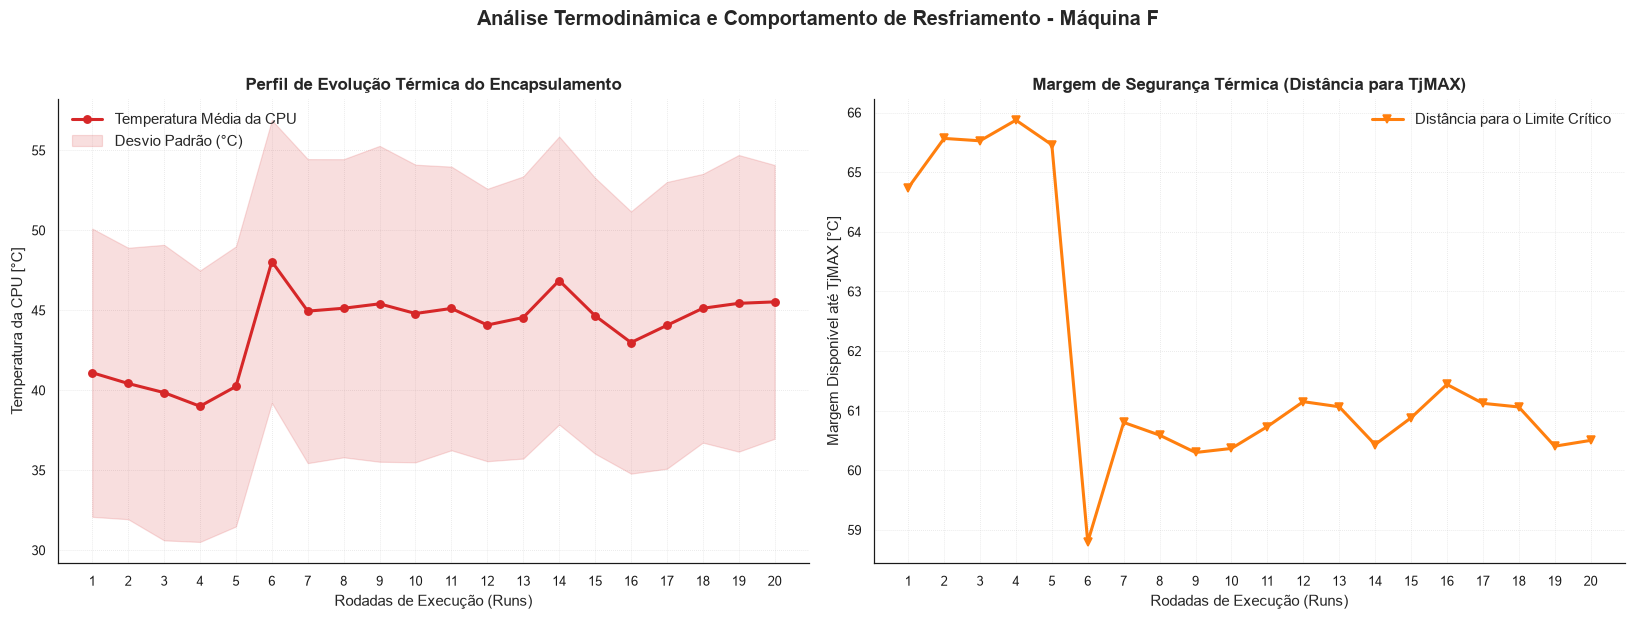

In [88]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# 1. Caminho relativo do arquivo do Pilar 3
caminho_csv3 = Path("data") / "processed" / "estatistica_experimental_pilar_3_termodinâmica_e_throttling.csv"
df_termo = pd.read_csv(caminho_csv3)

# 2. Filtrar para a Máquina desejada e ordenar as rodadas
maquina_alvo = "Máquina F"
df_filtrado = df_termo[df_termo["Maquina"] == maquina_alvo].copy()
df_filtrado["Rodada"] = pd.to_numeric(df_filtrado["Rodada"])
df_filtrado = df_filtrado.sort_values(by="Rodada")

rodadas = df_filtrado["Rodada"]
temp_cpu = df_filtrado["Média - CPU Inteira [°C]"]
dp_temp = df_filtrado["Desvio Padrão - CPU Inteira [°C]"]
dist_tjmax = df_filtrado["Média - Distância do núcleo para TjMAX (avg) [°C]"]

# 3. Criar painel com dois gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=110)

# --- GRÁFICO 1: EVOLUÇÃO TÉRMICA DA CPU DA MÁQUINA A ---
ax1.plot(rodadas, temp_cpu, "-o", color="#d62728", linewidth=2, label="Temperatura Média da CPU")
ax1.fill_between(rodadas, temp_cpu - dp_temp, temp_cpu + dp_temp, color="#d62728", alpha=0.15, label="Desvio Padrão (°C)")
ax1.set_title("Perfil de Evolução Térmica do Encapsulamento", fontsize=11, fontweight="bold")
ax1.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax1.set_ylabel("Temperatura da CPU [°C]", fontsize=10)
ax1.set_xticks(range(1, len(rodadas) + 1))
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# --- GRÁFICO 2: PROXIMIDADE DO LIMITE CRÍTICO (TjMAX) ---
ax2.plot(rodadas, dist_tjmax, "-v", color="#ff7f0e", linewidth=2, label="Distância para o Limite Crítico")
ax2.set_title("Margem de Segurança Térmica (Distância para TjMAX)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax2.set_ylabel("Margem Disponível até TjMAX [°C]", fontsize=10)
ax2.set_xticks(range(1, len(rodadas) + 1))
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

plt.suptitle(f"Análise Termodinâmica e Comportamento de Resfriamento - {maquina_alvo}", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


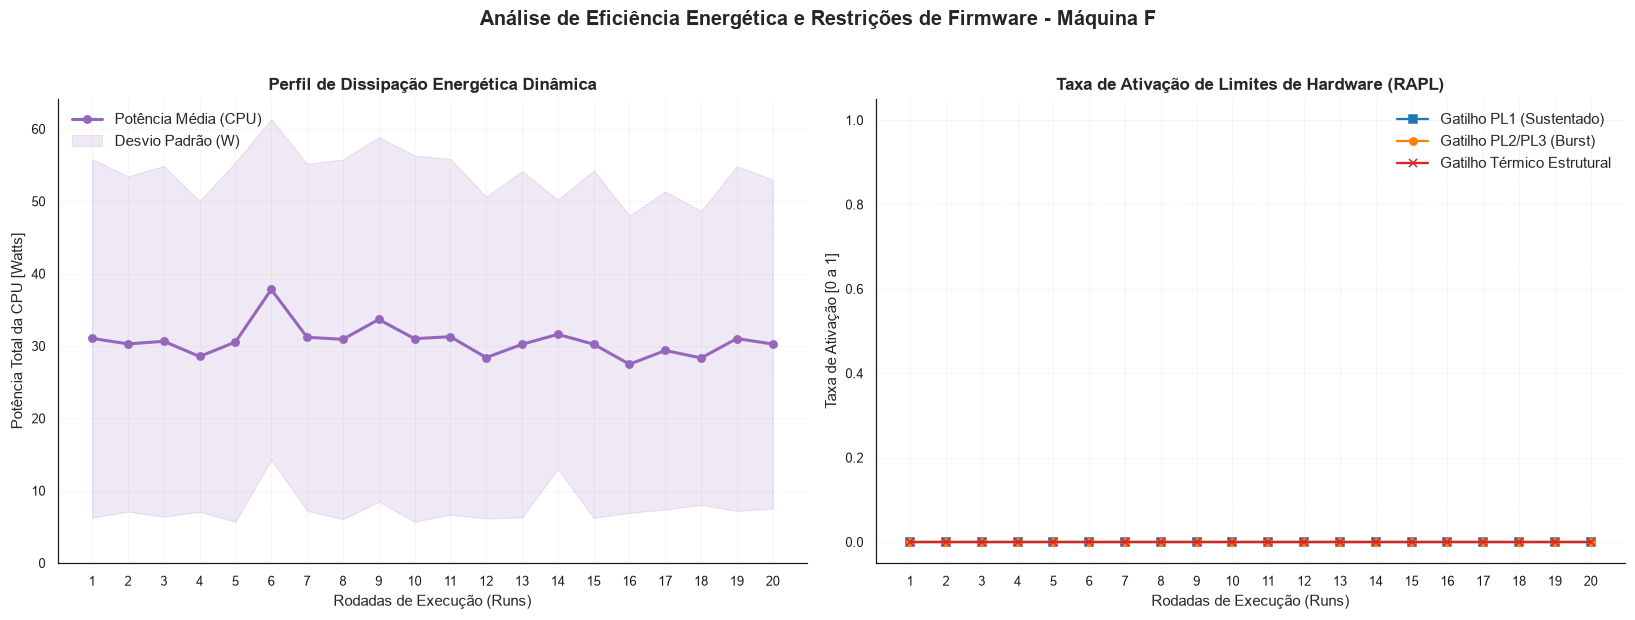

In [89]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# PARAMETRO DA MÁQUINA: Altere aqui para "Máquina A", "Máquina B" ou "Máquina F"
# =====================================================================
maquina_alvo = "Máquina F" 

# 1. Caminho relativo do arquivo do Pilar 4
caminho_csv4 = Path("data") / "processed" / "estatistica_experimental_pilar_4_energia_e_limites_de_projeto.csv"
df_energia = pd.read_csv(caminho_csv4)

# 2. Filtrar e ordenar pela máquina passada por parâmetro
df_filtrado = df_energia[df_energia["Maquina"] == maquina_alvo].copy()
df_filtrado["Rodada"] = pd.to_numeric(df_filtrado["Rodada"])
df_filtrado = df_filtrado.sort_values(by="Rodada")

rodadas = df_filtrado["Rodada"]
potencia = df_filtrado["Média - Potência total da CPU [W]"]
dp_potencia = df_filtrado["Desvio Padrão - Potência total da CPU [W]"]

# Pegar as taxas de limites de projeto (RAPL) e limite térmico
pl1_taxa = df_filtrado["Média - IA: Package-Level RAPL/PBM PL1 [Yes/Não]_Taxa"]
pl2_taxa = df_filtrado["Média - IA: Package-Level RAPL/PBM PL2 PL3 [Yes/Não]_Taxa"]
termico_taxa = df_filtrado["Média - Limite de desempenho - Térmico [Yes/Não]_Taxa"]

# 3. Inicializar a figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=110)

# --- GRÁFICO 1: PERFIL DE CONSUMO DE POTÊNCIA (WATTS) ---
ax1.plot(rodadas, potencia, "-o", color="#9467bd", linewidth=2, label="Potência Média (CPU)")
ax1.fill_between(rodadas, potencia - dp_potencia, potencia + dp_potencia, color="#9467bd", alpha=0.15, label="Desvio Padrão (W)")
ax1.set_title("Perfil de Dissipação Energética Dinâmica", fontsize=11, fontweight="bold")
ax1.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax1.set_ylabel("Potência Total da CPU [Watts]", fontsize=10)
ax1.set_xticks(range(1, len(rodadas) + 1))
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# --- GRÁFICO 2: MONITORAMENTO DE LIMITES DE PROJETO (STRANGULAMENTO) ---
ax2.plot(rodadas, pl1_taxa, "-s", color="#1f77b4", linewidth=1.5, label="Gatilho PL1 (Sustentado)")
ax2.plot(rodadas, pl2_taxa, "-o", color="#ff7f0e", linewidth=1.5, label="Gatilho PL2/PL3 (Burst)")
ax2.plot(rodadas, termico_taxa, "-x", color="#d62728", linewidth=1.5, label="Gatilho Térmico Estrutural")
ax2.set_title("Taxa de Ativação de Limites de Hardware (RAPL)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax2.set_ylabel("Taxa de Ativação [0 a 1]", fontsize=10)
ax2.set_xticks(range(1, len(rodadas) + 1))
ax2.set_ylim(-0.05, 1.05) # Escala fixa de taxa para visualização científica clara
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right")

plt.suptitle(f"Análise de Eficiência Energética e Restrições de Firmware - {maquina_alvo}", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


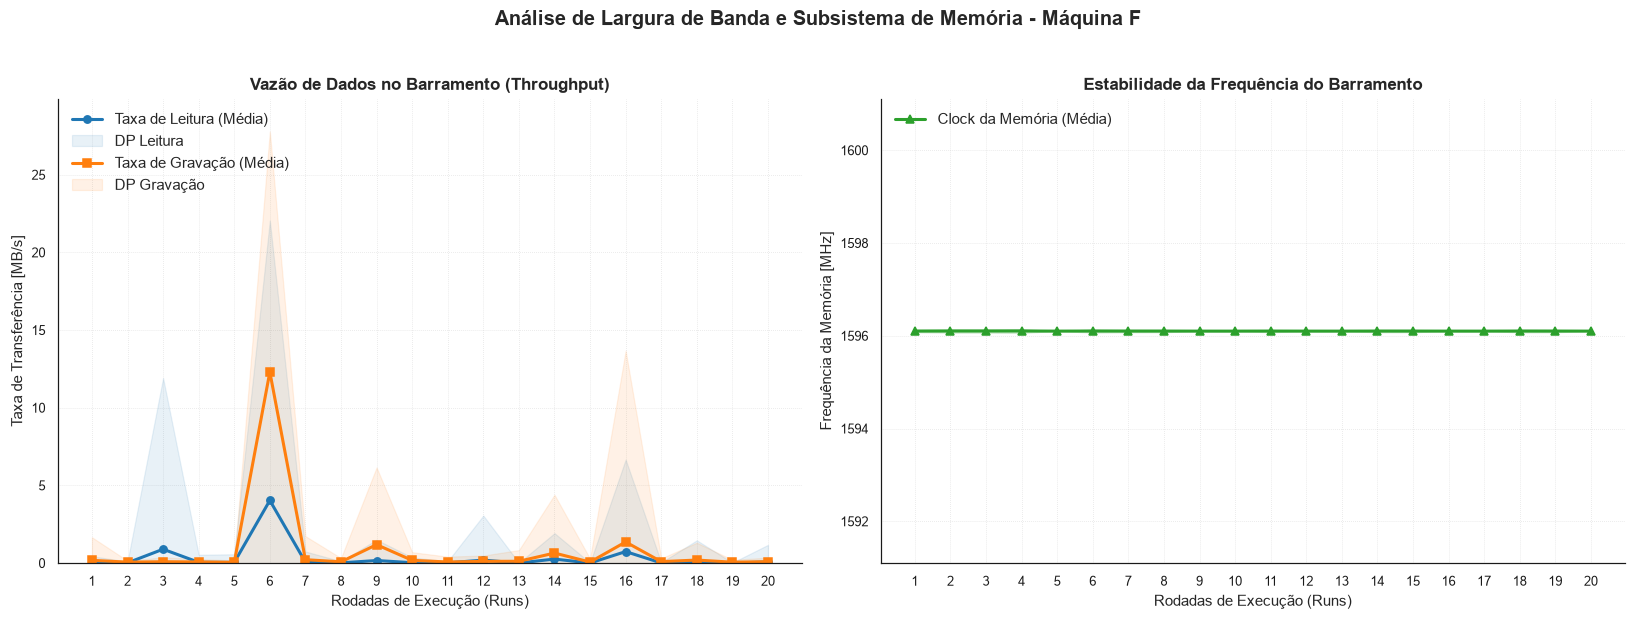

In [90]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# PARAMETRO DA MÁQUINA: Altere aqui para "Máquina A", "Máquina B" ou "Máquina F"
# =====================================================================
maquina_alvo = "Máquina F" 

# 1. Caminho relativo do arquivo do Pilar 5
caminho_csv5 = Path("data") / "processed" / "estatistica_experimental_pilar_5_memória.csv"
df_memoria = pd.read_csv(caminho_csv5)

# 2. Filtrar e ordenar pela máquina passada por parâmetro
df_filtrado = df_memoria[df_memoria["Maquina"] == maquina_alvo].copy()
df_filtrado["Rodada"] = pd.to_numeric(df_filtrado["Rodada"])
df_filtrado = df_filtrado.sort_values(by="Rodada")

rodadas = df_filtrado["Rodada"]

# Dados de Vazão (MB/s)
media_leitura = df_filtrado["Média - Taxa de leituras [MB/s]"]
dp_leitura = df_filtrado["Desvio Padrão - Taxa de leituras [MB/s]"]
media_escrita = df_filtrado["Média - Taxa de gravações [MB/s]"]
dp_escrita = df_filtrado["Desvio Padrão - Taxa de gravações [MB/s]"]

# Dados de Frequência (MHz)
clock_mem = df_filtrado["Média - Relógio da memória [MHz]"]
dp_clock_mem = df_filtrado["Desvio Padrão - Relógio da memória [MHz]"]

# 3. Inicializar a figura com dois subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=110)

# --- GRÁFICO 1: PERFIL DE VAZÃO DE MEMÓRIA (READ vs WRITE) ---
ax1.plot(rodadas, media_leitura, "-o", color="#1f77b4", linewidth=2, label="Taxa de Leitura (Média)")
ax1.fill_between(rodadas, media_leitura - dp_leitura, media_leitura + dp_leitura, color="#1f77b4", alpha=0.1, label="DP Leitura")

ax1.plot(rodadas, media_escrita, "-s", color="#ff7f0e", linewidth=2, label="Taxa de Gravação (Média)")
ax1.fill_between(rodadas, media_escrita - dp_escrita, media_escrita + dp_escrita, color="#ff7f0e", alpha=0.1, label="DP Gravação")

ax1.set_title("Vazão de Dados no Barramento (Throughput)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax1.set_ylabel("Taxa de Transferência [MB/s]", fontsize=10)
ax1.set_xticks(range(1, len(rodadas) + 1))
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# --- GRÁFICO 2: FREQUÊNCIA DO RELÓGIO DA MEMÓRIA ---
ax2.plot(rodadas, clock_mem, "-^", color="#2ca02c", linewidth=2, label="Clock da Memória (Média)")
ax2.fill_between(rodadas, clock_mem - dp_clock_mem, clock_mem + dp_clock_mem, color="#2ca02c", alpha=0.2)
ax2.set_title("Estabilidade da Frequência do Barramento", fontsize=11, fontweight="bold")
ax2.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax2.set_ylabel("Frequência da Memória [MHz]", fontsize=10)
ax2.set_xticks(range(1, len(rodadas) + 1))

# Forçar escala curta para evidenciar a precisão cirúrgica do clock (ajusta dinamicamente)
margem_y = 5
ax2.set_ylim(clock_mem.min() - margem_y, clock_mem.max() + margem_y)

ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

plt.suptitle(f"Análise de Largura de Banda e Subsistema de Memória - {maquina_alvo}", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


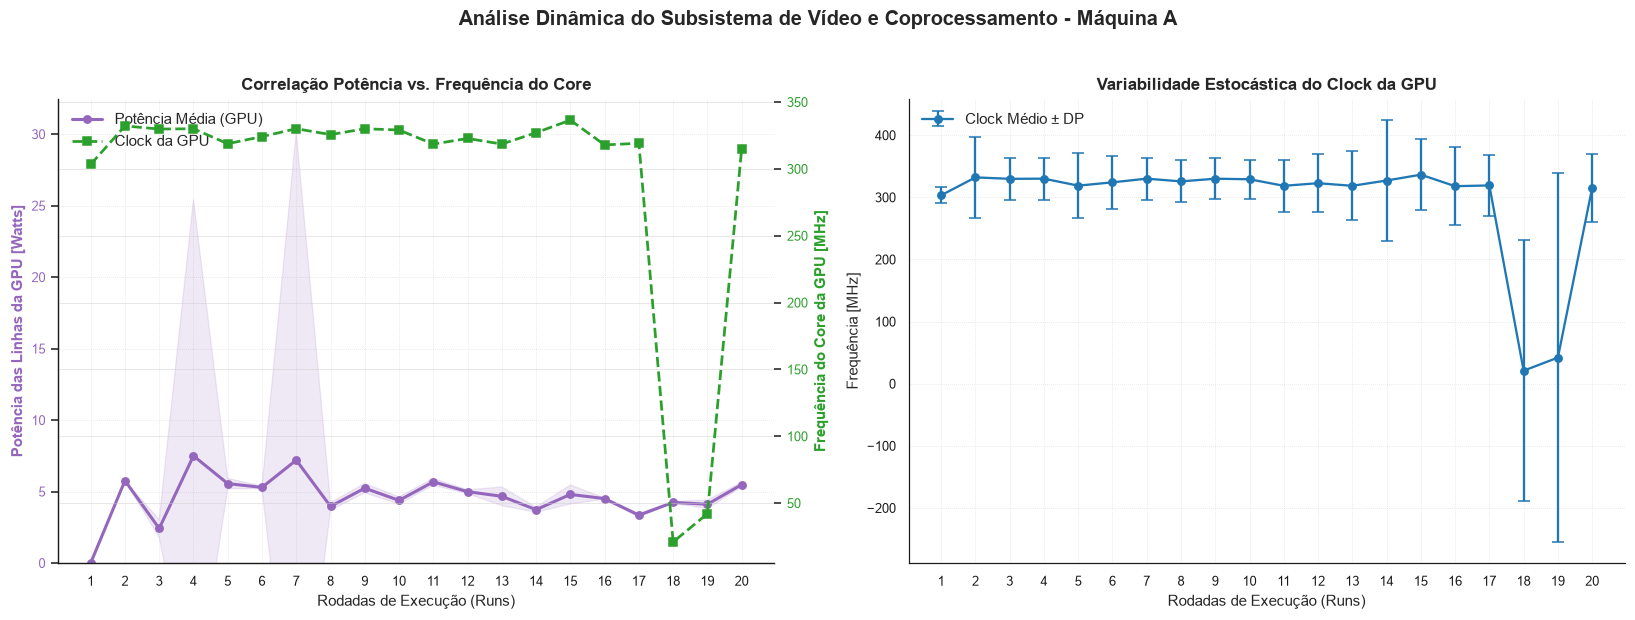

In [91]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================================
# PARAMETRO DA MÁQUINA: Altere aqui para "Máquina A", "Máquina B" ou "Máquina F"
# =====================================================================
maquina_alvo = "Máquina A" 

# 1. Caminho relativo do arquivo do Pilar 6
caminho_csv6 = Path("data") / "processed" / "estatistica_experimental_pilar_6_subsistema_de_gpu_(apenas_a_e_f).csv"
df_gpu = pd.read_csv(caminho_csv6)

# 2. Filtrar e ordenar pelas rodadas numericamente
df_filtrado = df_gpu[df_gpu["Maquina"] == maquina_alvo].copy()
df_filtrado["Rodada"] = pd.to_numeric(df_filtrado["Rodada"])
df_filtrado = df_filtrado.sort_values(by="Rodada")

rodadas = df_filtrado["Rodada"]
potencia_gpu = df_filtrado["Média - Potência das linhas GPU (avg) [W]"]
dp_potencia_gpu = df_filtrado["Desvio Padrão - Potência das linhas GPU (avg) [W]"]
clock_gpu = df_filtrado["Média - GPU Clock [MHz]"]
dp_clock_gpu = df_filtrado["Desvio Padrão - GPU Clock [MHz]"]

# 3. Inicializar a figura com dois subplots lado a lado
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=110)

# --- GRÁFICO 1: PERFIL DE COMPORTAMENTO DINÂMICO DA GPU (EIXO DUPLO) ---
color_pot = "#9467bd"
ax1.plot(rodadas, potencia_gpu, "-o", color=color_pot, linewidth=2, label="Potência Média (GPU)")
ax1.fill_between(rodadas, potencia_gpu - dp_potencia_gpu, potencia_gpu + dp_potencia_gpu, color=color_pot, alpha=0.15)
ax1.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax1.set_ylabel("Potência das Linhas da GPU [Watts]", color=color_pot, fontsize=10, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=color_pot)
ax1.grid(True, linestyle=":", alpha=0.6)

# Evitar que o eixo quebre se os valores forem todos zero (Máquina B)
if potencia_gpu.max() == 0:
    ax1.set_ylim(-1, 5)
else:
    ax1.set_ylim(bottom=0)

# Criar eixo gêmeo para o clock da GPU
ax2 = ax1.twinx()
color_clk = "#2ca02c"
ax2.plot(rodadas, clock_gpu, "--s", color=color_clk, linewidth=1.8, label="Clock da GPU")
ax2.set_ylabel("Frequência do Core da GPU [MHz]", color=color_clk, fontsize=10, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=color_clk)

if clock_gpu.max() == clock_gpu.min():
    ax2.set_ylim(clock_gpu.min() - 50, clock_gpu.max() + 50)

ax1.set_title("Correlação Potência vs. Frequência do Core", fontsize=11, fontweight="bold")
ax1.set_xticks(range(1, len(rodadas) + 1))

# Unificar as legendas do primeiro gráfico
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# --- GRÁFICO 2: VARIABILIDADE E RUÍDO DO CLOCK (MÉDIA VS DESVIO PADRÃO) ---
ax3.errorbar(rodadas, clock_gpu, yerr=dp_clock_gpu, fmt="-o", color="#1f77b4", capsize=4, linewidth=1.5, label="Clock Médio ± DP")
ax3.set_title("Variabilidade Estocástica do Clock da GPU", fontsize=11, fontweight="bold")
ax3.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax3.set_ylabel("Frequência [MHz]", fontsize=10)
ax3.set_xticks(range(1, len(rodadas) + 1))
ax3.grid(True, linestyle=":", alpha=0.6)
ax3.legend(loc="upper left")

if clock_gpu.max() == clock_gpu.min():
    ax3.set_ylim(clock_gpu.min() - 50, clock_gpu.max() + 50)

plt.suptitle(f"Análise Dinâmica do Subsistema de Vídeo e Coprocessamento - {maquina_alvo}", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


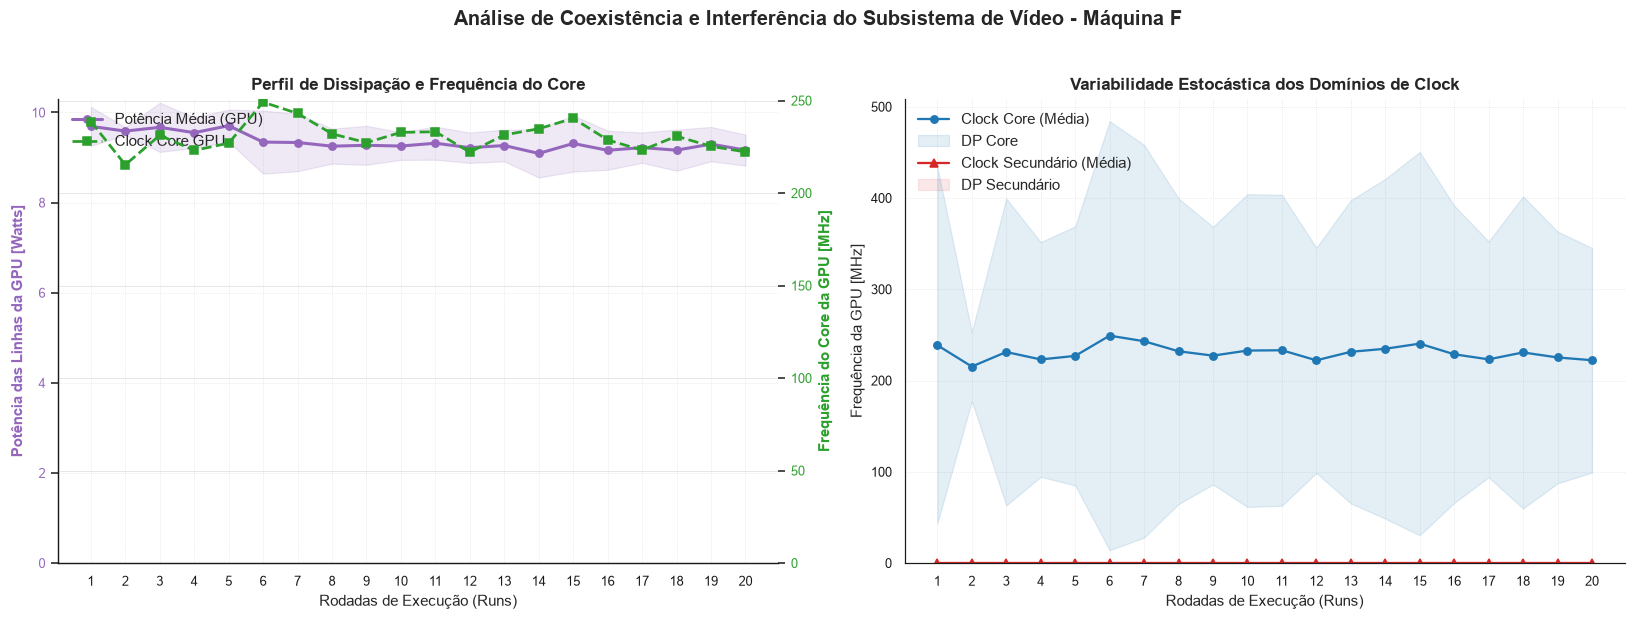

In [92]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =====================================================================
# PARAMETRO DA MÁQUINA
# =====================================================================
maquina_alvo = "Máquina F" 

caminho_csv6 = Path("data") / "processed" / "estatistica_experimental_pilar_6_subsistema_de_gpu_(apenas_a_e_f).csv"
df_gpu = pd.read_csv(caminho_csv6)

df_filtrado = df_gpu[df_gpu["Maquina"] == maquina_alvo].copy()
df_filtrado["Rodada"] = pd.to_numeric(df_filtrado["Rodada"])
df_filtrado = df_filtrado.sort_values(by="Rodada")

rodadas = df_filtrado["Rodada"]
potencia_gpu = df_filtrado["Média - Potência das linhas GPU (avg) [W]"]
dp_potencia_gpu = df_filtrado["Desvio Padrão - Potência das linhas GPU (avg) [W]"]

# Tratamento das duas colunas de clock que o Pandas indexa
clock_gpu_core = df_filtrado["Média - GPU Clock [MHz]"]
dp_clock_core = df_filtrado["Desvio Padrão - GPU Clock [MHz]"]

# Segunda coluna de clock (geralmente clock de memória da GPU ou barramento secundário)
clock_gpu_sec = df_filtrado["Média - GPU Clock [MHz].1"]
dp_clock_sec = df_filtrado["Desvio Padrão - GPU Clock [MHz].1"]

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(15, 5.5), dpi=110)

# --- GRÁFICO 1: CORRELAÇÃO DE CONSUMO ELÉTRICO vs CLOCK CORE ---
color_pot = "#9467bd"
ax1.plot(rodadas, potencia_gpu, "-o", color=color_pot, linewidth=2, label="Potência Média (GPU)")
# Correção: Confinar o desvio padrão elétrico para não cair abaixo de zero
lower_pot = np.maximum(0, potencia_gpu - dp_potencia_gpu)
ax1.fill_between(rodadas, lower_pot, potencia_gpu + dp_potencia_gpu, color=color_pot, alpha=0.15)

ax1.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax1.set_ylabel("Potência das Linhas da GPU [Watts]", color=color_pot, fontsize=10, fontweight="bold")
ax1.tick_params(axis="y", labelcolor=color_pot)
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.set_xticks(range(1, len(rodadas) + 1))
ax1.set_ylim(bottom=0)

# Eixo gêmeo para o clock do core
ax2 = ax1.twinx()
color_clk = "#2ca02c"
ax2.plot(rodadas, clock_gpu_core, "--s", color=color_clk, linewidth=1.8, label="Clock Core GPU")
ax2.set_ylabel("Frequência do Core da GPU [MHz]", color=color_clk, fontsize=10, fontweight="bold")
ax2.tick_params(axis="y", labelcolor=color_clk)
ax2.set_ylim(bottom=0)

ax1.set_title("Perfil de Dissipação e Frequência do Core", fontsize=11, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# --- GRÁFICO 2: ANÁLISE DE VARIABILIDADE E SINAIS SECUNDÁRIOS DE CLOCK ---
# Plot do Core da GPU
ax3.plot(rodadas, clock_gpu_core, "-o", color="#1f77b4", linewidth=1.5, label="Clock Core (Média)")
lower_core = np.maximum(0, clock_gpu_core - dp_clock_core)
ax3.fill_between(rodadas, lower_core, clock_gpu_core + dp_clock_core, color="#1f77b4", alpha=0.12, label="DP Core")

# Plot do Barramento Secundário da GPU (.1)
ax3.plot(rodadas, clock_gpu_sec, "-^", color="#d62728", linewidth=1.5, label="Clock Secundário (Média)")
lower_sec = np.maximum(0, clock_gpu_sec - dp_clock_sec)
ax3.fill_between(rodadas, lower_sec, clock_gpu_sec + dp_clock_sec, color="#d62728", alpha=0.1, label="DP Secundário")

ax3.set_title("Variabilidade Estocástica dos Domínios de Clock", fontsize=11, fontweight="bold")
ax3.set_xlabel("Rodadas de Execução (Runs)", fontsize=10)
ax3.set_ylabel("Frequência da GPU [MHz]", fontsize=10)
ax3.set_xticks(range(1, len(rodadas) + 1))
ax3.grid(True, linestyle=":", alpha=0.6)

# CORREÇÃO CRÍTICA: Forçar o eixo Y a começar estritamente em zero
ax3.set_ylim(bottom=0)
ax3.legend(loc="upper left")

plt.suptitle(f"Análise de Coexistência e Interferência do Subsistema de Vídeo - {maquina_alvo}", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


### 📈 Metodologia de Análise Cronológica Dinâmica (Gráfico 1)

*   **Objetivo Científico**: Mapear o comportamento transiente e a estabilidade operacional dos sensores de temperatura da Unidade Central de Processamento (CPU) ao longo do tempo de ensaio. A análise visa isolar assinaturas térmicas características de estrangulamento térmico (*thermal throttling*).
*   **Amostragem e Escopo**: Restringiu-se o escopo de visualização à **Rodada 01** de cada máquina do trio analítico ($A$, $B$ e $F$). Essa amostragem isolada atua como um sumário cronológico representativo, mitigando a sobreposição de linhas e o consequente ruído visual gerado pela plotagem concomitante de múltiplos eixos temporais das 20 rodadas.
*   **Critério de Validação**: Empregaram-se subplots independentes (facetas) com o eixo de ordenadas ($Y$) compartilhado. Essa padronização escalar viabiliza a comparação direta inter-segmentos, permitindo correlacionar instantaneamente picos de temperatura estáveis com o limiar de projeto físico (TDP) de cada microarquitetura avaliada.


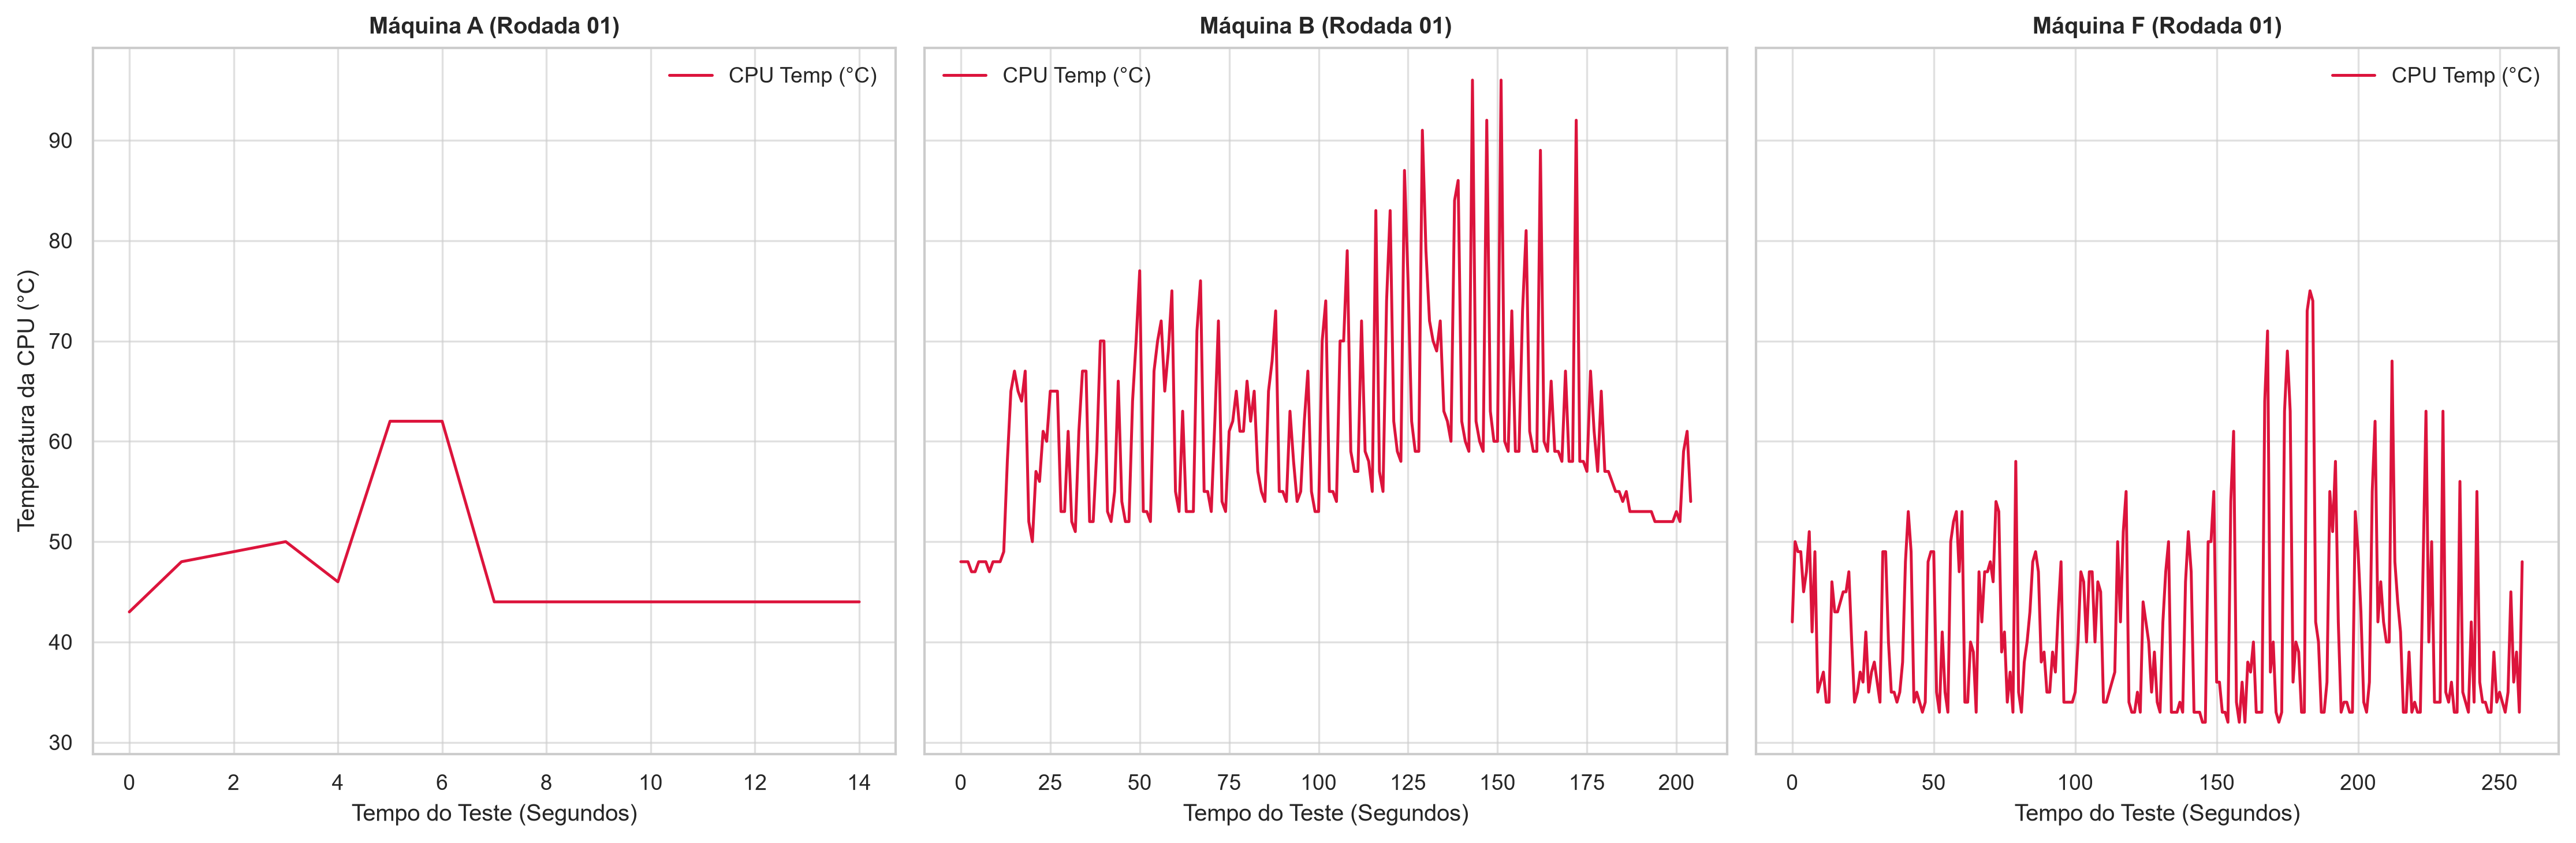

💾 Gráfico 1 corrigido e salvo com sucesso em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_linhas_temporais_facetado.png


In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =====================================================================
# GRÁFICO 1: LINHAS TEMPORAIS FACETADAS (CORRIGIDO)
# =====================================================================
# Configuração do estilo científico
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# Carrega a base filtrada de colunas
df_grafico1 = pd.read_csv(PASTA_PROCESSED / NOME_ARQUIVO_FEATURES, low_memory=False)

# Criamos uma aproximação estável de tempo (segundo a segundo) por Rodada para o eixo X
if 'Segundo' not in df_grafico1.columns:
    df_grafico1['Segundo'] = df_grafico1.groupby(['Maquina', 'Rodada']).cumcount()

# Filtramos apenas a Rodada 1 para manter o gráfico linear legível e sem sobreposição
df_filtrado_linha = df_grafico1[df_grafico1['Rodada'] == 1].copy()

# Inicializa a estrutura de subplots (1 linha, 3 colunas - uma para cada máquina)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, dpi=300)
maquinas_disponiveis = sorted(df_filtrado_linha['Maquina'].unique())

for i, maq in enumerate(maquinas_disponiveis):
    dados_maq = df_filtrado_linha[df_filtrado_linha['Maquina'] == maq]
    
    # Plota o comportamento cronológico da temperatura da CPU
    sns.lineplot(data=dados_maq, x='Segundo', y='CPU Inteira [°C]', ax=axes[i], color='crimson', label='CPU Temp (°C)')
    
    # Configurações estéticas individuais por janela de máquina
    axes[i].set_title(f"{maq} (Rodada 01)", fontweight='bold')
    axes[i].set_xlabel("Tempo do Teste (Segundos)")
    
    if i == 0:
        axes[i].set_ylabel("Temperatura da CPU (°C)")
    else:
        axes[i].set_ylabel("")

plt.tight_layout()

# Salva a figura em alta resolução para o artigo científico
caminho_grafico1 = PASTA_PROCESSED / "grafico_linhas_temporais_facetado.png"
plt.savefig(caminho_grafico1, bbox_inches='tight', dpi=300)
plt.show()
print(f"💾 Gráfico 1 corrigido e salvo com sucesso em:\n   📍 {caminho_grafico1}")

### 📊 Metodologia de Dispersão e Estabilidade Experimental (Gráfico 2)

*   **Objetivo Científico**: Avaliar a consistência do consumo energético da CPU e mensurar a variabilidade estatística entre as 20 rodadas consecutivas de testes executionais. 
*   **Métricas Computadas**: A técnica de diagrama de caixa (*Boxplot*) foi selecionada por sumarizar cinco estatísticas descritivas fundamentais em uma única representação compacta:
    1.  **Mediana ($\tilde{X}$)**: Indicador central imune a perturbações sazonais do sistema.
    2.  **Quartis Inferior ($Q_1/25\%$) e Superior ($Q_3/75\%$)**: Limitadores do intervalo interquartil (IQR), que definem o coração da dispersão dos dados.
    3.  **Limites Limiares (Whiskers)**: Extensão máxima dos dados considerados estatisticamente esperados dentro do modelo ($1.5 \times \text{IQR}$).
    4.  **Pontos Espúrios (*Outliers*)**: Identificação explícita de picos atípicos de potência ou anomalias isoladas de leitura dos sensores.
*   **Justificativa Acadêmica**: A consolidação de milhares de registros de telemetria através de caixas estatísticas blindou a discussão contra dados poluídos. Uma amplitude vertical reduzida na caixa sinaliza estabilidade microarquitetural e reprodutibilidade científica do ensaio sintético naquele hardware específico.


C:\Users\xapor\AppData\Local\Temp\ipykernel_10416\3924222724.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


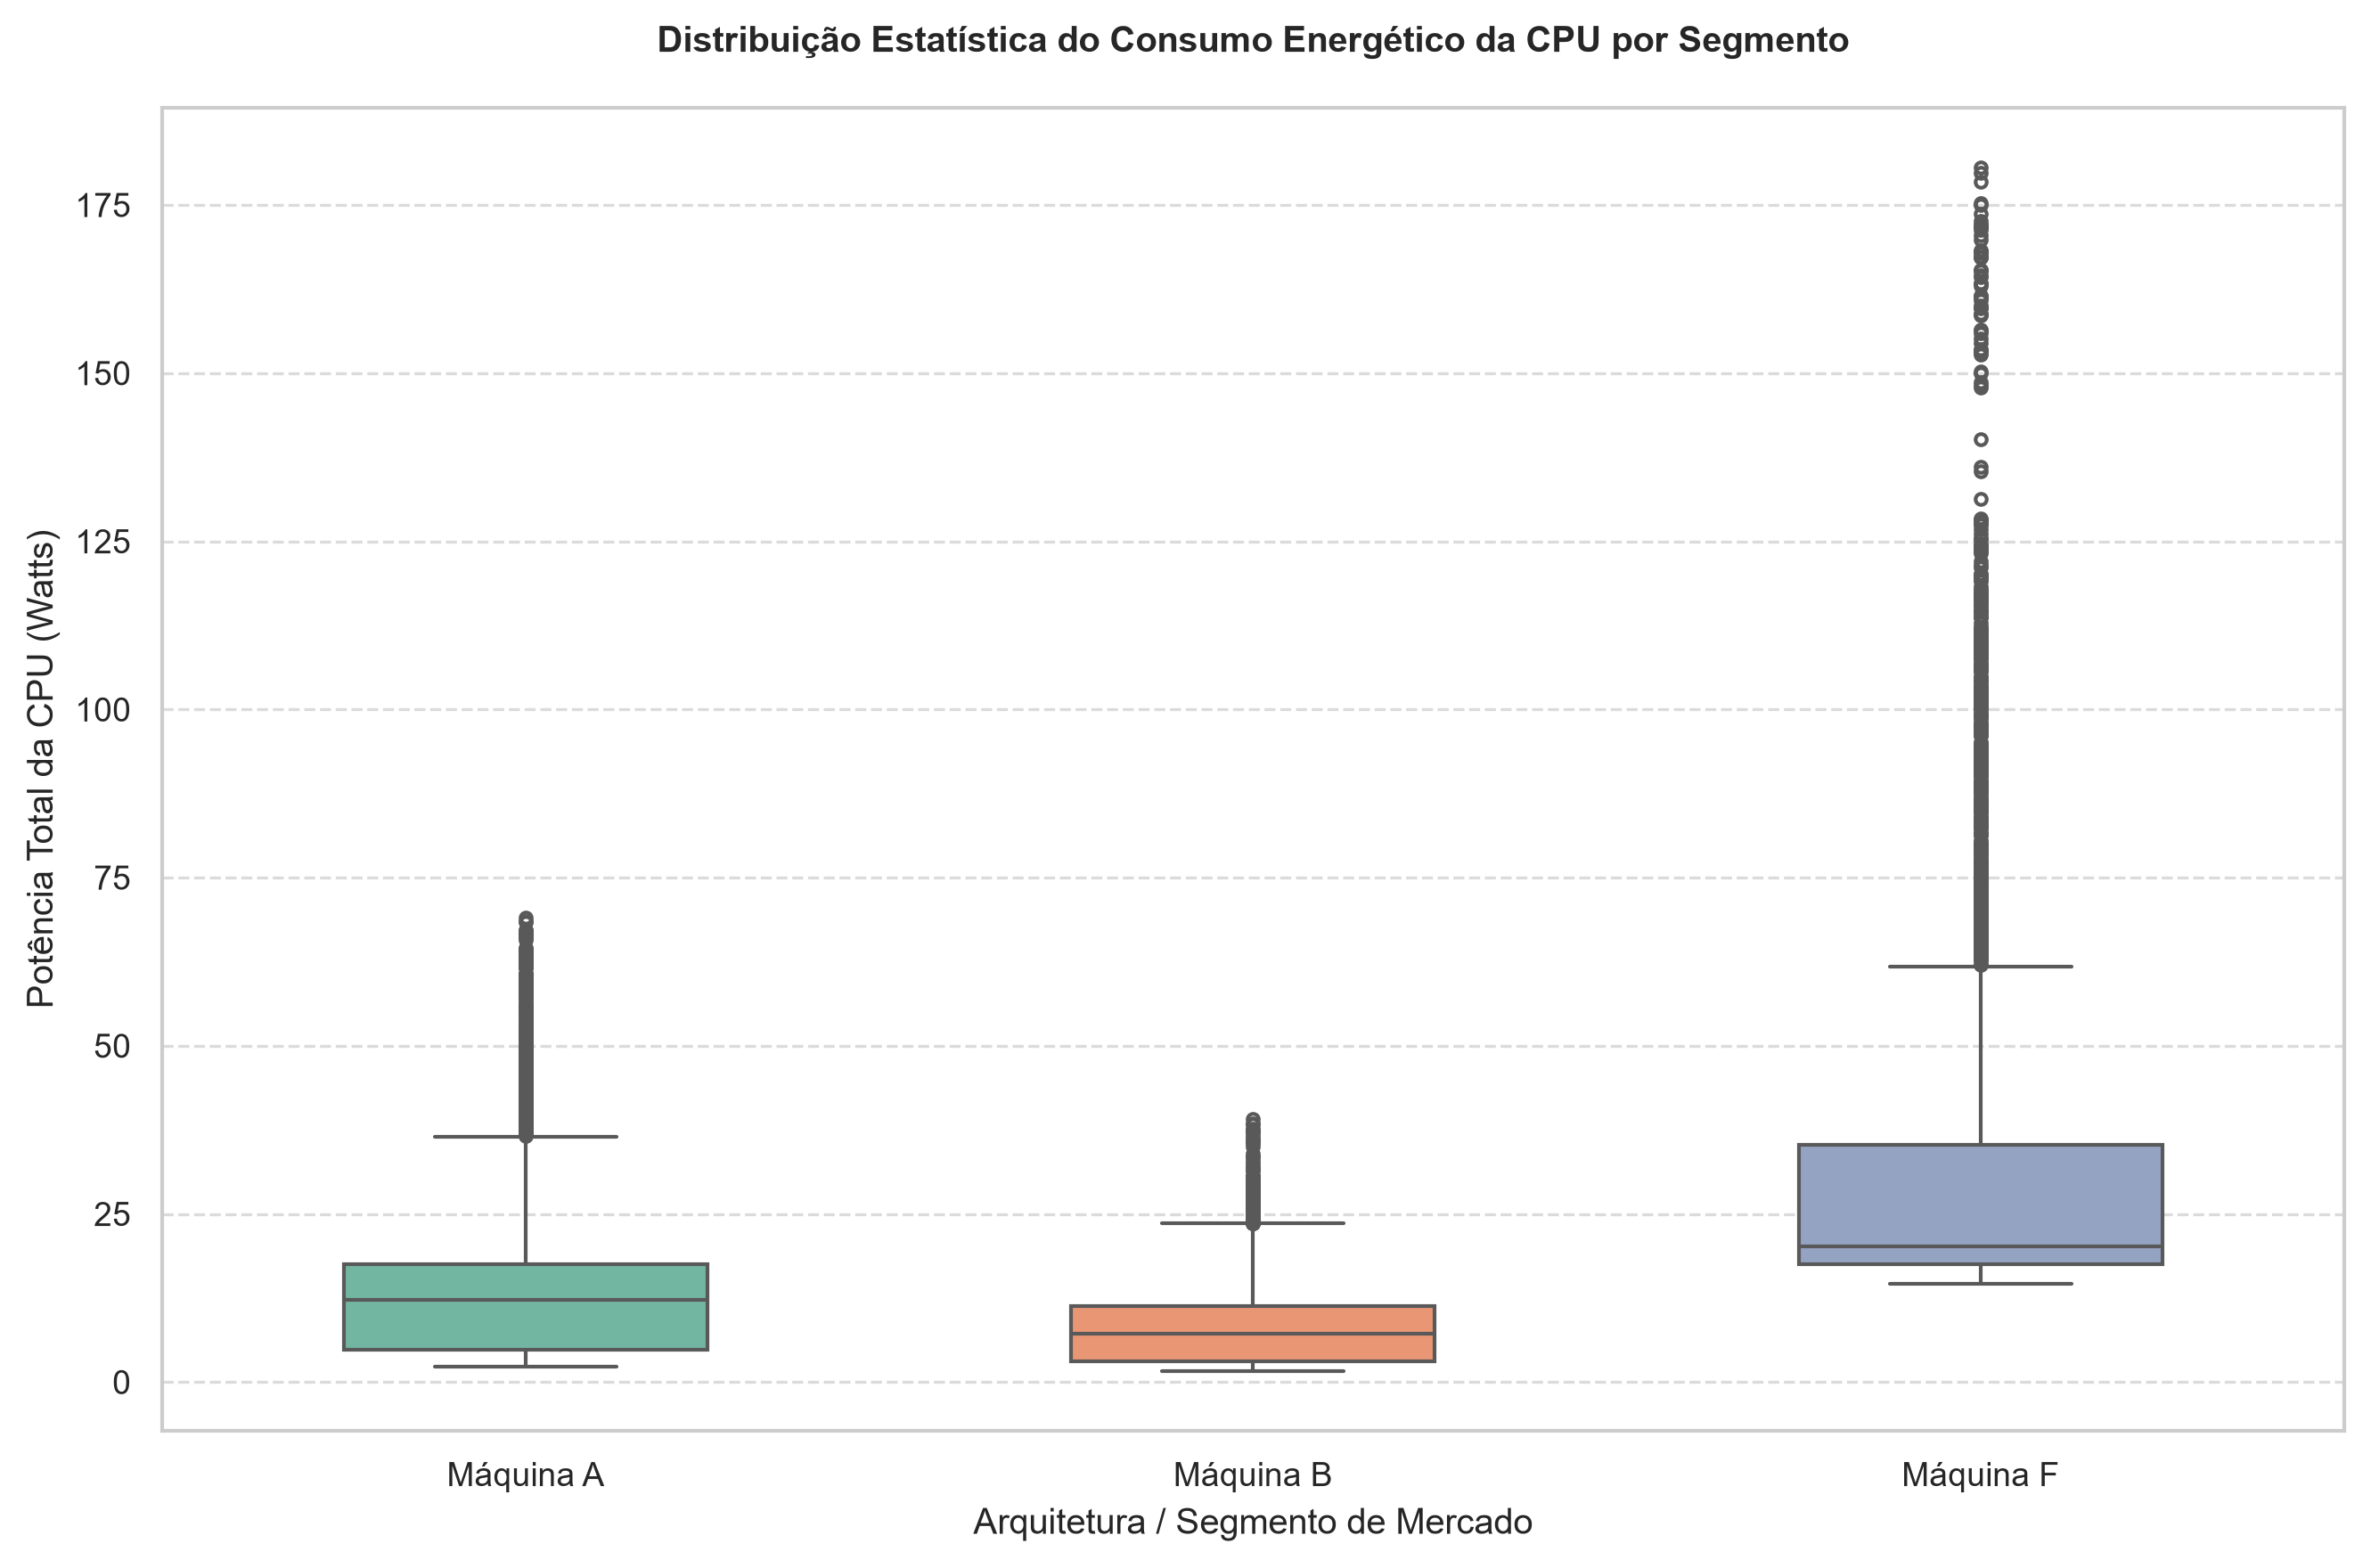

💾 Gráfico 2 salvo com sucesso em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_boxplot_consumo_energia.png


In [94]:
# =====================================================================
# GRÁFICO 2: BOXPLOT COMPARATIVO (ESTATÍSTICA EXPERIMENTAL DAS 20 RODADAS)
# =====================================================================
plt.figure(figsize=(9, 6), dpi=300)

# Carrega a base científica (usamos a imputed por estar livre de nulos na GPU/Energia)
df_grafico2 = pd.read_csv(PASTA_PROCESSED / NOME_ARQUIVO_IMPUTED, low_memory=False)

# Desenha o Boxplot com uma paleta de cores sóbria e acadêmica
ax = sns.boxplot(
    data=df_grafico2, 
    x='Maquina', 
    y='Potência total da CPU [W]', 
    palette="Set2",
    width=0.5,
    fliersize=3  # Tamanho dos pontos fora da curva (outliers)
)

# Ajustes estéticos e rotulação científica
plt.title("Distribuição Estatística do Consumo Energético da CPU por Segmento", fontweight='bold', pad=15)
plt.xlabel("Arquitetura / Segmento de Mercado")
plt.ylabel("Potência Total da CPU (Watts)")

# Adiciona uma grade sutil para facilitar a leitura dos valores dos quartis
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

# Salva a figura para o artigo
caminho_grafico2 = PASTA_PROCESSED / "grafico_boxplot_consumo_energia.png"
plt.savefig(caminho_grafico2, bbox_inches='tight', dpi=300)
plt.show()
print(f"💾 Gráfico 2 salvo com sucesso em:\n   📍 {caminho_grafico2}")


### 🔬 Metodologia de Correlação Física e Dominância de TDP (Gráfico 3)

*   **Objetivo Científico**: Evidenciar e comprovar a tese central do recorte empírico: a potência térmica de projeto (TDP) atua como a variável dominante e restritiva sobre os limites termodinâmicos dos sistemas de computação.
*   **Abordagem Estatística**: Utilizou-se o método dos Mínimos Quadrados Ordinários (OLS) para computar um modelo de **Regressão Linear Simples** concomitante para cada dispositivo. O cruzamento bivariado posicionou a variável independente (Causa: *Potência total da CPU [W]*) no Eixo $X$ e a variável dependente (Efeito: *CPU Inteira [°C]*) no Eixo $Y$.
*   **Tratamento de Densidade**: Como a telemetria segundo a segundo gera dezenas de milhares de coordenadas sobrepostas, aplicou-se um fator de opacidade (*Alpha* de $15\%$) nos marcadores de dispersão. Isso gerou um mapa de densidade visual, onde as regiões mais escuras denotam o ponto de operação estável (*steady-state*) mais frequente do processador.
*   **Resultados Esperados**: O gráfico valida o isolamento de mercado do trio: o agrupamento dos pontos cria três "nuvens" espacialmente segregadas e paralelas ao longo do plano cartesiano, atestando que os limites físicos impostos pelas fabricantes governam a eficiência térmica do chip.


<Figure size 3000x1800 with 0 Axes>

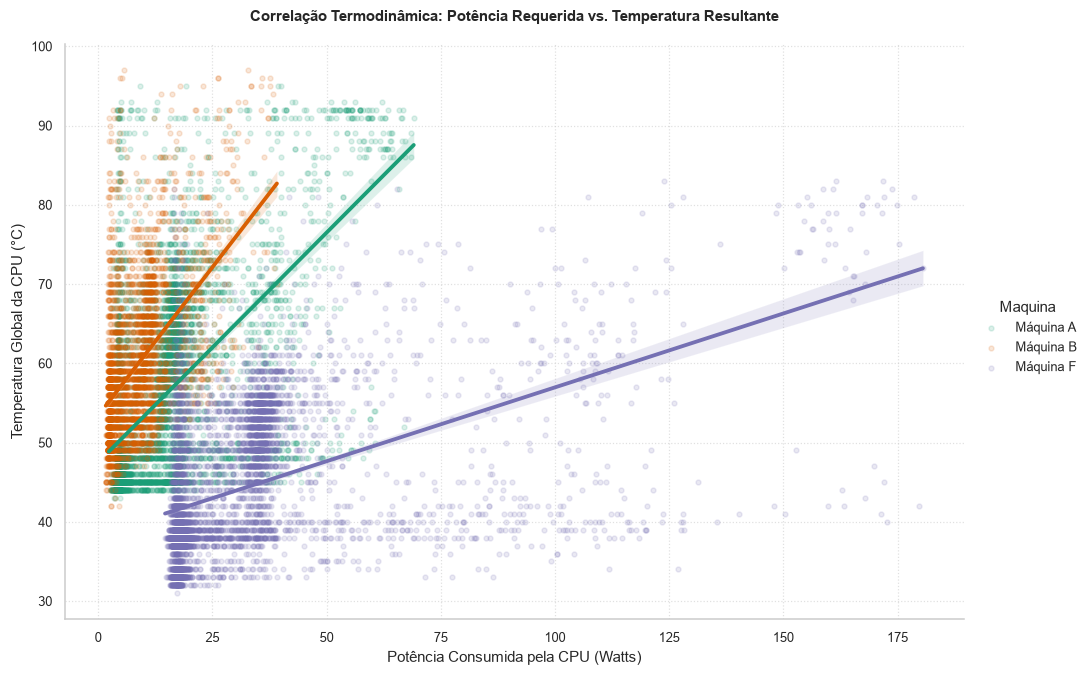

💾 Gráfico 3 salvo com sucesso em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_dispersão_potencia_vs_temperatura.png


In [95]:
# =====================================================================
# GRÁFICO 3: DISPERSÃO COM LINHA DE TENDÊNCIA (TDP COMO VARIÁVEL DOMINANTE)
# =====================================================================
plt.figure(figsize=(10, 6), dpi=300)

df_grafico3 = pd.read_csv(PASTA_PROCESSED / NOME_ARQUIVO_IMPUTED, low_memory=False)

# Plota as nuvens de pontos e as linhas de tendência de regressão para cada máquina
sns.lmplot(
    data=df_grafico3, 
    x='Potência total da CPU [W]', 
    y='CPU Inteira [°C]', 
    hue='Maquina', 
    palette="Dark2",
    height=6, 
    aspect=1.5,
    scatter_kws={'alpha': 0.15, 's': 10}, # Pontos translúcidos para destacar a densidade da nuvem
    line_kws={'linewidth': 2.5}
)

# Títulos e eixos no padrão internacional de artigos
plt.title("Correlação Termodinâmica: Potência Requerida vs. Temperatura Resultante", fontweight='bold', pad=15)
plt.xlabel("Potência Consumida pela CPU (Watts)")
plt.ylabel("Temperatura Global da CPU (°C)")

plt.grid(True, linestyle=':', alpha=0.6)

# Captura a figura do lmplot para salvar corretamente
fig_scatter = plt.gcf()
caminho_grafico3 = PASTA_PROCESSED / "grafico_dispersão_potencia_vs_temperatura.png"
fig_scatter.savefig(caminho_grafico3, bbox_inches='tight', dpi=300)
plt.show()
print(f"💾 Gráfico 3 salvo com sucesso em:\n   📍 {caminho_grafico3}")


📂 Carregando arquivos de scores das rodadas...
   ✅ scores_maqA.txt carregado (Média MC: 8116.5)
   ✅ scores_maqB.txt carregado (Média MC: 6107.7)
   ✅ scores_maqF.txt carregado (Média MC: 14218.8)


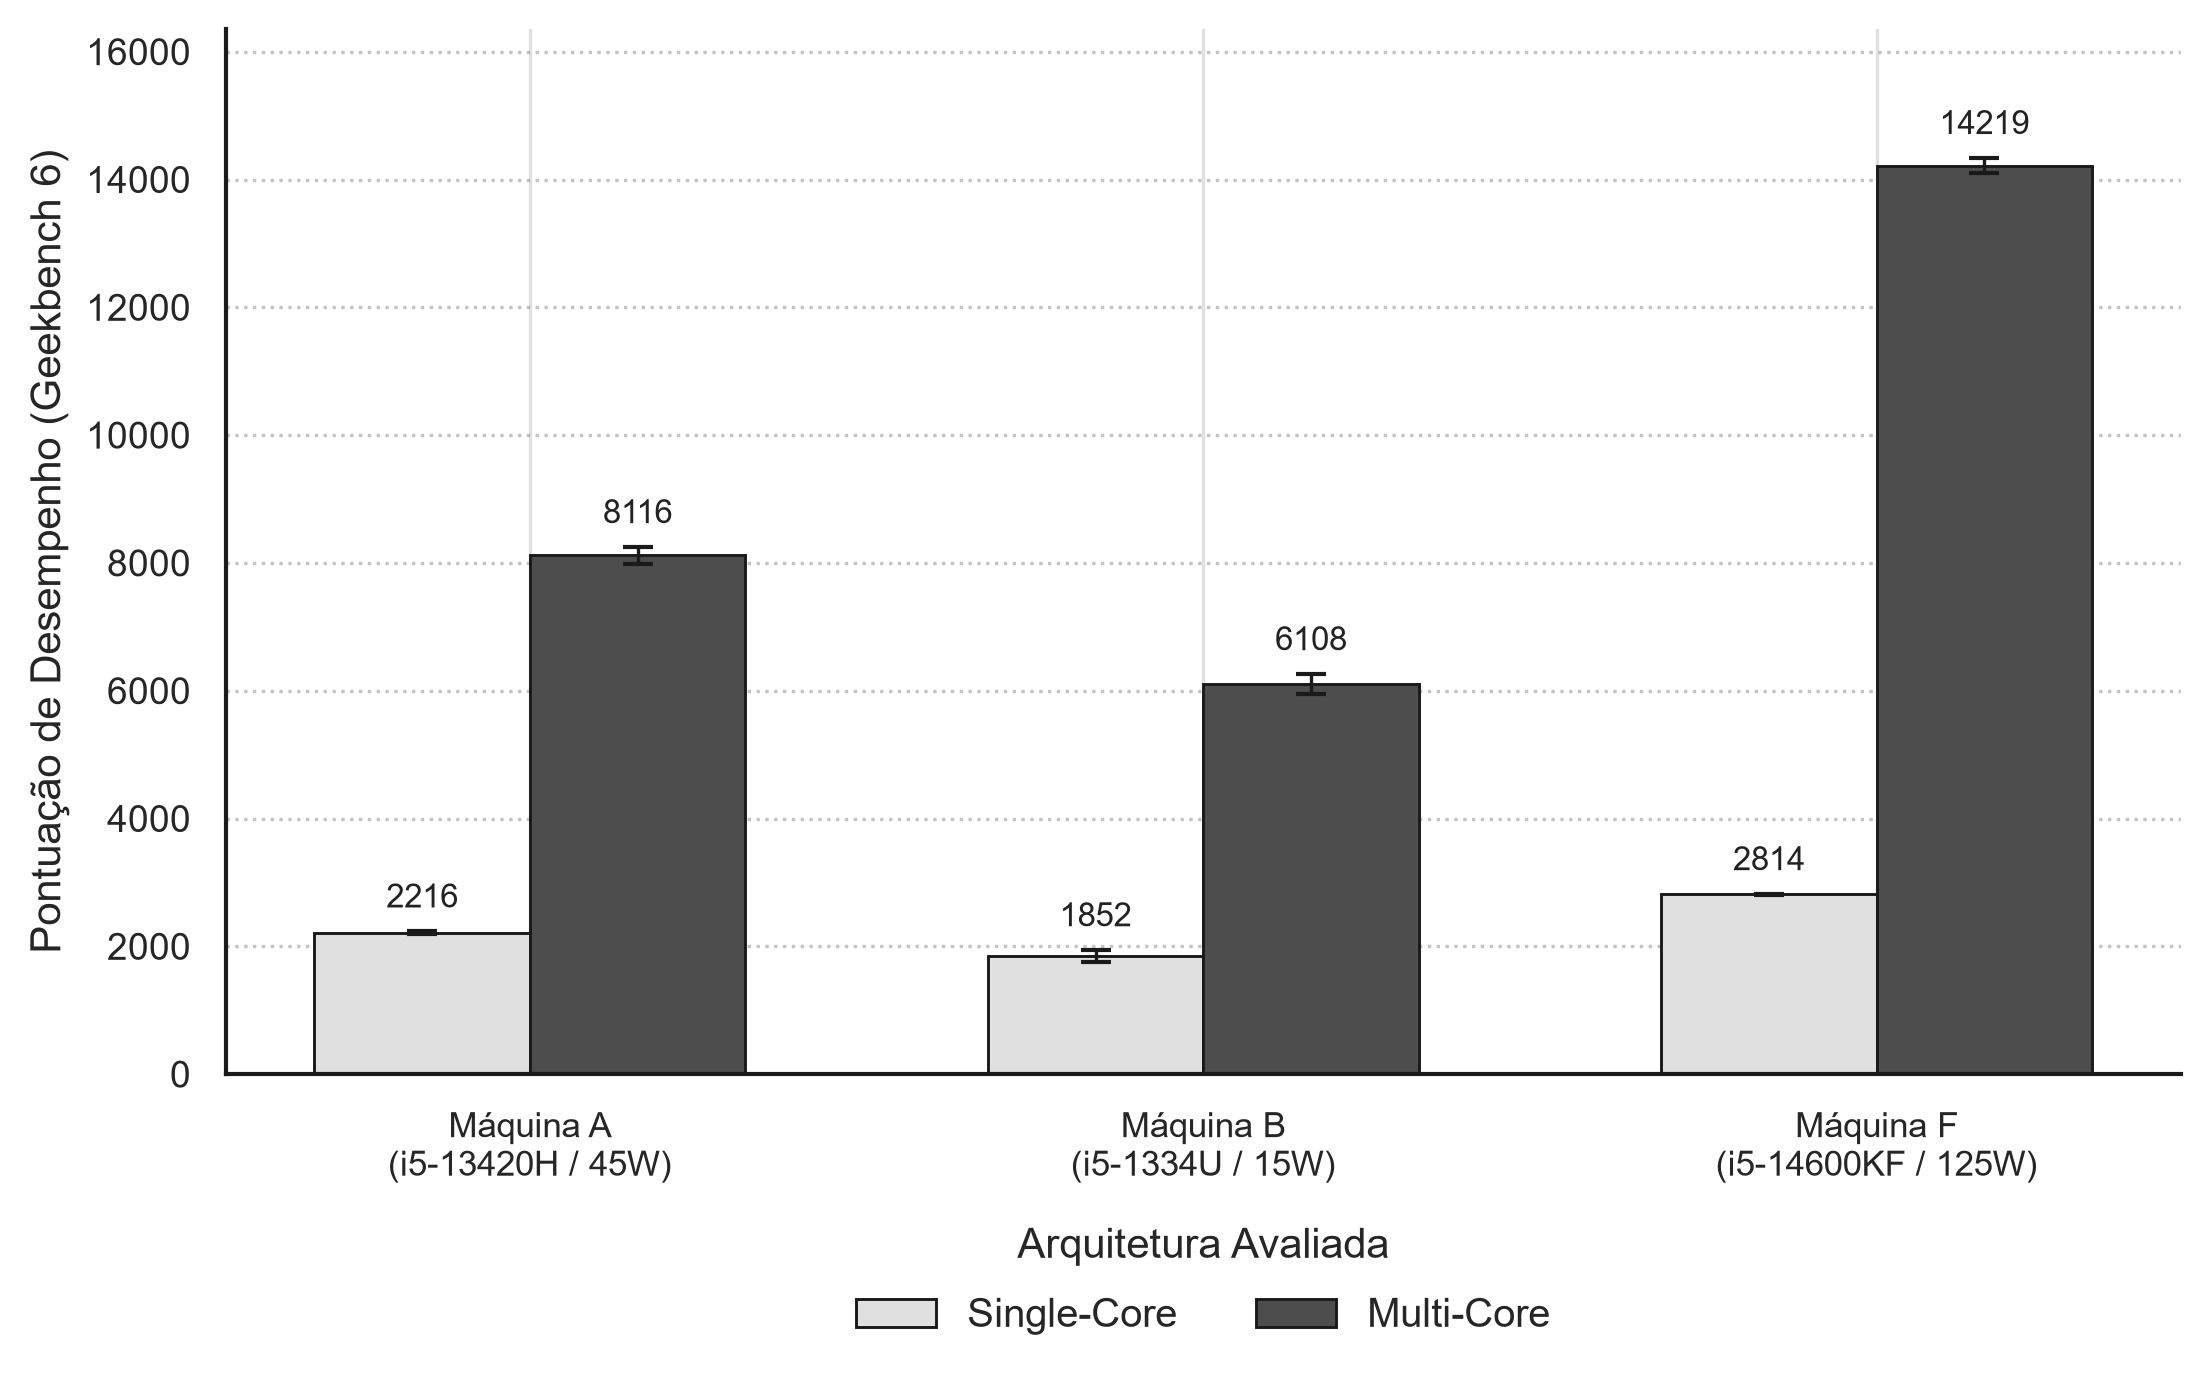


🚀 Pipeline concluído! Gráfico gerado estritamente no padrão SBC e salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_barras_comparativo_benchmark_scores.png


In [96]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: DEFINA AS MÁQUINAS QUE ENTRARÃO NO GRÁFICO
# =====================================================================
# O script vai procurar as pastas correspondentes em data/raw/
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

lista_dados_benchmark = []

print("📂 Carregando arquivos de scores das rodadas...")

# =====================================================================
# 2. LEITURA DINÂMICA DOS ARQUIVOS TXT POR MÁQUINA
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    sufixo = nome_pasta.replace("machine_", "").upper()
    
    if not pasta_origem.is_dir():
        print(f"⚠️ Pasta não encontrada: {pasta_origem.name}. Pulando...")
        continue
        
    # Busca por arquivos txt que comecem com 'scores_' na pasta da máquina
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    
    if arquivos_txt:
        caminho_txt = arquivos_txt[0]
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        df_scores_txt['Single_Core'] = pd.to_numeric(df_scores_txt['Single_Core'], errors='coerce')
        df_scores_txt['Multi_Core'] = pd.to_numeric(df_scores_txt['Multi_Core'], errors='coerce')
        
        # Calcula as métricas reais com base nas 20 rodadas do arquivo
        sc_media = df_scores_txt['Single_Core'].mean()
        sc_std = df_scores_txt['Single_Core'].astype(float).std()
        mc_media = df_scores_txt['Multi_Core'].mean()
        mc_std = df_scores_txt['Multi_Core'].astype(float).std()
        
        lista_dados_benchmark.append({
            "maquina": f"Máquina {sufixo}",
            "Single_Core_media": sc_media,
            "Single_Core_desvio_padrao": sc_std,
            "Multi_Core_media": mc_media,
            "Multi_Core_desvio_padrao": mc_std
        })
        print(f"   ✅ {caminho_txt.name} carregado (Média MC: {mc_media:.1f})")
    else:
        print(f"   ❌ Nenhum arquivo 'scores_*.txt' encontrado dentro de {nome_pasta}.")

# 🎯 CRIAÇÃO DA VARIÁVEL: df_plot é gerada aqui de forma garantida
df_plot = pd.DataFrame(lista_dados_benchmark)

# =====================================================================
# 3. RENDERIZAÇÃO DO PLOT CIENTÍFICO (PADRÃO ESTRITO SBC + PREMIUM TEXT)
# =====================================================================
if not df_plot.empty:
    posicoes = np.arange(len(df_plot["maquina"]))
    largura_barra = 0.32
    
    # Proporção SBC ideal para artigos em duas colunas ou formato livro
    fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=300)
    
    # 1. Barras de Single-Core (Cinza Claro) com desvio padrão real
    barras_single = ax.bar(
        posicoes - largura_barra/2, 
        df_plot["Single_Core_media"], 
        largura_barra, 
        yerr=df_plot["Single_Core_desvio_padrao"], 
        label="Single-Core",
        color="#e0e0e0",  
        edgecolor="#1a1a1a", 
        linewidth=0.7,
        capsize=3.5,
        error_kw={"elinewidth": 0.8, "ecolor": "#1a1a1a"}
    )
    
    # 2. Barras de Multi-Core (Cinza Escuro) com desvio padrão real
    barras_multi = ax.bar(
        posicoes + largura_barra/2, 
        df_plot["Multi_Core_media"], 
        largura_barra, 
        yerr=df_plot["Multi_Core_desvio_padrao"], 
        label="Multi-Core",
        color="#4d4d4d",  
        edgecolor="#1a1a1a", 
        linewidth=0.7,
        capsize=3.5,
        error_kw={"elinewidth": 0.8, "ecolor": "#1a1a1a"}
    )
    
    # Rótulos internos (valores inteiros arredondados acima das barras)
    ax.bar_label(barras_single, fmt='%.0f', padding=4, fontsize=8, color="#222222")
    ax.bar_label(barras_multi, fmt='%.0f', padding=4, fontsize=8, color="#222222")
    
    # Configuração dos eixos limpos de acordo com as normas científicas
    ax.set_ylabel("Pontuação de Desempenho (Geekbench 6)", fontsize=10)
    ax.set_xlabel("Arquitetura Avaliada", fontsize=10, labelpad=10)
    
    # 🎯 CORREÇÃO DO EIXO X: Vincula as máquinas abstratas aos componentes reais da sua tabela
    rotulos_customizados = [
        "Máquina A\n(i5-13420H / 45W)", 
        "Máquina B\n(i5-1334U / 15W)", 
        "Máquina F\n(i5-14600KF / 125W)"
    ]
    
    ax.set_xticks(posicoes)
    ax.set_xticklabels(rotulos_customizados, rotation=0, fontsize=8.5, fontweight='medium')
    
    # Linhas de grade sutis para auxílio visual na leitura analítica
    ax.grid(axis="y", linestyle=":", alpha=0.5, color="#888888")
    ax.set_ylim(0, df_plot["Multi_Core_media"].max() * 1.15)
    
    # 🎯 LEGENDA SBC: Parte central inferior externa, sem bordas pesadas e em uma linha horizontal
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18), 
        ncol=2,
        frameon=False,
        fontsize=9.5
    )
    
    # Moldura minimalista limpa (remove bordas superior e direita redundantes)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#1a1a1a')
    ax.spines['bottom'].set_color('#1a1a1a')
    
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.24) # Margem de respiro inferior para acomodar a legenda e o eixo X expandido
    
    # Salva o gráfico definitivo na pasta correta do pipeline
    caminho_grafico = PASTA_PROCESSED / "grafico_barras_comparativo_benchmark_scores.png"
    plt.savefig(caminho_grafico, bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"\n🚀 Pipeline concluído! Gráfico gerado estritamente no padrão SBC e salvo em:\n   📍 {caminho_grafico}")
else:
    print("\n❌ Não foi possível gerar o gráfico pois df_plot está vazio. Verifique se os arquivos TXT existem.")


📂 Carregando rodadas para o gráfico de evolução...
   ✅ Linha de evolução da MACHINE_A plotada.
   ✅ Linha de evolução da MACHINE_B plotada.
   ✅ Linha de evolução da MACHINE_F plotada.


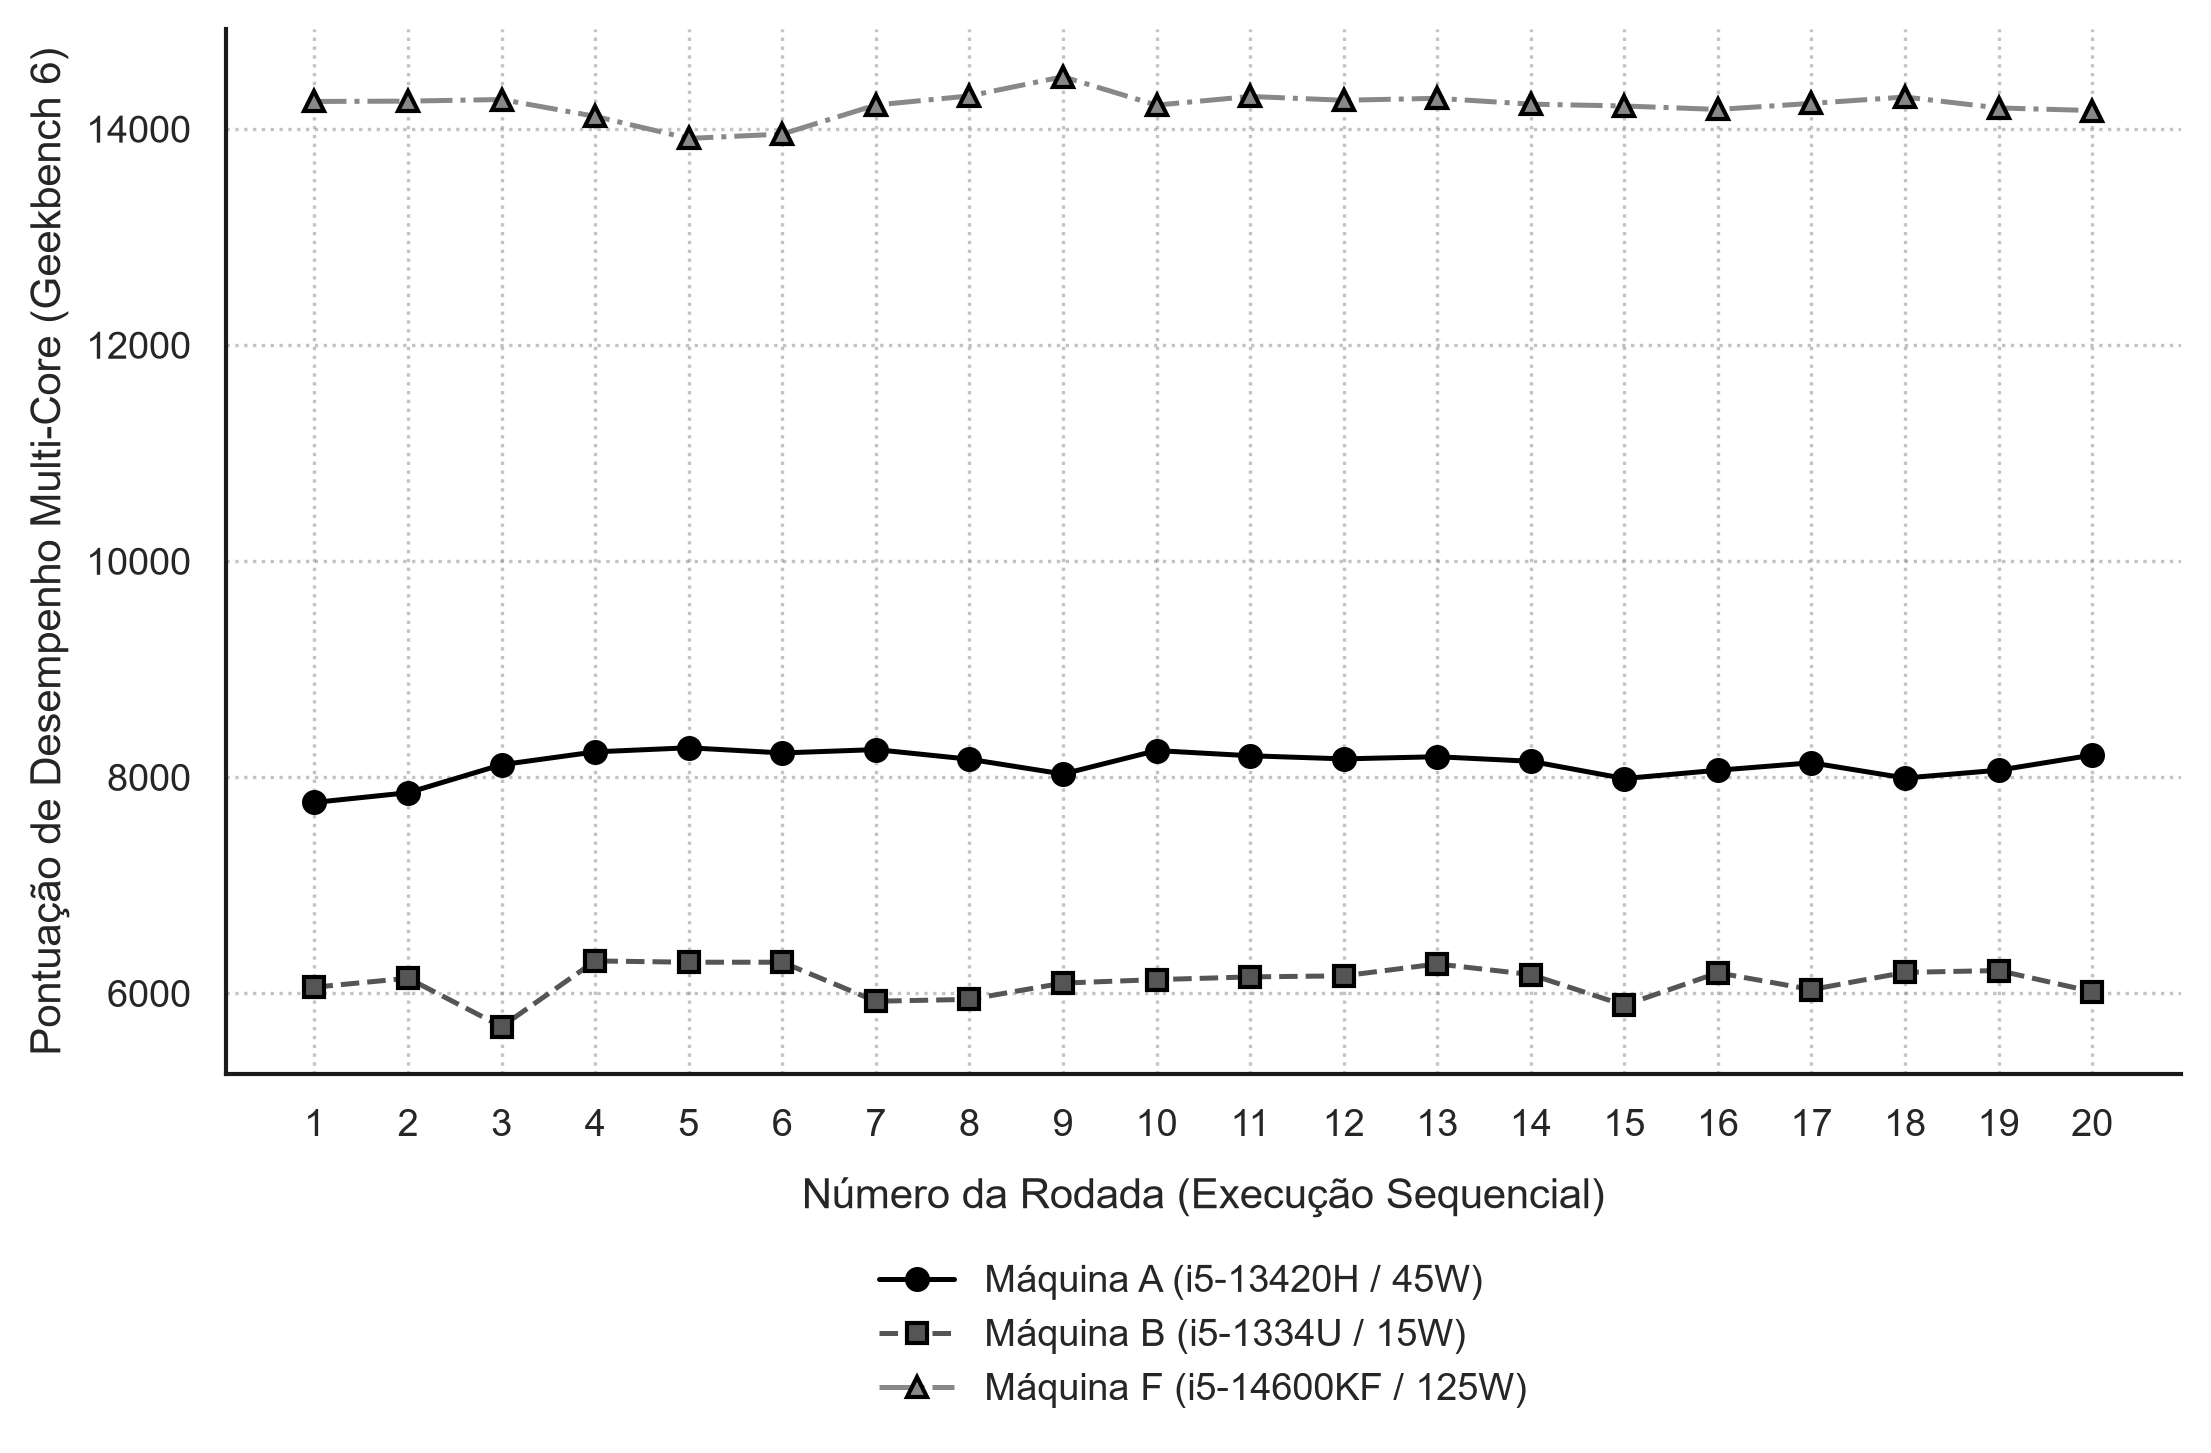


🚀 Sucesso! Gráfico temporal SBC gerado com base nos arquivos TXT e salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_linhas_evolucao_rodadas_multicore.png


In [97]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: DEFINA AS MÁQUINAS QUE ENTRARÃO NO GRÁFICO DE LINHAS
# =====================================================================
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

# Dicionário de exibição premium mapeando os códigos aos processadores reais da sua tabela técnica
NOMES_EXIBICAO = {
    "machine_a": "Máquina A (i5-13420H / 45W)",
    "machine_b": "Máquina B (i5-1334U / 15W)",
    "machine_f": "Máquina F (i5-14600KF / 125W)"
}

# Configurações de estilo SBC em escala de cinza e alta distinção geométrica
estilos_marcadores = ["o", "s", "^"]
estilos_linhas = ["-", "--", "-."]
cores_sbc = ["#000000", "#555555", "#888888"]

# Inicializa a figura na proporção SBC para artigos
fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=300)
idx = 0
maquinas_carregadas_sucesso = 0

print("📂 Carregando rodadas para o gráfico de evolução...")

# =====================================================================
# 2. LEITURA E PLOTAGEM DINÂMICA DAS LINHAS POR RODADA
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    
    if not pasta_origem.is_dir():
        print(f"⚠️ Pasta não encontrada: {pasta_origem.name}. Pulando...")
        continue
        
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    
    if arquivos_txt:
        caminho_txt = arquivos_txt[0]
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        # Extrai e limpa a série temporal de scores Multi-Core
        df_scores_txt['Multi_Core'] = pd.to_numeric(df_scores_txt['Multi_Core'], errors='coerce')
        scores_multi = df_scores_txt['Multi_Core'].dropna().tolist()
        
        if not scores_multi:
            continue
            
        # Cria a contagem sequencial das rodadas (Ex: 1 a 20)
        rodadas = list(range(1, len(scores_multi) + 1))
        
        # Plota a linha da respectiva arquitetura com marcadores geométricos pretos/cinzas
        ax.plot(
            rodadas, 
            scores_multi, 
            label=NOMES_EXIBICAO.get(nome_pasta, nome_pasta.upper()),
            marker=estilos_marcadores[idx % len(estilos_marcadores)],
            linestyle=estilos_linhas[idx % len(estilos_linhas)],
            color=cores_sbc[idx % len(cores_sbc)],
            linewidth=1.2,
            markersize=5,
            markeredgecolor="#000000"
        )
        idx += 1
        maquinas_carregadas_sucesso += 1
        print(f"   ✅ Linha de evolução da {nome_pasta.upper()} plotada.")
    else:
        print(f"   ❌ Nenhum arquivo 'scores_*.txt' encontrado dentro de {nome_pasta}.")

# =====================================================================
# 3. AJUSTES DE LAYOUT E MOLDURA CIENTÍFICA (ESTRITO SBC)
# =====================================================================
if maquinas_carregadas_sucesso > 0:
    # 🎯 DIRETRIZ SBC: Sem título interno (ax.set_title removido). O título vai no \caption do LaTeX.
    
    # Rótulos científicos padronizados e refinados
    ax.set_xlabel("Número da Rodada (Execução Sequencial)", fontsize=10, labelpad=8)
    ax.set_ylabel("Pontuação de Desempenho Multi-Core (Geekbench 6)", fontsize=10)
    
    # Força a exibição exata das 20 marcas inteiras no eixo X
    ax.set_xticks(range(1, 21))
    ax.tick_params(axis='both', labelsize=9)
    
    # 🎯 LEGENDA SBC: Parte Central Inferior Externa, horizontalizada (ncol) e sem bordas duras
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15), 
        ncol=1, # Mantido 1 por linha para não esmagar as strings longas dos processadores
        frameon=False,
        fontsize=9
    )
    
    # Grade de auxílio e moldura minimalista
    ax.grid(axis="both", linestyle=":", alpha=0.5, color="#888888")
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#1a1a1a')
    ax.spines['bottom'].set_color('#1a1a1a')
    
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.24) # Respiro na base para acomodar a legenda e rótulos
    
    # 📝 NOMEAÇÃO RELATIVA À AÇÃO: Salva no repositório processado central
    caminho_figura_3 = PASTA_PROCESSED / "grafico_linhas_evolucao_rodadas_multicore.png"
    plt.savefig(caminho_figura_3, bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"\n🚀 Sucesso! Gráfico temporal SBC gerado com base nos arquivos TXT e salvo em:\n   📍 {caminho_figura_3}")
else:
    print("\n❌ Nenhuma linha pôde ser traçada. Verifique os arquivos TXT de score.")
    plt.close()


📂 Carregando rodadas para o gráfico de evolução Single-Core...
   ✅ Linha de evolução da MACHINE_A plotada.
   ✅ Linha de evolução da MACHINE_B plotada.
   ✅ Linha de evolução da MACHINE_F plotada.


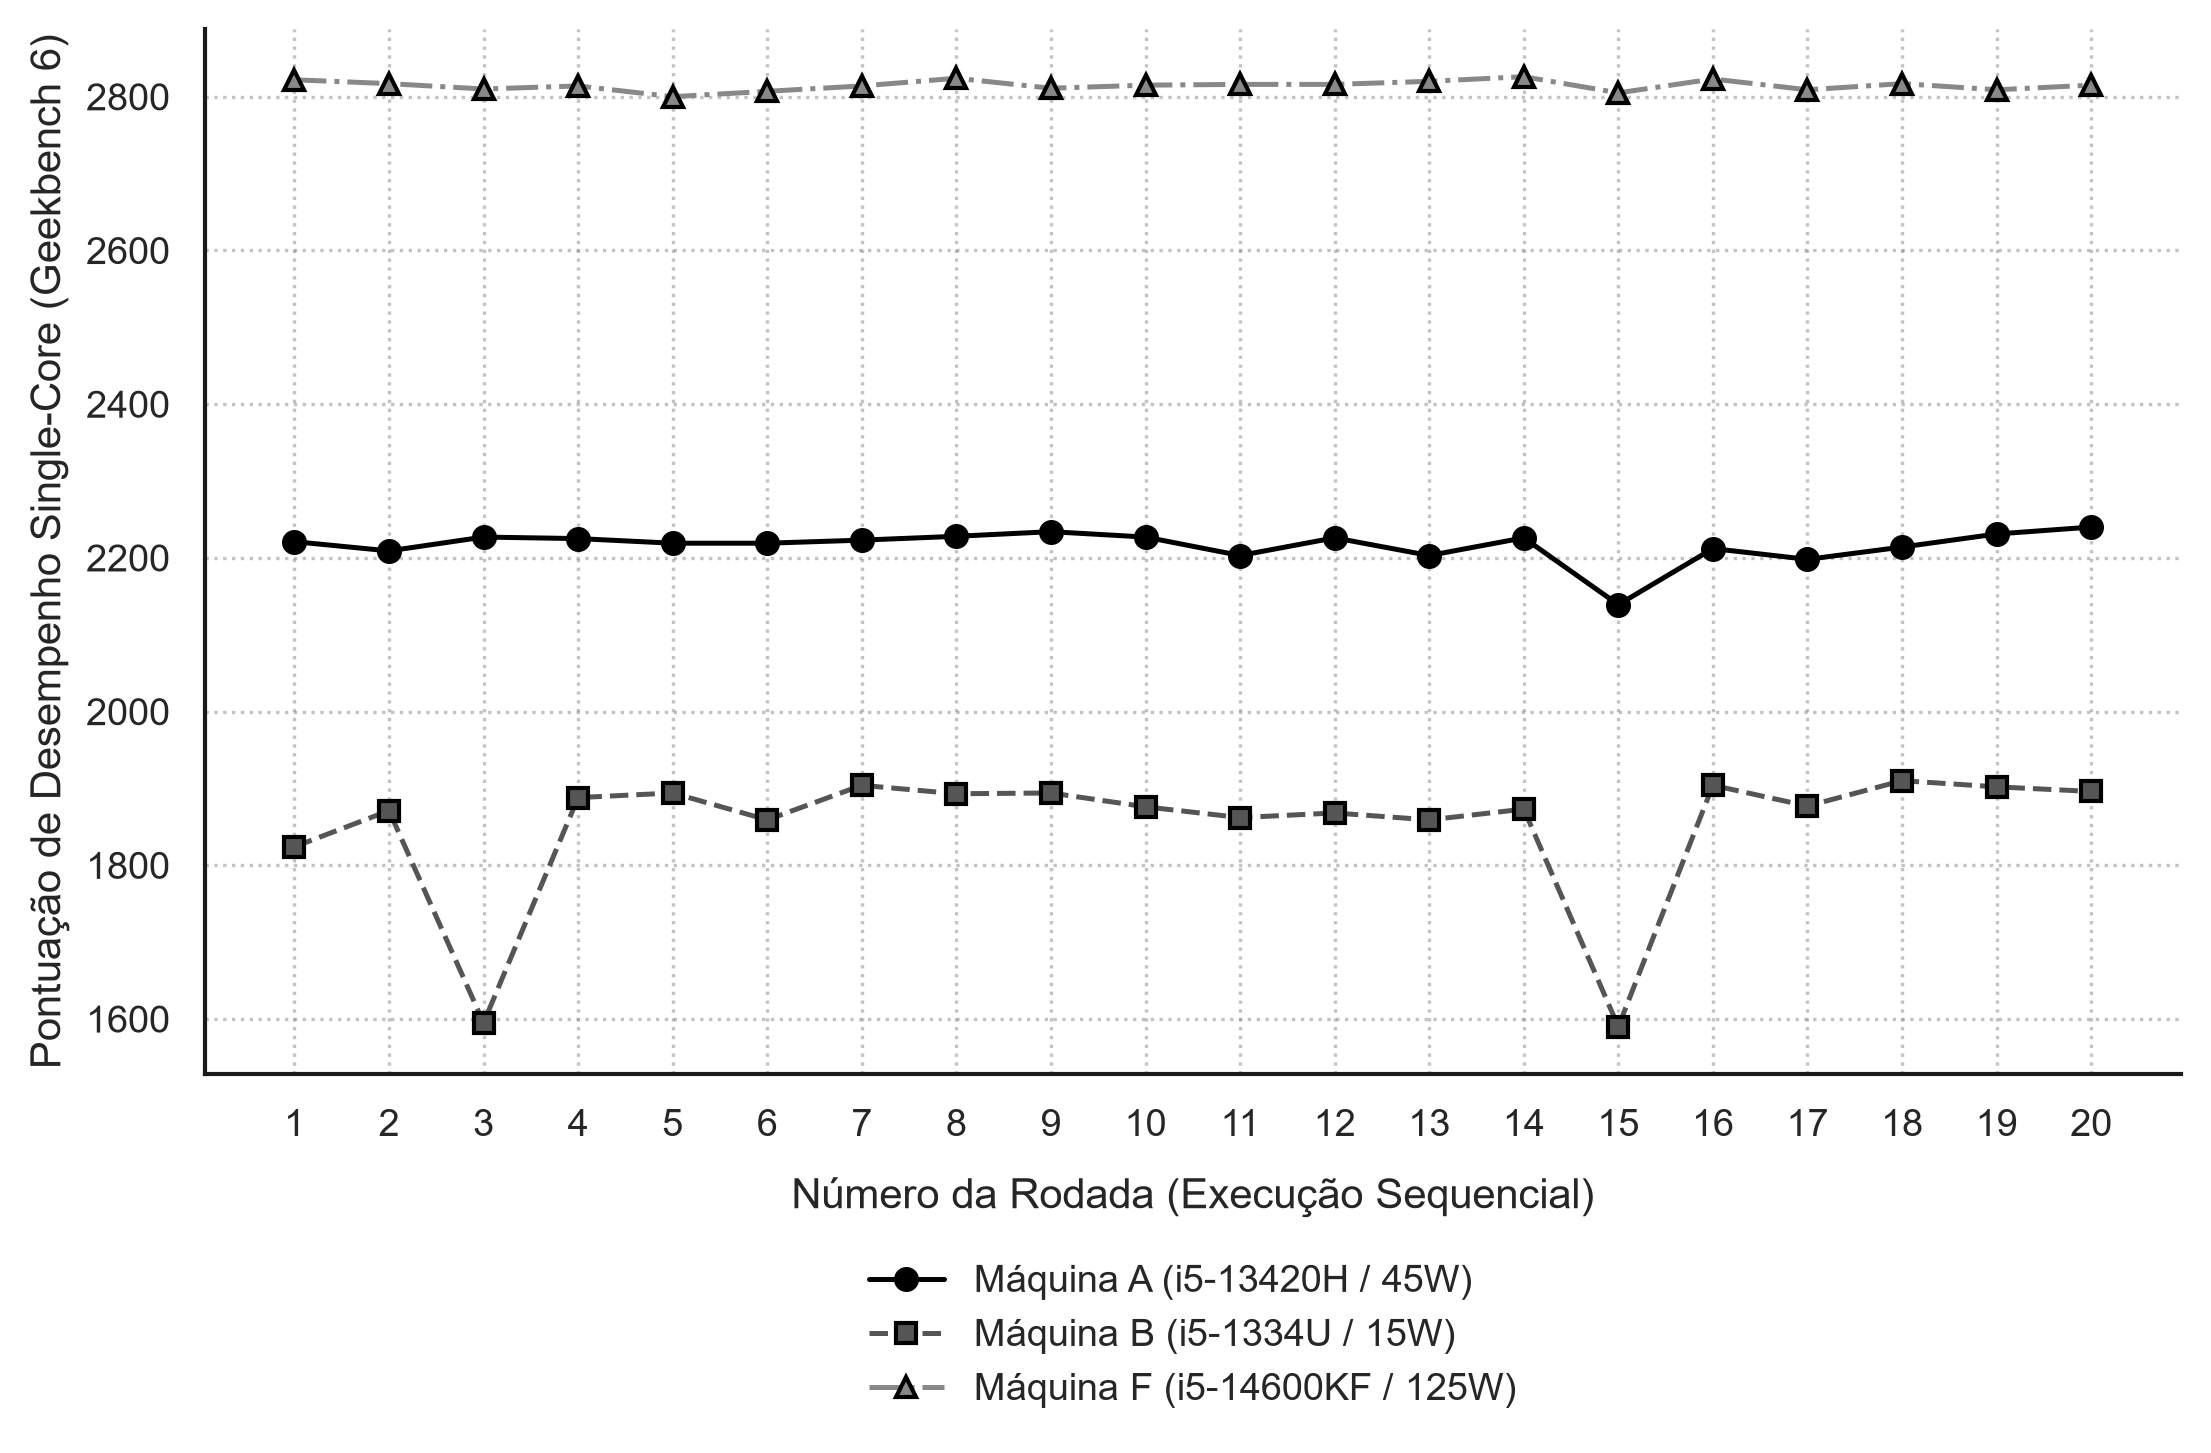


🚀 Sucesso! Gráfico temporal Single-Core SBC gerado e salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_linhas_evolucao_rodadas_singlecore.png


In [98]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: DEFINA AS MÁQUINAS QUE ENTRARÃO NO GRÁFICO SINGLE-CORE
# =====================================================================
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

# Dicionário de exibição premium mapeando os códigos aos processadores reais da sua tabela técnica
NOMES_EXIBICAO = {
    "machine_a": "Máquina A (i5-13420H / 45W)",
    "machine_b": "Máquina B (i5-1334U / 15W)",
    "machine_f": "Máquina F (i5-14600KF / 125W)"
}

# Configurações de estilo SBC em escala de cinza e alta distinção geométrica
estilos_marcadores = ["o", "s", "^"]
estilos_linhas = ["-", "--", "-."]
cores_sbc = ["#000000", "#555555", "#888888"]

# Inicializa a figura na proporção SBC para artigos
fig, ax = plt.subplots(figsize=(7.5, 4.8), dpi=300)
idx = 0
maquinas_carregadas_sucesso = 0

print("📂 Carregando rodadas para o gráfico de evolução Single-Core...")

# =====================================================================
# 2. LEITURA E PLOTAGEM DINÂMICA DAS LINHAS POR RODADA
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    
    if not pasta_origem.is_dir():
        print(f"⚠️ Pasta não encontrada: {pasta_origem.name}. Pulando...")
        continue
        
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    
    if arquivos_txt:
        caminho_txt = arquivos_txt[0]
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        # 🎯 ALTERAÇÃO: Extrai e limpa a série temporal de scores Single-Core
        df_scores_txt['Single_Core'] = pd.to_numeric(df_scores_txt['Single_Core'], errors='coerce')
        scores_single = df_scores_txt['Single_Core'].dropna().tolist()
        
        if not scores_single:
            continue
            
        # Cria a contagem sequencial das rodadas (Ex: 1 a 20)
        rodadas = list(range(1, len(scores_single) + 1))
        
        # Plota a linha da respectiva arquitetura com marcadores geométricos pretos/cinzas
        ax.plot(
            rodadas, 
            scores_single, 
            label=NOMES_EXIBICAO.get(nome_pasta, nome_pasta.upper()),
            marker=estilos_marcadores[idx % len(estilos_marcadores)],
            linestyle=estilos_linhas[idx % len(estilos_linhas)],
            color=cores_sbc[idx % len(cores_sbc)],
            linewidth=1.2,
            markersize=5,
            markeredgecolor="#000000"
        )
        idx += 1
        maquinas_carregadas_sucesso += 1
        print(f"   ✅ Linha de evolução da {nome_pasta.upper()} plotada.")
    else:
        print(f"   ❌ Nenhum arquivo 'scores_*.txt' encontrado dentro de {nome_pasta}.")

# =====================================================================
# 3. AJUSTES DE LAYOUT E MOLDURA CIENTÍFICA (ESTRITO SBC)
# =====================================================================
if maquinas_carregadas_sucesso > 0:
    # 🎯 DIRETRIZ SBC: Sem título interno. O título vai no \caption do LaTeX.
    
    # Rótulos científicos padronizados e refinados
    ax.set_xlabel("Número da Rodada (Execução Sequencial)", fontsize=10, labelpad=8)
    # 🎯 ALTERAÇÃO: Rótulo do eixo Y alterado para refletir Single-Core
    ax.set_ylabel("Pontuação de Desempenho Single-Core (Geekbench 6)", fontsize=10)
    
    # Força a exibição exata das 20 marcas inteiras no eixo X
    ax.set_xticks(range(1, 21))
    ax.tick_params(axis='both', labelsize=9)
    
    # 🎯 LEGENDA SBC: Parte Central Inferior Externa, horizontalizada e sem bordas duras
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15), 
        ncol=1, 
        frameon=False,
        fontsize=9
    )
    
    # Grade de auxílio e moldura minimalista
    ax.grid(axis="both", linestyle=":", alpha=0.5, color="#888888")
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#1a1a1a')
    ax.spines['bottom'].set_color('#1a1a1a')
    
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.24) # Respiro na base para acomodar a legenda e rótulos
    
    # 📝 NOMEAÇÃO RELATIVA À AÇÃO: Salva com o sufixo singlecore na pasta de resultados processados
    caminho_figura_single = PASTA_PROCESSED / "grafico_linhas_evolucao_rodadas_singlecore.png"
    plt.savefig(caminho_figura_single, bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"\n🚀 Sucesso! Gráfico temporal Single-Core SBC gerado e salvo em:\n   📍 {caminho_figura_single}")
else:
    print("\n❌ Nenhuma linha pôde ser traçada. Verifique os arquivos TXT de score.")
    plt.close()


📂 Carregando rodadas para o gráfico integrado (Single vs Multi)...


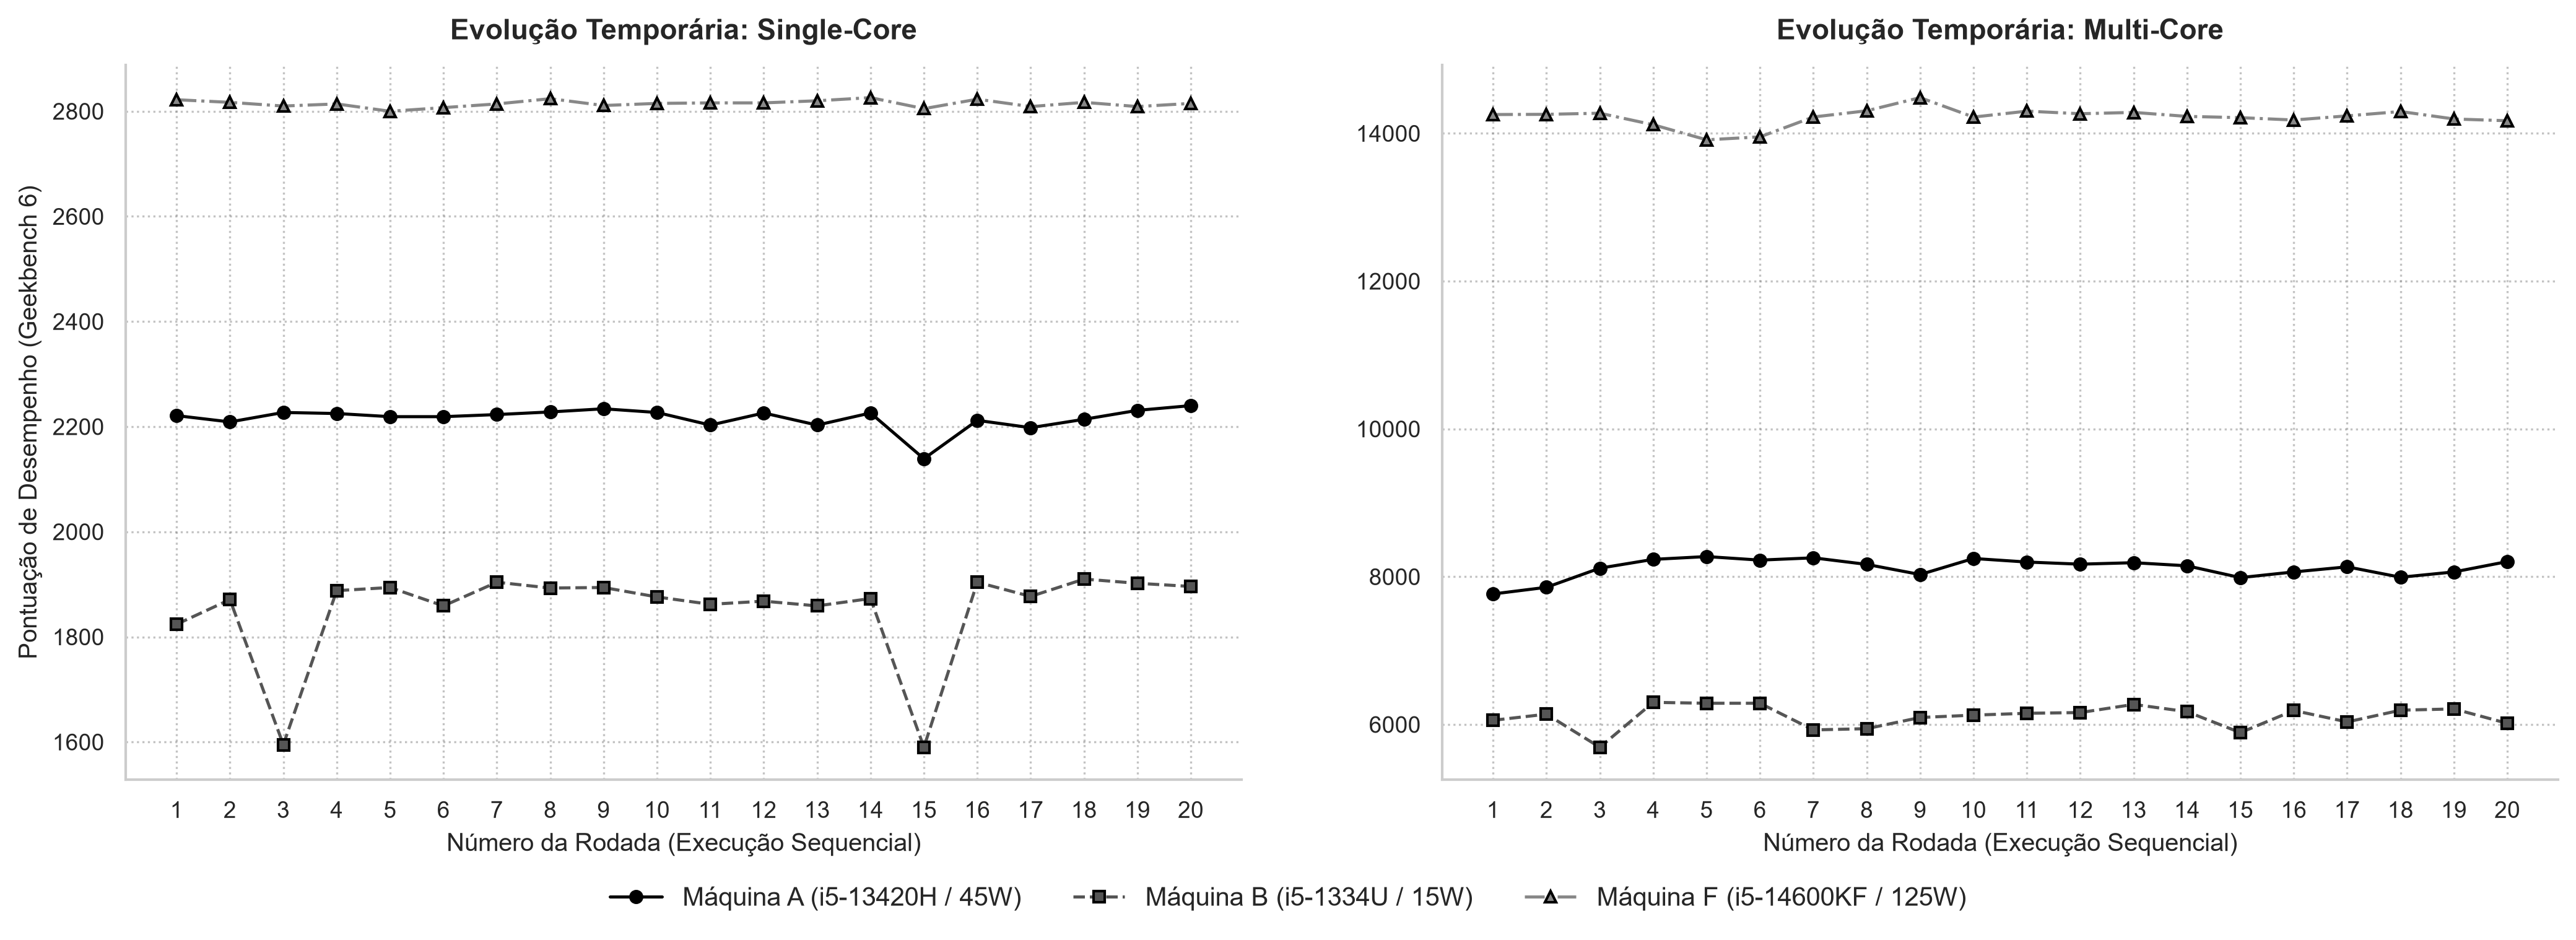


🚀 Sucesso! Gráfico combinado gerado sem poluição visual e salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_linhas_evolucao_rodadas_combined_single_multi.png


In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: DEFINA AS MÁQUINAS QUE ENTRARÃO NO GRÁFICO COMBINADO
# =====================================================================
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

NOMES_EXIBICAO = {
    "machine_a": "Máquina A (i5-13420H / 45W)",
    "machine_b": "Máquina B (i5-1334U / 15W)",
    "machine_f": "Máquina F (i5-14600KF / 125W)"
}

# Assinaturas visuais idênticas para manter a consistência entre as janelas
estilos_marcadores = ["o", "s", "^"]
estilos_linhas = ["-", "--", "-."]
cores_sbc = ["#000000", "#555555", "#888888"]

# Inicializa subplots lado a lado (1 linha, 2 colunas) em proporção widescreen acadêmica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), dpi=300)
idx = 0
maquinas_carregadas_sucesso = 0

print("📂 Carregando rodadas para o gráfico integrado (Single vs Multi)...")

# =====================================================================
# 2. LEITURA E PROCESSAMENTO DAS SÉRIES TEMPORAIS CONCOMITANTES
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    
    if not pasta_origem.is_dir():
        continue
        
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    
    if arquivos_txt:
        caminho_txt = arquivos_txt[0]
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        # Conversão forçada de tipos de dados para segurança matemática
        df_scores_txt['Single_Core'] = pd.to_numeric(df_scores_txt['Single_Core'], errors='coerce')
        df_scores_txt['Multi_Core'] = pd.to_numeric(df_scores_txt['Multi_Core'], errors='coerce')
        
        scores_single = df_scores_txt['Single_Core'].dropna().tolist()
        scores_multi = df_scores_txt['Multi_Core'].dropna().tolist()
        
        if not scores_single or not scores_multi:
            continue
            
        rodadas = list(range(1, len(scores_single) + 1))
        label_comum = NOMES_EXIBICAO.get(nome_pasta, nome_pasta.upper())
        
        # 📉 Janela 1 (Esquerda): Linhas de Evolução do Single-Core
        ax1.plot(
            rodadas, scores_single, label=label_comum,
            marker=estilos_marcadores[idx], linestyle=estilos_linhas[idx],
            color=cores_sbc[idx], linewidth=1.2, markersize=4.5, markeredgecolor="#000000"
        )
        
        # 📈 Janela 2 (Direita): Linhas de Evolução do Multi-Core
        ax2.plot(
            rodadas, scores_multi, label=label_comum,
            marker=estilos_marcadores[idx], linestyle=estilos_linhas[idx],
            color=cores_sbc[idx], linewidth=1.2, markersize=4.5, markeredgecolor="#000000"
        )
        idx += 1
        maquinas_carregadas_sucesso += 1

# =====================================================================
# 3. TRATAMENTO DE ACABAMENTO CIENTÍFICO INTEGRADO (SBC PREMIUM)
# =====================================================================
if maquinas_carregadas_sucesso > 0:
    # Ajustes finos da Janela 1 (Single-Core)
    ax1.set_title("Evolução Temporária: Single-Core", fontsize=11, fontweight='bold', pad=10)
    ax1.set_xlabel("Número da Rodada (Execução Sequencial)", fontsize=9.5)
    ax1.set_ylabel("Pontuação de Desempenho (Geekbench 6)", fontsize=9.5)
    ax1.set_xticks(range(1, 21))
    ax1.grid(axis="both", linestyle=":", alpha=0.5, color="#888888")
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Ajustes finos da Janela 2 (Multi-Core)
    ax2.set_title("Evolução Temporária: Multi-Core", fontsize=11, fontweight='bold', pad=10)
    ax2.set_xlabel("Número da Rodada (Execução Sequencial)", fontsize=9.5)
    ax2.set_xticks(range(1, 21))
    ax2.grid(axis="both", linestyle=":", alpha=0.5, color="#888888")
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # 🎯 ESTRATÉGIA ANTI-POLUIÇÃO: Extrai apenas uma legenda unificada centralizada na base
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(
        handles, labels, 
        loc="lower center", 
        bbox_to_anchor=(0.5, 0.02), 
        ncol=3, 
        frameon=False, 
        fontsize=10
    )
    
    # Otimização de espaçamento para evitar cortes textuais ou sobreposição aérea
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.18, wspace=0.18)
    
    # 📝 NOME RELATIVO À AÇÃO: Registra a consolidação unificada
    caminho_saida_combo = PASTA_PROCESSED / "grafico_linhas_evolucao_rodadas_combined_single_multi.png"
    plt.savefig(caminho_saida_combo, bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"\n🚀 Sucesso! Gráfico combinado gerado sem poluição visual e salvo em:\n   📍 {caminho_saida_combo}")
else:
    print("\n❌ Falha na leitura dos dados estruturados.")
    plt.close()


📂 Processando rodadas concomitantes no mesmo plano cartesiano...


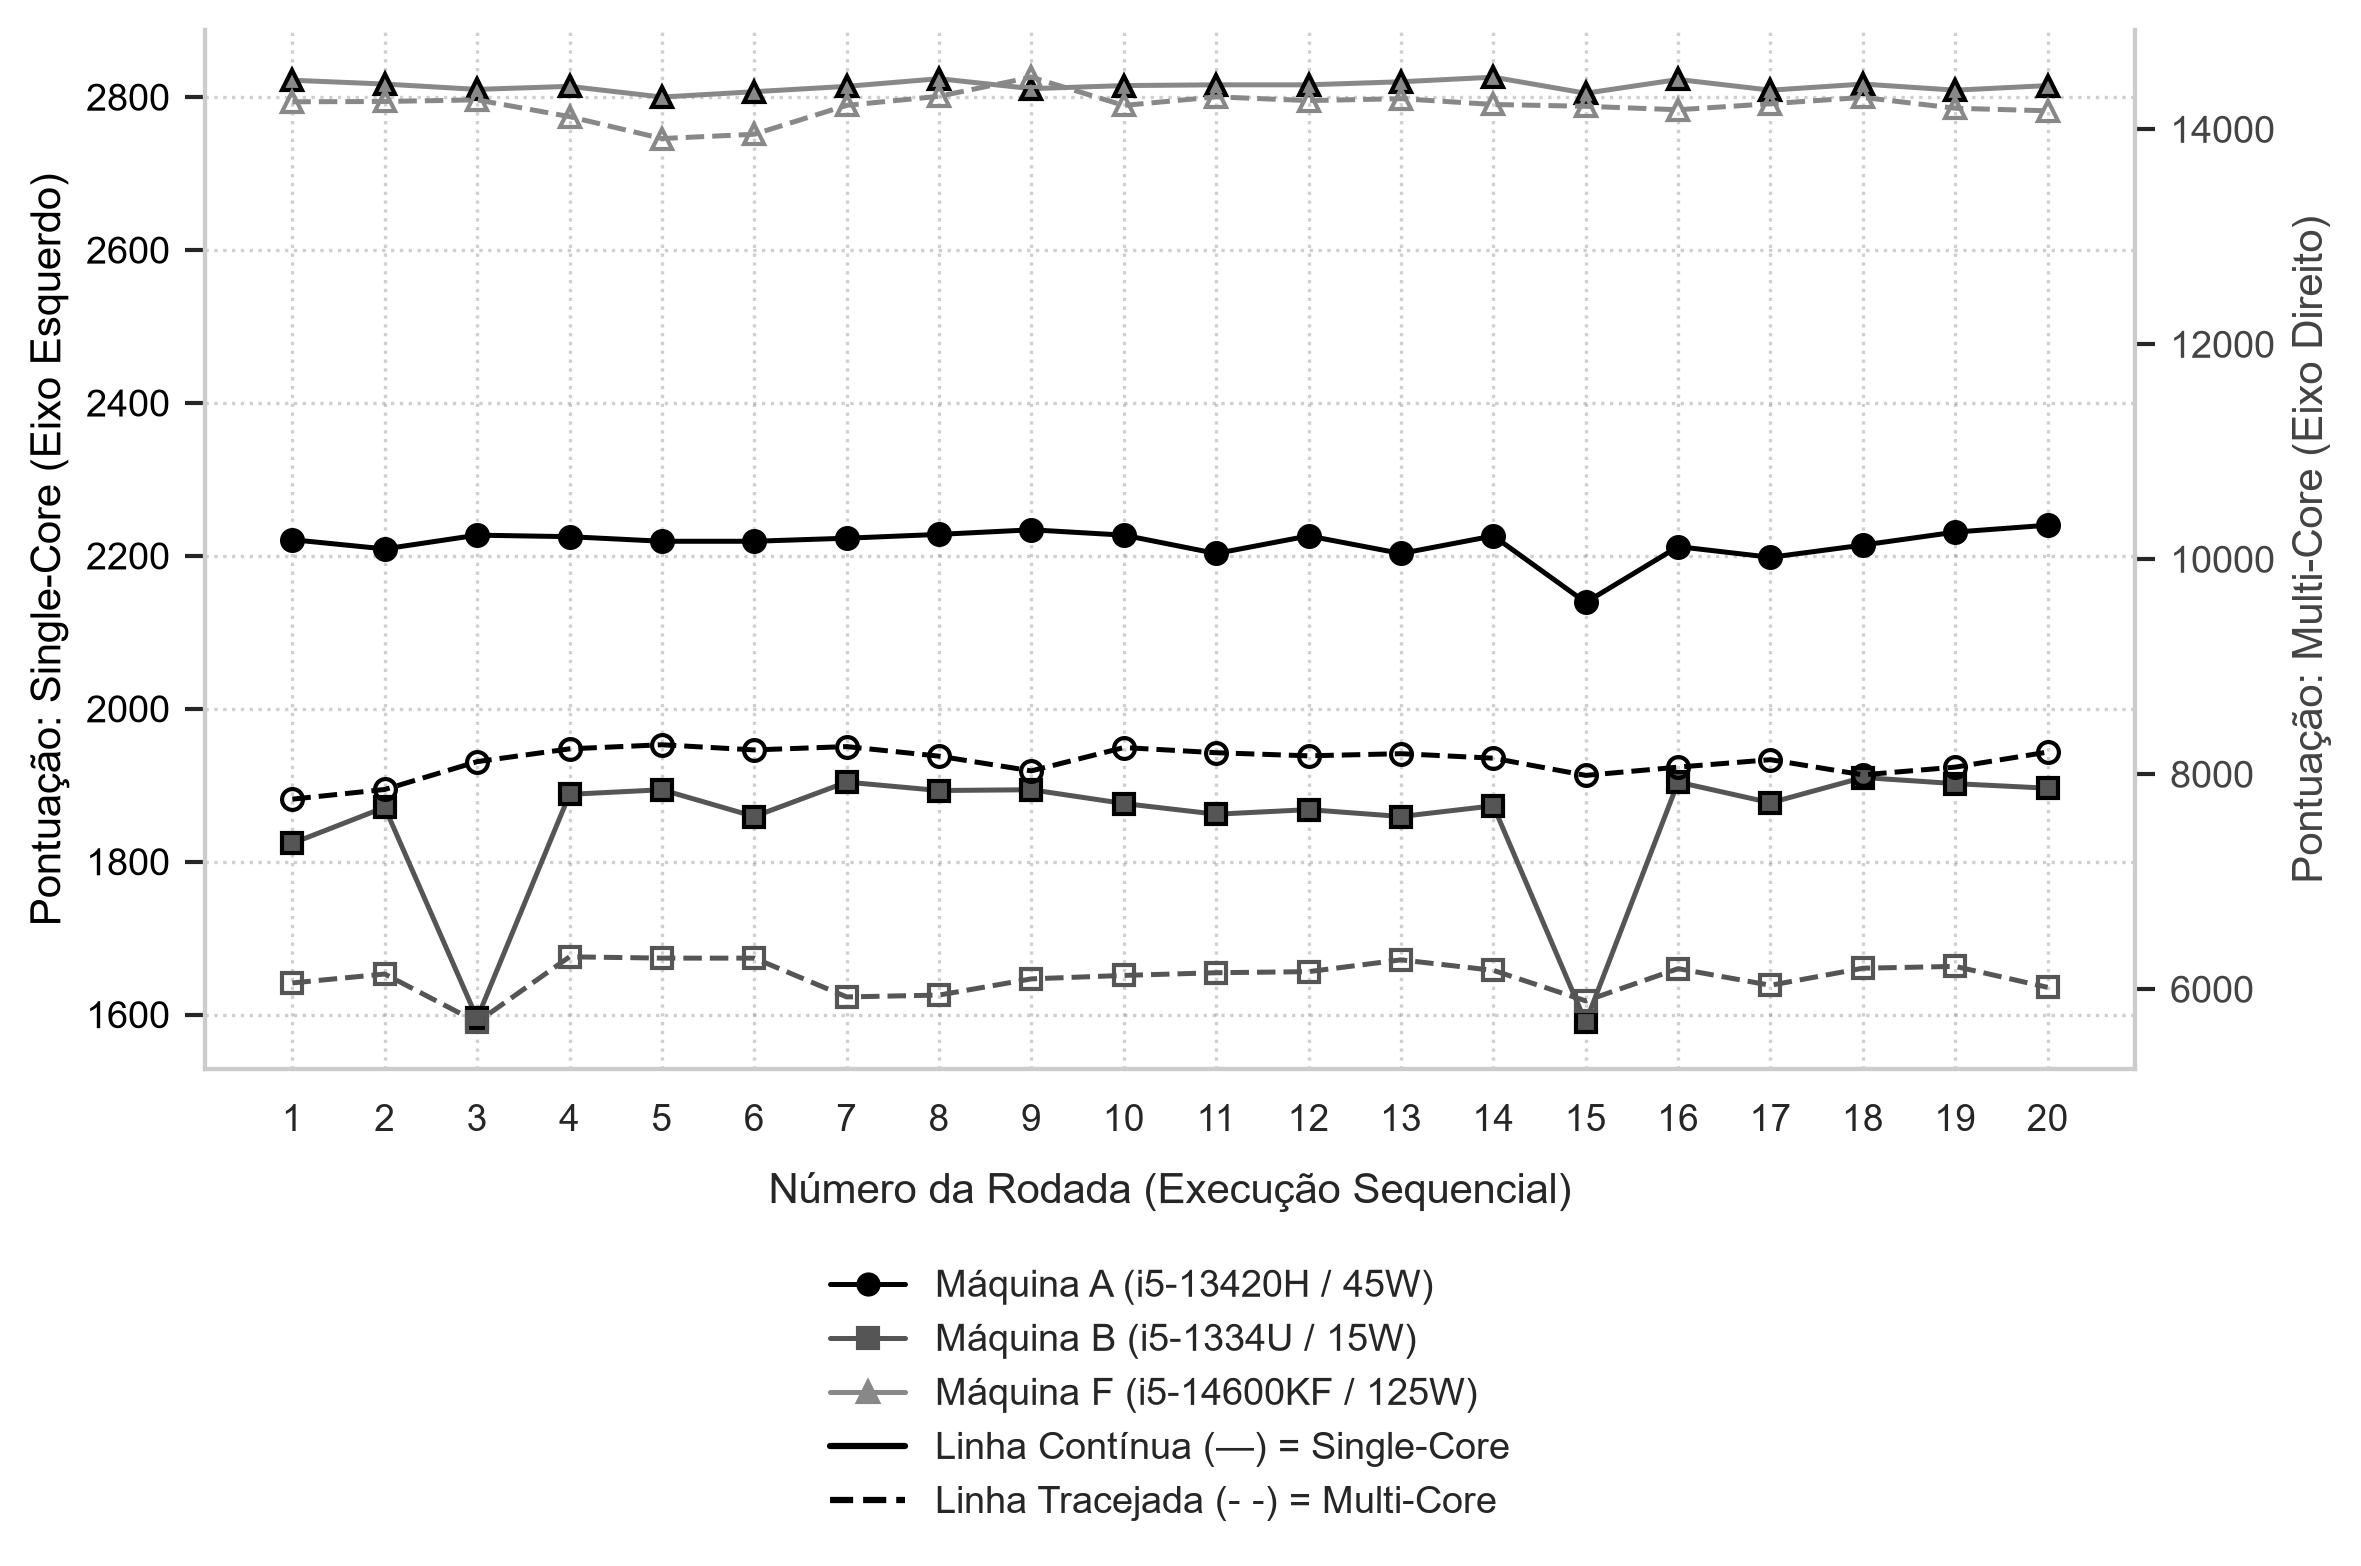


🚀 Sucesso! Gráfico bivariado gerado corretamente e salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_linhas_evolucao_rodadas_single_multi_mesmo_eixo.png


In [100]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: MÁQUINAS NO MESMO GRÁFICO (EIXO Y DUPLO)
# =====================================================================
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

# Identificadores visuais distintos por máquina para escala de cinza (SBC)
config_maquinas = {
    "machine_a": {"cor": "#000000", "marker": "o", "label": "Máquina A (i5-13420H / 45W)"},
    "machine_b": {"cor": "#555555", "marker": "s", "label": "Máquina B (i5-1334U / 15W)"},
    "machine_f": {"cor": "#888888", "marker": "^", "label": "Máquina F (i5-14600KF / 125W)"}
}

# Inicializa a estrutura do gráfico com o primeiro eixo Y (Esquerda)
fig, ax1 = plt.subplots(figsize=(8.0, 5.5), dpi=300)

# 🎯 CRIAÇÃO DO SEGUNDO EIXO Y (Direita) compartilhando o mesmo eixo X
ax2 = ax1.twinx()

print("📂 Processando rodadas concomitantes no mesmo plano cartesiano...")

# =====================================================================
# 2. LEITURA E JUXTAPOSIÇÃO DAS SÉRIES TEMPORAIS
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    if not pasta_origem.is_dir() or nome_pasta not in config_maquinas:
        continue
        
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    if arquivos_txt:
        caminho_txt = arquivos_txt[0]
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        df_scores_txt['Single_Core'] = pd.to_numeric(df_scores_txt['Single_Core'], errors='coerce')
        df_scores_txt['Multi_Core'] = pd.to_numeric(df_scores_txt['Multi_Core'], errors='coerce')
        
        rodadas = list(range(1, len(df_scores_txt) + 1))
        cfg = config_maquinas[nome_pasta]
        
        # 📉 1. Plota Single-Core (Eixo Esquerdo - Linha Contínua)
        ax1.plot(
            rodadas, 
            df_scores_txt['Single_Core'], 
            linestyle="-", 
            linewidth=1.2, 
            marker=cfg["marker"], 
            markersize=5,
            color=cfg["cor"], 
            markeredgecolor="#000000"
        )
        
        # 📈 2. Plota Multi-Core (Eixo Direito - Linha Tracejada)
        ax2.plot(
            rodadas, 
            df_scores_txt['Multi_Core'], 
            linestyle="--", 
            linewidth=1.2, 
            marker=cfg["marker"], 
            markersize=5,
            color=cfg["cor"], 
            markerfacecolor="none", 
            markeredgecolor=cfg["cor"]
        )

# =====================================================================
# 3. ACABAMENTO E DESIGN CIENTÍFICO ANTI-POLUIÇÃO (SBC)
# =====================================================================
# Configuração do Eixo X comum
ax1.set_xlabel("Número da Rodada (Execução Sequencial)", fontsize=10, labelpad=8)
ax1.set_xticks(range(1, 21))

# Configuração e calibração do Eixo Y1 (Esquerda - Single-Core)
ax1.set_ylabel("Pontuação: Single-Core (Eixo Esquerdo)", fontsize=10, color="#000000")
ax1.tick_params(axis='y', labelcolor="#000000", labelsize=9)
ax1.grid(axis="both", linestyle=":", alpha=0.4, color="#888888")

# Configuração e calibração do Eixo Y2 (Direita - Multi-Core)
ax2.set_ylabel("Pontuação: Multi-Core (Eixo Direito)", fontsize=10, color="#444444")
ax2.tick_params(axis='y', labelcolor="#444444", labelsize=9)
ax2.grid(False) # Desativa grade redundante para não poluir

# 🎯 MONTAGEM MANUAL DA LEGENDA UNIFICADA SEM ERROS DE POSIÇÃO
linhas_legenda = []
labels_legenda = []

# Adiciona as máquinas
for m in MAQUINAS_PARAMETRO:
    if m in config_maquinas:
        linhas_legenda.append(plt.Line2D(xdata=[], ydata=[], color=config_maquinas[m]["cor"], marker=config_maquinas[m]["marker"], linestyle="-"))
        labels_legenda.append(config_maquinas[m]["label"])

# Adiciona os guias descritivos de tipo de linha
linhas_legenda.append(plt.Line2D(xdata=[], ydata=[], color="#000000", linestyle="-", linewidth=1.5))
labels_legenda.append("Linha Contínua (—) = Single-Core")

linhas_legenda.append(plt.Line2D(xdata=[], ydata=[], color="#000000", linestyle="--", linewidth=1.5))
labels_legenda.append("Linha Tracejada (- -) = Multi-Core")

# Posicionamento da legenda expandida na base central inferior externa
ax1.legend(
    linhas_legenda, labels_legenda,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16), 
    ncol=1, 
    frameon=False,
    fontsize=9
)

# Moldura acadêmica limpa (remove borda superior)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.34) # Margem para a legenda de texto de 5 linhas

# Salva a imagem final consolidada
caminho_saida_twin = PASTA_PROCESSED / "grafico_linhas_evolucao_rodadas_single_multi_mesmo_eixo.png"
plt.savefig(caminho_saida_twin, bbox_inches='tight', dpi=300)
plt.show()

print(f"\n🚀 Sucesso! Gráfico bivariado gerado corretamente e salvo em:\n   📍 {caminho_saida_twin}")


📂 Processando rodadas em escala única unificada...


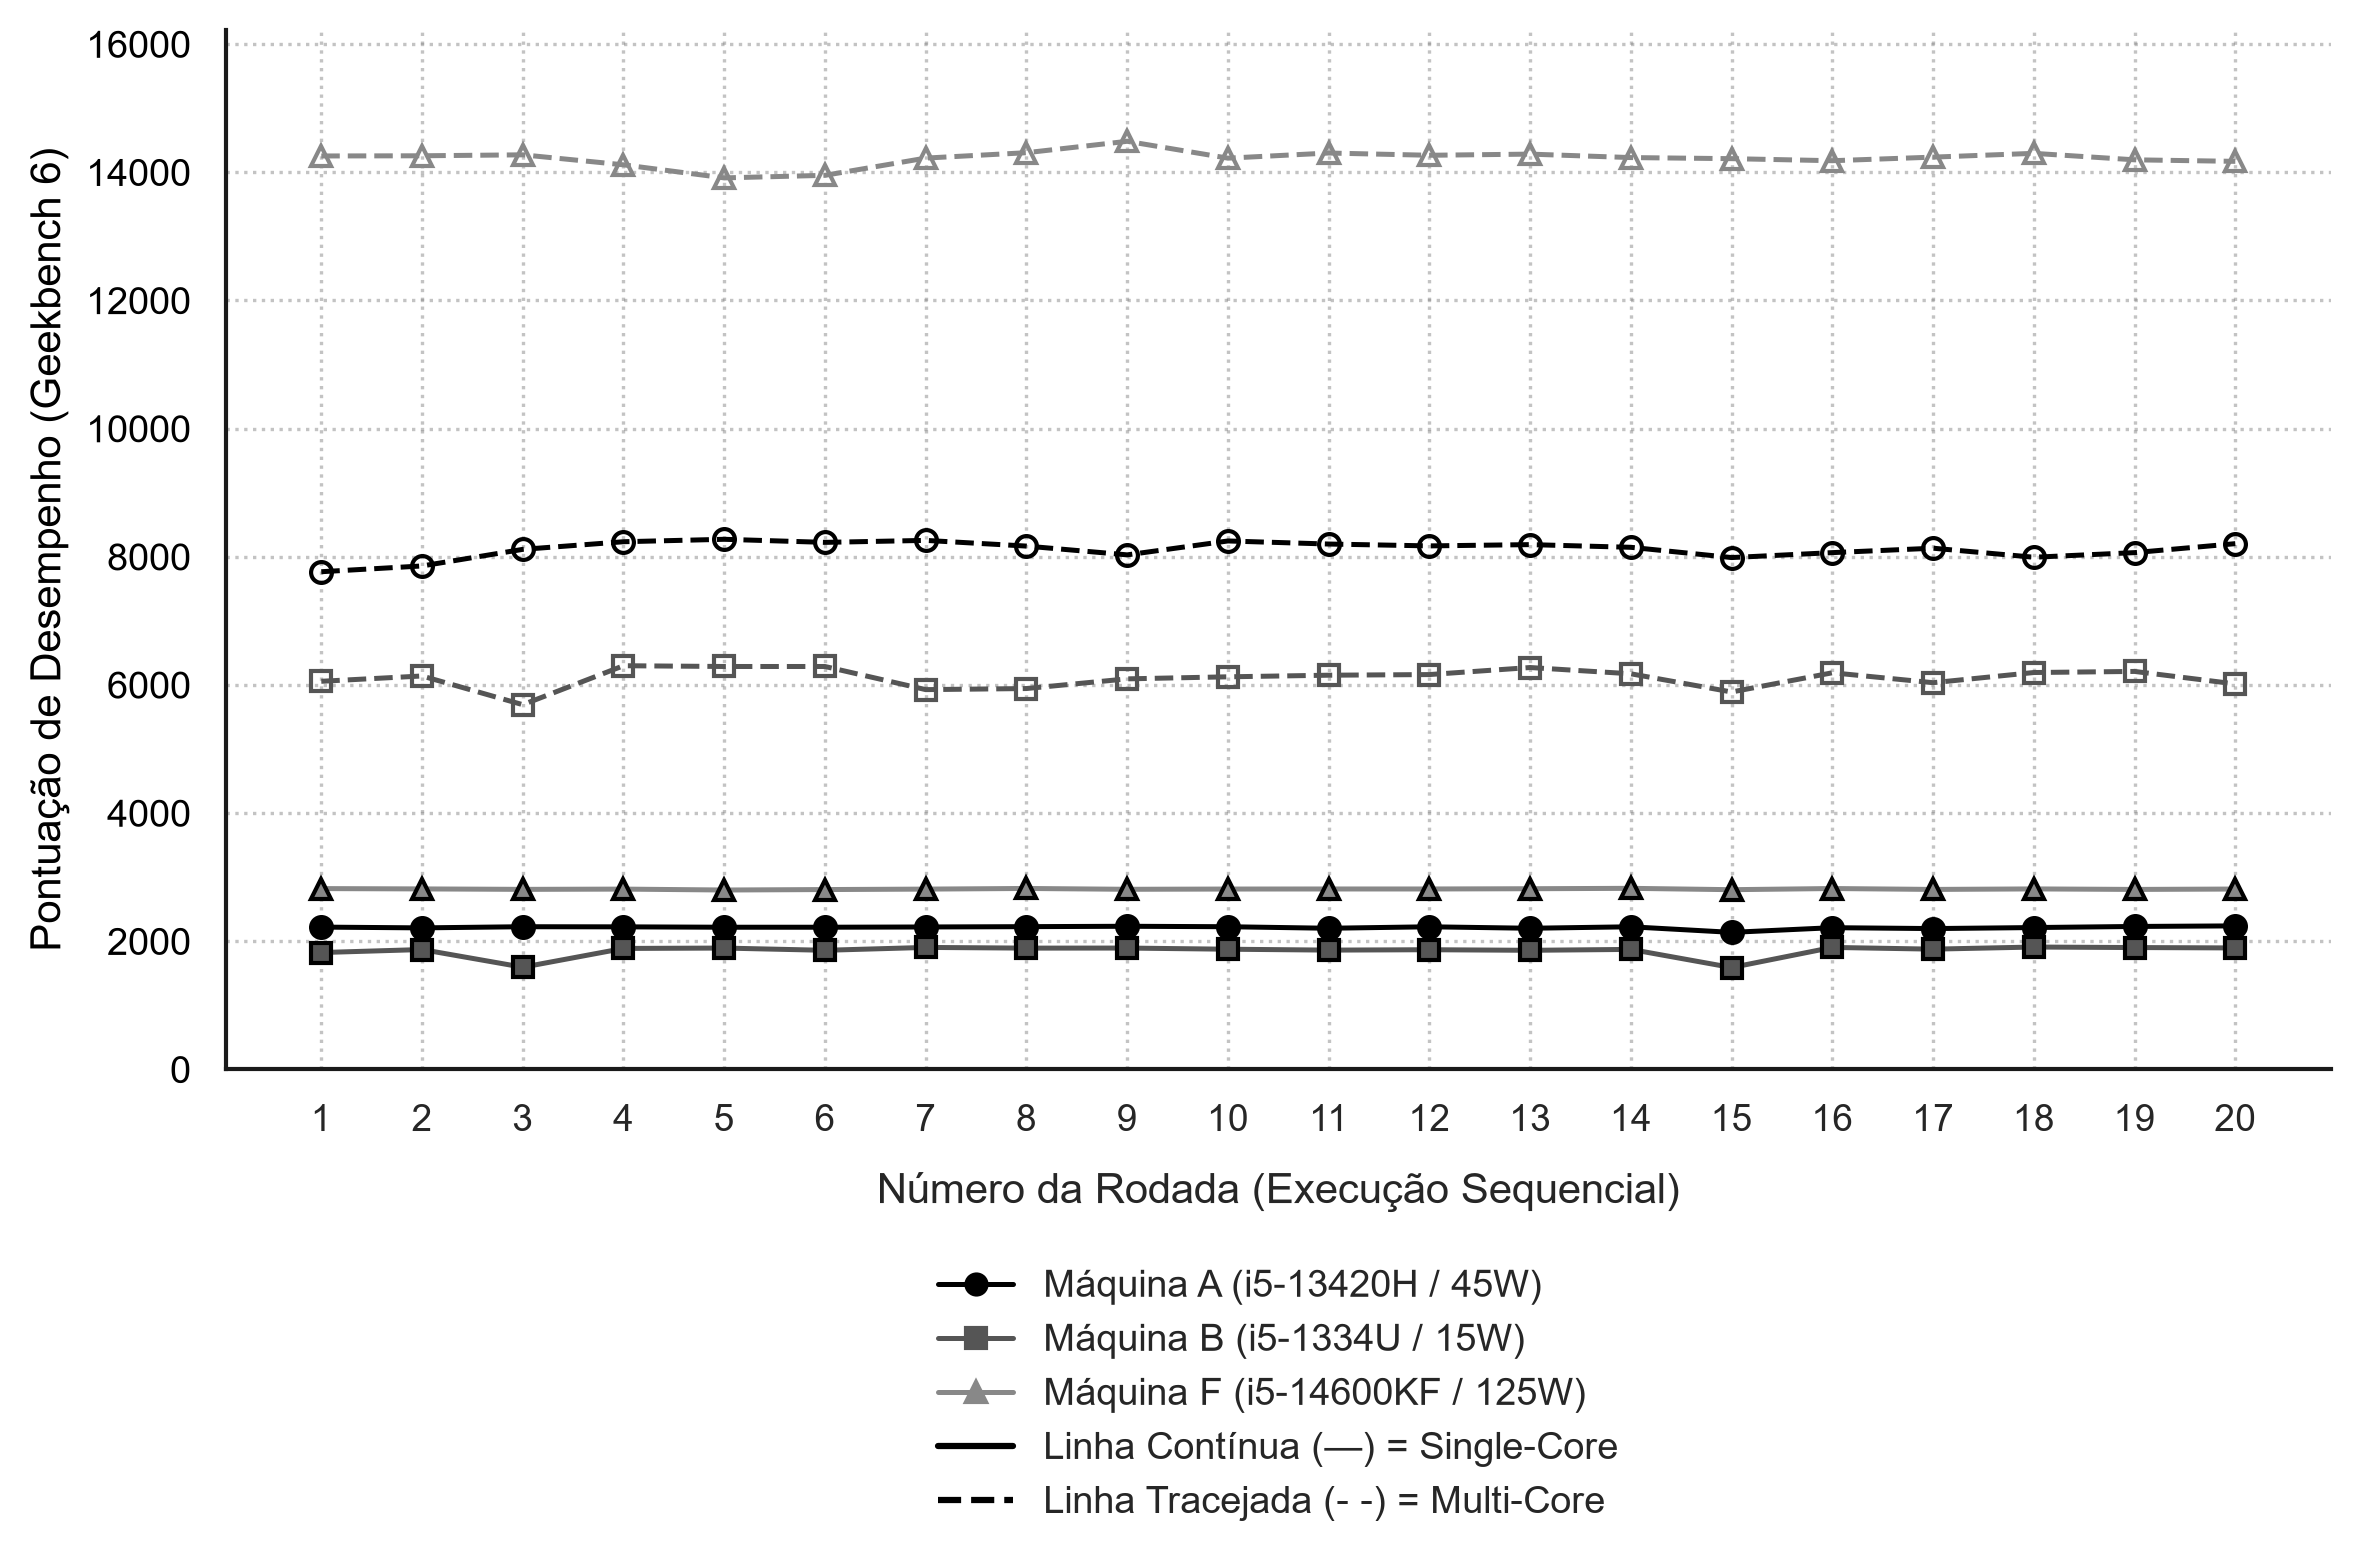


🚀 Sucesso! Gráfico em escala unificada gerado e salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\grafico_linhas_evolucao_rodadas_single_multi_escala_unificada.png


In [101]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: MÁQUINAS NO MESMO GRÁFICO (EIXO Y ÚNICO UNIFICADO)
# =====================================================================
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

# Identificadores visuais distintos por máquina para escala de cinza (SBC)
config_maquinas = {
    "machine_a": {"cor": "#000000", "marker": "o", "label": "Máquina A (i5-13420H / 45W)"},
    "machine_b": {"cor": "#555555", "marker": "s", "label": "Máquina B (i5-1334U / 15W)"},
    "machine_f": {"cor": "#888888", "marker": "^", "label": "Máquina F (i5-14600KF / 125W)"}
}

# 🎯 MODIFICAÇÃO: Criamos apenas um eixo Y para unificar as escalas na do maior
fig, ax = plt.subplots(figsize=(8.0, 5.5), dpi=300)

print("📂 Processando rodadas em escala única unificada...")

# =====================================================================
# 2. LEITURA E JUXTAPOSIÇÃO DAS SÉRIES TEMPORAIS
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    if not pasta_origem.is_dir() or nome_pasta not in config_maquinas:
        continue
        
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    if arquivos_txt:
        caminho_txt = arquivos_txt[0]
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        df_scores_txt['Single_Core'] = pd.to_numeric(df_scores_txt['Single_Core'], errors='coerce')
        df_scores_txt['Multi_Core'] = pd.to_numeric(df_scores_txt['Multi_Core'], errors='coerce')
        
        rodadas = list(range(1, len(df_scores_txt) + 1))
        cfg = config_maquinas[nome_pasta]
        
        # 📉 1. Plota Single-Core (Mesmo Eixo - Linha Contínua)
        ax.plot(
            rodadas, 
            df_scores_txt['Single_Core'], 
            linestyle="-", 
            linewidth=1.2, 
            marker=cfg["marker"], 
            markersize=5,
            color=cfg["cor"], 
            markeredgecolor="#000000"
        )
        
        # 📈 2. Plota Multi-Core (Mesmo Eixo - Linha Tracejada)
        ax.plot(
            rodadas, 
            df_scores_txt['Multi_Core'], 
            linestyle="--", 
            linewidth=1.2, 
            marker=cfg["marker"], 
            markersize=5,
            color=cfg["cor"], 
            markerfacecolor="none", 
            markeredgecolor=cfg["cor"]
        )

# =====================================================================
# 3. ACABAMENTO E DESIGN CIENTÍFICO ANTI-POLUIÇÃO (SBC)
# =====================================================================
# Configuração do Eixo X comum
ax.set_xlabel("Número da Rodada (Execução Sequencial)", fontsize=10, labelpad=8)
ax.set_xticks(range(1, 21))

# 🎯 MODIFICAÇÃO: Eixo Y Único com o título ajustado para refletir a escala de ambas as métricas
ax.set_ylabel("Pontuação de Desempenho (Geekbench 6)", fontsize=10, color="#000000")
ax.tick_params(axis='y', labelcolor="#000000", labelsize=9)
ax.grid(axis="both", linestyle=":", alpha=0.5, color="#888888")

# 🎯 MONTAGEM MANUAL DA LEGENDA UNIFICADA CENTRAL INFERIOR
linhas_legenda = []
labels_legenda = []

# Adiciona as referências das máquinas
for m in MAQUINAS_PARAMETRO:
    if m in config_maquinas:
        linhas_legenda.append(plt.Line2D(xdata=[], ydata=[], color=config_maquinas[m]["cor"], marker=config_maquinas[m]["marker"], linestyle="-"))
        labels_legenda.append(config_maquinas[m]["label"])

# Adiciona as referências técnicas de interpretação de linha
linhas_legenda.append(plt.Line2D(xdata=[], ydata=[], color="#000000", linestyle="-", linewidth=1.5))
labels_legenda.append("Linha Contínua (—) = Single-Core")

linhas_legenda.append(plt.Line2D(xdata=[], ydata=[], color="#000000", linestyle="--", linewidth=1.5))
labels_legenda.append("Linha Tracejada (- -) = Multi-Core")

# Posicionamento da legenda expandida na base central inferior externa
ax.legend(
    linhas_legenda, labels_legenda,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.16), 
    ncol=1, 
    frameon=False,
    fontsize=9
)

# Moldura acadêmica limpa (SBC)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#1a1a1a')
ax.spines['bottom'].set_color('#1a1a1a')

# Garante uma folga aérea de 12% acima da maior pontuação de Multi-Core para o gráfico respirar
maior_valor_real = max(df_scores_txt['Multi_Core'].max() for m in MAQUINAS_PARAMETRO) if 'df_scores_txt' in locals() else 16000
ax.set_ylim(0, maior_valor_real * 1.12)

plt.tight_layout()
fig.subplots_adjust(bottom=0.34) # Mantém a folga para a legenda descritiva

# Salva a imagem final consolidada
caminho_saida_unificado = PASTA_PROCESSED / "grafico_linhas_evolucao_rodadas_single_multi_escala_unificada.png"
plt.savefig(caminho_saida_unificado, bbox_inches='tight', dpi=300)
plt.show()

print(f"\n🚀 Sucesso! Gráfico em escala unificada gerado e salvo em:\n   📍 {caminho_saida_unificado}")


In [102]:
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: MÁQUINAS QUE ENTRARÃO NA TABELA DE BENCHMARK
# =====================================================================
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

# Mapeamento oficial dos processadores reais da sua tabela técnica
NOMES_EXIBICAO = {
    "machine_a": "Máquina A (i5-13420H / 45W)",
    "machine_b": "Máquina B (i5-1334U / 15W)",
    "machine_f": "Máquina F (i5-14600KF / 125W)"
}

linhas_tabela_resumo = []

print("📂 Processando os arquivos de texto para extração estatística...")

# =====================================================================
# 2. LEITURA E CÁLCULO ESTATÍSTICO REAL DAS 20 RODADAS
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    
    if not pasta_origem.is_dir():
        print(f"⚠️ Pasta não encontrada: {nome_pasta}. Pulando...")
        continue
        
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    if arquivos_txt:
        # 🎯 CORREÇÃO: Extrai explicitamente o primeiro arquivo da lista usando [0]
        caminho_txt = arquivos_txt[0]
        
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        # Garante tipos de dados corretos
        df_scores_txt['Single_Core'] = pd.to_numeric(df_scores_txt['Single_Core'], errors='coerce')
        df_scores_txt['Multi_Core'] = pd.to_numeric(df_scores_txt['Multi_Core'], errors='coerce')
        
        # Extrai os dados limpando eventuais falhas de leitura
        sc_dados = df_scores_txt['Single_Core'].dropna()
        mc_dados = df_scores_txt['Multi_Core'].dropna()
        
        nome_formatado = NOMES_EXIBICAO.get(nome_pasta, nome_pasta.upper())
        
        # Estrutura a linha combinando as métricas solicitadas
        linhas_tabela_resumo.append({
            "Arquitetura Avaliada": nome_formatado,
            "Média Single-Core": sc_dados.mean(),
            "Desvio Padrão Single-Core": sc_dados.std(),
            "Mediana Single-Core": sc_dados.median(),
            "Média Multi-Core": mc_dados.mean(),
            "Desvio Padrão Multi-Core": mc_dados.std(),
            "Mediana Multi-Core": mc_dados.median()
        })
        print(f"   ✅ Estatísticas extraídas de: {caminho_txt.name}")
    else:
        print(f"   ❌ Nenhum arquivo 'scores_*.txt' encontrado dentro de {nome_pasta}.")

# Cria o DataFrame consolidado final
df_tabela_final = pd.DataFrame(linhas_tabela_resumo)

# =====================================================================
# 3. SALVAMENTO E EXPORTAÇÃO COMPATÍVEL COM O OVERLEAF (LATEX)
# =====================================================================
if not df_tabela_final.empty:
    # 📝 1. Salva a versão limpa em CSV na pasta processed (uma linha de cabeçalho)
    caminho_csv_tabela = PASTA_PROCESSED / "tabela_estatistica_benchmark_scores.csv"
    df_tabela_final.to_csv(caminho_csv_tabela, index=False, encoding='utf-8-sig')
    
    # Exibe na tela do Jupyter formatado com duas casas decimais
    print("\n📊 TABELA CIENTÍFICA CONSOLIDADA (Visão Geral):")
    display(df_tabela_final.round(2))
    print(f"💾 Arquivo CSV salvo em:\n   📍 {caminho_csv_tabela}\n")
    
    # 📝 2. Gera automaticamente o código LaTeX estruturado de acordo com o padrão SBC
    codigo_latex = "\\begin{table}[htbp]\n\\centering\n"
    codigo_latex += "\\caption{Métricas Estatísticas Consolidadas de Desempenho Computacional (Single-Core e Multi-Core) Computadas ao Longo de 20 Rodadas.}\n"
    codigo_latex += "\\label{tab:estatistica_benchmark}\n"
    codigo_latex += "\\small\n"
    codigo_latex += "\\begin{tabular}{lcccccc}\n"
    codigo_latex += "\\hline\n"
    codigo_latex += " & \\multicolumn{3}{c}{\\textbf{Single-Core Score}} & \\multicolumn{3}{c}{\\textbf{Multi-Core Score}} \\\\\n"
    codigo_latex += "\\textbf{Arquitetura Avaliada} & Média & Desv. Padrão & Mediana & Média & Desv. Padrão & Mediana \\\\\n"
    codigo_latex += "\\hline\n"
    
    for _, row in df_tabela_final.iterrows():
        codigo_latex += f"{row['Arquitetura Avaliada']} & {row['Média Single-Core']:.2f} & {row['Desvio Padrão Single-Core']:.2f} & {row['Mediana Single-Core']:.2f} & {row['Média Multi-Core']:.2f} & {row['Desvio Padrão Multi-Core']:.2f} & {row['Mediana Multi-Core']:.2f} \\\\\n"
        
    codigo_latex += "\\hline\n\\end{tabular}\n\\end{table}"
    
    # Salva o arquivo de texto com a tabela LaTeX prontas para importar no Overleaf
    caminho_latex_tabela = PASTA_PROCESSED / "tabela_latex_sbc_benchmark.tex"
    with open(caminho_latex_tabela, "w", encoding="utf-8") as f:
        f.write(codigo_latex)
        
    print("────────────────────────────────────────────────────────────────────────────────")
    print("📜 CÓDIGO LATEX PRONTO PARA O SEU MAIN.TEX (Copie as linhas abaixo):")
    print("────────────────────────────────────────────────────────────────────────────────")
    print(codigo_latex)
    print("────────────────────────────────────────────────────────────────────────────────")
    print(f"💾 Arquivo .tex também guardado em:\n   📍 {caminho_latex_tabela}")
else:
    print("❌ Erro ao processar os dados. Verifique a presença dos arquivos de score.")


📂 Processando os arquivos de texto para extração estatística...
   ✅ Estatísticas extraídas de: scores_maqA.txt
   ✅ Estatísticas extraídas de: scores_maqB.txt
   ✅ Estatísticas extraídas de: scores_maqF.txt

📊 TABELA CIENTÍFICA CONSOLIDADA (Visão Geral):


,Arquitetura Avaliada,Média Single-Core,Desvio Padrão Single-Core,Mediana Single-Core,Média Multi-Core,Desvio Padrão Multi-Core,Mediana Multi-Core
0,Máquina A (i5-13420H / 45W),2216.20,21.20,2222.0,8116.5,135.26,8157.5
1,Máquina B (i5-1334U / 15W),1851.95,91.09,1876.5,6107.7,155.71,6146.0
2,Máquina F (i5-14600KF / 125W),2814.50,6.68,2815.0,14218.8,121.88,14233.5


💾 Arquivo CSV salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\tabela_estatistica_benchmark_scores.csv

────────────────────────────────────────────────────────────────────────────────
📜 CÓDIGO LATEX PRONTO PARA O SEU MAIN.TEX (Copie as linhas abaixo):
────────────────────────────────────────────────────────────────────────────────
\begin{table}[htbp]
\centering
\caption{Métricas Estatísticas Consolidadas de Desempenho Computacional (Single-Core e Multi-Core) Computadas ao Longo de 20 Rodadas.}
\label{tab:estatistica_benchmark}
\small
\begin{tabular}{lcccccc}
\hline
 & \multicolumn{3}{c}{\textbf{Single-Core Score}} & \multicolumn{3}{c}{\textbf{Multi-Core Score}} \\
\textbf{Arquitetura Avaliada} & Média & Desv. Padrão & Mediana & Média & Desv. Padrão & Mediana \\
\hline
Máquina A (i5-13420H / 45W) & 2216.20 & 21.20 & 2222.00 & 8116.50 & 135.26 & 8157.50 \\
Máquina B (i5-1334U / 15W) & 1851.95 & 91.09 & 1876.50 & 6107.7

In [103]:
import numpy as np
import pandas as pd
from pathlib import Path

# =====================================================================
# 1. PARAMETRIZAÇÃO: MÁQUINAS QUE ENTRARÃO NA TABELA DE BENCHMARK
# =====================================================================
MAQUINAS_PARAMETRO = ["machine_a", "machine_b", "machine_f"]

PASTA_RAW = RAIZ_PROJETO / "data" / "raw"
PASTA_PROCESSED = RAIZ_PROJETO / "data" / "processed"

NOMES_EXIBICAO = {
    "machine_a": "Máquina A (i5-13420H / 45W)",
    "machine_b": "Máquina B (i5-1334U / 15W)",
    "machine_f": "Máquina F (i5-14600KF / 125W)"
}

linhas_tabela_cientifica = []

print("📂 Processando e compactando métricas sob notação científica...")

# =====================================================================
# 2. EXTRAÇÃO E FORMATAÇÃO DE CÉLULAS COMBINADAS (MEDIA ± DESVIO)
# =====================================================================
for nome_pasta in MAQUINAS_PARAMETRO:
    pasta_origem = PASTA_RAW / nome_pasta
    if not pasta_origem.is_dir():
        print(f"⚠️ Pasta não encontrada: {nome_pasta}. Pulando...")
        continue
        
    arquivos_txt = list(pasta_origem.glob("scores_*.txt"))
    if arquivos_txt:
        # 🎯 FIX DEFINITIVO: Extrai o arquivo string real da lista usando o índice [0]
        caminho_txt = arquivos_txt[0]
        
        df_scores_txt = pd.read_csv(caminho_txt, sep=';', encoding='utf-8')
        
        df_scores_txt['Single_Core'] = pd.to_numeric(df_scores_txt['Single_Core'], errors='coerce')
        df_scores_txt['Multi_Core'] = pd.to_numeric(df_scores_txt['Multi_Core'], errors='coerce')
        
        sc_dados = df_scores_txt['Single_Core'].dropna()
        mc_dados = df_scores_txt['Multi_Core'].dropna()
        
        nome_formatado = NOMES_EXIBICAO.get(nome_pasta, nome_pasta.upper())
        
        # Converte médias e desvios em strings unificadas com símbolo de incerteza (±)
        sc_combinado = f"{sc_dados.mean():.1f} ± {sc_dados.std():.1f}"
        mc_combinado = f"{mc_dados.mean():.1f} ± {mc_dados.std():.1f}"
        
        linhas_tabela_cientifica.append({
            "Arquitetura Avaliada": nome_formatado,
            "Single-Core (Média ± DP)": sc_combinado,
            "Single-Core (Mediana)": f"{sc_dados.median():.1f}",
            "Multi-Core (Média ± DP)": mc_combinado,
            "Multi-Core (Mediana)": f"{mc_dados.median():.1f}"
        })
        print(f"   ✅ Estatísticas extraídas de: {caminho_txt.name}")
    else:
        print(f"   ❌ Nenhum arquivo 'scores_*.txt' encontrado dentro de {nome_pasta}.")

df_tabela_premium = pd.DataFrame(linhas_tabela_cientifica)

# =====================================================================
# 3. EXPORTAÇÃO EXCLUSIVA E COMPILADOR DE MARCAÇÃO LATEX (SBC)
# =====================================================================
if not df_tabela_premium.empty:
    caminho_csv_premium = PASTA_PROCESSED / "tabela_estatistica_benchmark_scores_premium.csv"
    df_tabela_premium.to_csv(caminho_csv_premium, index=False, encoding='utf-8-sig')
    
    print("\n📊 TABELA NO PADRÃO DE PUBLICAÇÃO CIENTÍFICA (4 Colunas Métricas):")
    display(df_tabela_premium)
    print(f"💾 Arquivo CSV compacto salvo em:\n   📍 {caminho_csv_premium}\n")
    
    codigo_latex = "\\begin{table}[htbp]\n\\centering\n"
    codigo_latex += "\\caption{Análise Estatística Experimental Consolidada dos Scores de Benchmark ao Longo de 20 Rodadas Sequenciais.}\n"
    codigo_latex += "\\label{tab:estatistica_benchmark_premium}\n"
    codigo_latex += "\\small\n"
    codigo_latex += "\\begin{tabular}{lcccc}\n"
    codigo_latex += "\\hline\n"
    codigo_latex += " & \\multicolumn{2}{c}{\\textbf{Single-Core Score}} & \\multicolumn{2}{c}{\\textbf{Multi-Core Score}} \\\\\n"
    codigo_latex += "\\cmidrule(lr){2-3} \\cmidrule(lr){4-5}\n"
    codigo_latex += "\\textbf{Arquitetura Avaliada} & Média $\\pm$ Desv. Padrão & Mediana & Média $\\pm$ Desv. Padrão & Mediana \\\\\n"
    codigo_latex += "\\hline\n"
    
    for _, row in df_tabela_premium.iterrows():
        sc_m_dp = row['Single-Core (Média ± DP)'].replace('±', '$\\pm$')
        mc_m_dp = row['Multi-Core (Média ± DP)'].replace('±', '$\\pm$')
        
        codigo_latex += f"{row['Arquitetura Avaliada']} & {sc_m_dp} & {row['Single-Core (Mediana)']} & {mc_m_dp} & {row['Multi-Core (Mediana)']} \\\\\n"
        
    codigo_latex += "\\hline\n\\end{tabular}\n\\end{table}"
    
    caminho_latex_premium = PASTA_PROCESSED / "tabela_latex_sbc_benchmark_premium.tex"
    with open(caminho_latex_premium, "w", encoding="utf-8") as f:
        f.write(codigo_latex)
        
    print("────────────────────────────────────────────────────────────────────────────────")
    print("📜 CÓDIGO LATEX REESTRUTURADO (Pronto para colar no Overleaf):")
    print("────────────────────────────────────────────────────────────────────────────────")
    print(codigo_latex)
    print("────────────────────────────────────────────────────────────────────────────────")
    print(f"💾 Arquivo .tex científico salvo em:\n   📍 {caminho_latex_premium}")
else:
    print("❌ Erro ao processar os dados. Verifique a presença dos arquivos de score.")


📂 Processando e compactando métricas sob notação científica...
   ✅ Estatísticas extraídas de: scores_maqA.txt
   ✅ Estatísticas extraídas de: scores_maqB.txt
   ✅ Estatísticas extraídas de: scores_maqF.txt

📊 TABELA NO PADRÃO DE PUBLICAÇÃO CIENTÍFICA (4 Colunas Métricas):


,Arquitetura Avaliada,Single-Core (Média ± DP),Single-Core (Mediana),Multi-Core (Média ± DP),Multi-Core (Mediana)
0,Máquina A (i5-13420H / 45W),2216.2 ± 21.2,2222.0,8116.5 ± 135.3,8157.5
1,Máquina B (i5-1334U / 15W),1852.0 ± 91.1,1876.5,6107.7 ± 155.7,6146.0
2,Máquina F (i5-14600KF / 125W),2814.5 ± 6.7,2815.0,14218.8 ± 121.9,14233.5


💾 Arquivo CSV compacto salvo em:
   📍 c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\tabela_estatistica_benchmark_scores_premium.csv

────────────────────────────────────────────────────────────────────────────────
📜 CÓDIGO LATEX REESTRUTURADO (Pronto para colar no Overleaf):
────────────────────────────────────────────────────────────────────────────────
\begin{table}[htbp]
\centering
\caption{Análise Estatística Experimental Consolidada dos Scores de Benchmark ao Longo de 20 Rodadas Sequenciais.}
\label{tab:estatistica_benchmark_premium}
\small
\begin{tabular}{lcccc}
\hline
 & \multicolumn{2}{c}{\textbf{Single-Core Score}} & \multicolumn{2}{c}{\textbf{Multi-Core Score}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
\textbf{Arquitetura Avaliada} & Média $\pm$ Desv. Padrão & Mediana & Média $\pm$ Desv. Padrão & Mediana \\
\hline
Máquina A (i5-13420H / 45W) & 2216.2 $\pm$ 21.2 & 2222.0 & 8116.5 $\pm$ 135.3 & 8157.5 \\
Máquina B (i5-1334

# Testes

In [104]:
import pandas as pd

caminho_arquivo = "data\\raw\\machine_a\\maqA_rodada_01.CSV"

# CORREÇÃO: UTF-8 limpa os acentos e errors="replace" impede o travamento na linha com erro
df = pd.read_csv(
    caminho_arquivo, 
    encoding="utf-8", 
    on_bad_lines='skip', 
    encoding_errors='replace',
)

# Exibe o cabeçalho corrigido para testar
print([col for col in df.columns if "Utilização" in col])


['Utilização do arquivo de paginação [%]', 'Utilização do núcleo (avg) [%]', 'P-core 0 T0 Utilização [%]', 'P-core 0 T1 Utilização [%]', 'P-core 1 T0 Utilização [%]', 'P-core 1 T1 Utilização [%]', 'P-core 2 T0 Utilização [%]', 'P-core 2 T1 Utilização [%]', 'P-core 3 T0 Utilização [%]', 'P-core 3 T1 Utilização [%]', 'E-core 4 T0 Utilização [%]', 'E-core 5 T0 Utilização [%]', 'E-core 6 T0 Utilização [%]', 'E-core 7 T0 Utilização [%]', 'Utilização total da CPU [%]', 'Utilização de D3D GPU [%]', 'Utilização [Yes/No]']


In [105]:
# 2. Identifica quais colunas possuem 100% de valores nulos/vazios
colunas_vazias = df.columns[df.isna().all()].tolist()

# 3. Exibe o resultado no console
print(f"Total de colunas completamente vazias: {len(colunas_vazias)}")
print("Lista de colunas vazias:", colunas_vazias)


Total de colunas completamente vazias: 1
Lista de colunas vazias: ['Unnamed: 311']


In [106]:
# 2. Identifica as linhas onde TODAS as colunas são NaN
linhas_vazias_mask = df.isna().all(axis=1)

# 3. Extrai os números das linhas (índices) que estão vazias
indices_linhas_vazias = df.index[linhas_vazias_mask].tolist()

print(f"Total de linhas completamente vazias: {len(indices_linhas_vazias)}")
print("Índices das linhas vazias:", indices_linhas_vazias)


Total de linhas completamente vazias: 0
Índices das linhas vazias: []


In [107]:
# Remove apenas as linhas que estão 100% vazias
#df_limpo = df.dropna(how="all")

# Se quiser salvar o arquivo corrigido por cima do antigo:
# df_limpo.to_csv("caminho/do/seu/arquivo.csv", index=False)


In [108]:
import numpy as np
import pandas as pd

# 1. Filtra apenas colunas numéricas (telemetria quantitativa)
df_numerico = df.select_dtypes(include=[np.number]).copy()

colunas_relevantes = []
colunas_constantes = []
colunas_quase_vazias = []

# Critério de corte acadêmico
LIMITE_PERDA_DADOS = 10.0  # Máximo de 10% de NaNs permitidos
LIMITE_VARIABILIDADE = 0.01  # Coeficiente de variação mínimo (1%)

for col in df_numerico.columns:
    serie = df_numerico[col].dropna()

    # 1. Filtra colunas com muita perda de dados (sensores que falharam)
    pct_nulos = (df_numerico[col].isna().sum() / len(df)) * 100
    if pct_nulos > LIMITE_PERDA_DADOS:
        colunas_quase_vazias.append(col)
        continue

    # 2. Filtra colunas constantes (sensores que não mudaram nada no teste)
    media = serie.mean()
    desvio = serie.std()

    if media == 0 or pd.isna(desvio) or desvio == 0:
        colunas_constantes.append(col)
        continue

    # Coeficiente de variação (Desvio Padrão / Média)
    cv = desvio / abs(media)

    if cv < LIMITE_VARIABILIDADE:
        colunas_constantes.append(col)
    else:
        colunas_relevantes.append(
            {"Coluna": col, "Média": media, "Desvio": desvio, "CV (%)": round(cv * 100, 2)}
        )

# Converte o resultado em um DataFrame estruturado
df_relevancia = pd.DataFrame(colunas_relevantes).sort_values(
    "CV (%)", ascending=False
)

print(f"--- Relatório de Relevância Científica ({Path(caminho_arquivo).name}) ---")
print(f"✅ Colunas Relevantes detectadas (Variam no teste): {len(df_relevancia)}")
print(f"❌ Colunas Inúteis/Constantes (Não variam): {len(colunas_constantes)}")
print(f"❌ Colunas Descartadas (Muitos NaNs): {len(colunas_quase_vazias)}\n")

print("🔝 Top 10 Colunas mais dinâmicas (Maior impacto visual em gráficos):")
display(df_relevancia.head(10))


--- Relatório de Relevância Científica (maqA_rodada_01.CSV) ---
✅ Colunas Relevantes detectadas (Variam no teste): 162
❌ Colunas Inúteis/Constantes (Não variam): 68
❌ Colunas Descartadas (Muitos NaNs): 1

🔝 Top 10 Colunas mais dinâmicas (Maior impacto visual em gráficos):


,Coluna,Média,Desvio,CV (%)
112,P-core 1 T1 C0 Ocupação [%],0.070588,0.266375,377.37
54,P-core 1 T1 Utilização [%],0.135294,0.482106,356.34
25,P-core 1 T1 Relógio efetivo [MHz],3.411765,11.830674,346.76
52,P-core 0 T1 Utilização [%],0.147059,0.458418,311.72
23,P-core 0 T1 Relógio efetivo [MHz],3.852941,11.512445,298.80
29,P-core 3 T1 Relógio efetivo [MHz],54.370588,160.329223,294.88
127,E-core 5 C1 Ocupação [%],0.952941,2.764534,290.11
110,P-core 0 T1 C0 Ocupação [%],0.100000,0.269258,269.26
116,P-core 3 T1 C0 Ocupação [%],1.470588,3.918987,266.49
133,P-core 2 C6 Ocupação [%],0.241176,0.626557,259.79


In [109]:
import numpy as np
import pandas as pd
from pathlib import Path

# 1. Definição de caminhos do projeto
DIRETORIO_RAW = RAIZ_PROJETO / "data" / "raw" / "machine_g"
DIRETORIO_PROCESSED = RAIZ_PROJETO / "data" / "processed" / "machine_g"

# Garante a criação física da pasta de destino em inglês antes de salvar
DIRETORIO_PROCESSED.mkdir(parents=True, exist_ok=True)

# Parâmetros matemáticos de relevância científica
LIMITE_PERDA_DADOS = 10.0    # Descarta colunas com mais de 10% de NaNs
LIMITE_VARIABILIDADE = 0.01  # Coeficiente de variação mínimo (1%)

print(f"--- Iniciando Processamento em Lote Corrigido: Máquina G ---")
print(f"Destino: {DIRETORIO_PROCESSED}\n")

# 2. Loop para processar as 20 rodadas
for r in range(1, 22):
    nome_arquivo = f"maqG_rodada_{r:02d}.CSV"
    caminho_entrada = DIRETORIO_RAW / nome_arquivo
    
    if not caminho_entrada.is_file():
        print(f"⚠️ Arquivo ausente: {nome_arquivo} (Pulado)")
        continue
        
    # CORREÇÃO: Adicionado decimal="," para forçar a conversão correta de decimais brasileiros (vírgula)
    df_bruto = pd.read_csv(
        caminho_entrada, 
        encoding="utf-8", 
        on_bad_lines='skip', 
        encoding_errors='replace',
        decimal=","
    )
    
    # Isola o timestamp temporal nativo para mantê-lo obrigatoriamente na tabela tratada
    colunas_preservadas = []
    for col_tempo in ["Time", "Date", "Hora"]:
        if col_tempo in df_bruto.columns:
            colunas_preservadas.append(col_tempo)
            
    # Agora o select_dtypes vai capturar TODOS os sensores corretamente como números
    df_numerico = df_bruto.select_dtypes(include=[np.number]).copy()
    colunas_relevantes_rodada = []
    
    # 3. Algoritmo de filtragem de dados por relevância
    for col in df_numerico.columns:
        if col in colunas_preservadas:
            continue
            
        serie = df_numerico[col].dropna()
        
        # Filtro A: Integridade das amostras
        pct_nulos = (df_numerico[col].isna().sum() / len(df_bruto)) * 100
        if pct_nulos > LIMITE_PERDA_DADOS:
            continue
            
        media = serie.mean()
        desvio = serie.std()
        
        # Filtro B: Exclusão de sensores fixos/constantes
        if media == 0 or pd.isna(desvio) or desvio == 0:
            continue
            
        # Filtro C: Coeficiente de variação (Variação real)
        cv = desvio / abs(media)
        if cv >= LIMITE_VARIABILIDADE:
            colunas_relevantes_rodada.append(col)
            
    # Une as colunas temporais com as colunas numéricas que passaram na triagem
    colunas_finais = colunas_preservadas + colunas_relevantes_rodada
    df_filtrado = df_bruto[colunas_finais].copy()
    
    # 4. Exportação dos arquivos higienizados
    caminho_saida = DIRETORIO_PROCESSED / nome_arquivo
    df_filtrado.to_csv(caminho_saida, index=False, encoding="utf-8")
    
    print(f"✅ Rodada {r:02d}: Reduzida de {df_bruto.shape} para {df_filtrado.shape} colunas relevantes -> Salva.")

print(f"\n🚀 Processamento concluído com sucesso nas 20 rodadas.")


--- Iniciando Processamento em Lote Corrigido: Máquina G ---
Destino: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\machine_g

⚠️ Arquivo ausente: maqG_rodada_01.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_02.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_03.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_04.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_05.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_06.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_07.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_08.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_09.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_10.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_11.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_12.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_13.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_14.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_15.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_16.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_17.CSV (Pulado)


In [110]:
import numpy as np
import pandas as pd
from pathlib import Path

# 1. Definição de caminhos do projeto
DIRETORIO_RAW = RAIZ_PROJETO / "data" / "raw" / "machine_g"
DIRETORIO_PROCESSED = RAIZ_PROJETO / "data" / "processed" / "machine_g"

DIRETORIO_PROCESSED.mkdir(parents=True, exist_ok=True)

LIMITE_PERDA_DADOS = 10.0    
LIMITE_VARIABILIDADE = 0.01  

print(f"--- Iniciando Processamento Adaptativo: Máquina G ---")
print(f"Destino: {DIRETORIO_PROCESSED}\n")

for r in range(1, 22):
    nome_arquivo = f"maqG_rodada_{r:02d}.CSV"
    caminho_entrada = DIRETORIO_RAW / nome_arquivo
    
    if not caminho_entrada.is_file():
        print(f"⚠️ Arquivo ausente: {nome_arquivo} (Pulado)")
        continue
        
    # TENTATIVA 1: Tenta ler com o padrão de vírgula como separador
    df_bruto = pd.read_csv(
        caminho_entrada, 
        encoding="utf-8", 
        on_bad_lines='skip', 
        encoding_errors='replace',
        sep=",",
        decimal="."
    )
    
    # SEGUNDA VERIFICAÇÃO: Se o Pandas leu tudo como 1 única coluna, o arquivo usa ponto e vírgula (padrão BR)
    if df_bruto.shape[1] <= 2:
        df_bruto = pd.read_csv(
            caminho_entrada, 
            encoding="utf-8", 
            on_bad_lines='skip', 
            encoding_errors='replace',
            sep=";",
            decimal=","
        )
        
    # Isolamento de colunas temporais
    colunas_preservadas = []
    for col_tempo in ["Time", "Date", "Hora"]:
        # Varredura parcial para capturar colunas mesmo com espaços extras do HWInfo
        col_encontrada = [c for c in df_bruto.columns if col_tempo.lower() in c.lower()]
        if col_encontrada:
            colunas_preservadas.extend(col_encontrada)
            
    df_numerico = df_bruto.select_dtypes(include=[np.number]).copy()
    colunas_relevantes_rodada = []
    
    for col in df_numerico.columns:
        if col in colunas_preservadas:
            continue
            
        serie = df_numerico[col].dropna()
        pct_nulos = (df_numerico[col].isna().sum() / len(df_bruto)) * 100
        if pct_nulos > LIMITE_PERDA_DADOS:
            continue
            
        media = serie.mean()
        desvio = serie.std()
        
        if media == 0 or pd.isna(desvio) or desvio == 0:
            continue
            
        cv = desvio / abs(media)
        if cv >= LIMITE_VARIABILIDADE:
            colunas_relevantes_rodada.append(col)
            
    colunas_finais = list(set(colunas_preservadas + colunas_relevantes_rodada))
    df_filtrado = df_bruto[colunas_finais].copy()
    
    caminho_saida = DIRETORIO_PROCESSED / nome_arquivo
    df_filtrado.to_csv(caminho_saida, index=False, encoding="utf-8")
    
    print(f"✅ Rodada {r:02d}: Reduzida de {df_bruto.shape} para {df_filtrado.shape} colunas relevantes -> Salva.")

print(f"\n🚀 Processamento concluído com sucesso nas 20 rodadas.")


--- Iniciando Processamento Adaptativo: Máquina G ---
Destino: c:\Users\xapor\OneDrive\Documentos\Roberta\Projetos\GitHub\UFMS\aoc-empirical-benchmark\data\processed\machine_g

⚠️ Arquivo ausente: maqG_rodada_01.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_02.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_03.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_04.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_05.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_06.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_07.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_08.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_09.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_10.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_11.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_12.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_13.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_14.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_15.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_16.CSV (Pulado)
⚠️ Arquivo ausente: maqG_rodada_17.CSV (Pulado)
⚠️ Arqu

In [111]:
import numpy as np
import pandas as pd
from pathlib import Path

# 1. Definição de caminhos do projeto
DIRETORIO_RAW = RAIZ_PROJETO / "data" / "raw" / "machine_a"
DIRETORIO_PROCESSED = RAIZ_PROJETO / "data" / "processed" / "machine_a"
DIRETORIO_PROCESSED.mkdir(parents=True, exist_ok=True)

LIMITE_PERDA_DADOS = 10.0    
LIMITE_VARIABILIDADE = 0.01  

print(f"--- Iniciando Processamento Forçado (Fim do Bug das Rodadas Curtas) ---")
print(f"Destino: {DIRETORIO_PROCESSED}\n")

for r in range(1, 21):
    nome_arquivo = f"maqA_rodada_{r:02d}.CSV"
    caminho_entrada = DIRETORIO_RAW / nome_arquivo
    
    if not caminho_entrada.is_file():
        print(f"⚠️ Arquivo ausente: {nome_arquivo} (Pulado)")
        continue
        
    # Carrega mantendo o separador por vírgula nativo detectado
    df_bruto = pd.read_csv(
        caminho_entrada, 
        encoding="utf-8", 
        on_bad_lines='skip', 
        encoding_errors='replace',
        sep=","
    )
    
    # Isola colunas temporais
    colunas_preservadas = []
    for col_tempo in ["Time", "Date", "Hora"]:
        col_encontrada = [c for c in df_bruto.columns if col_tempo.lower() in c.lower()]
        if col_encontrada:
            colunas_preservadas.extend(col_encontrada)

    # CORREÇÃO CRÍTICA: Se a rodada tiver a assinatura estrutural problemática (388/389 colunas),
    # nós limpamos as strings trocando eventuais vírgulas remanescentes e forçando o tipo float.
    if df_bruto.shape[1] in:
        for col in df_bruto.columns:
            if col not in colunas_preservadas:
                # Transforma para string, limpa espaços, converte vírgula para ponto e força float
                df_bruto[col] = df_bruto[col].astype(str).str.replace(" ", "", regex=False)
                df_bruto[col] = pd.to_numeric(df_bruto[col].str.replace(",", ".", regex=False), errors='coerce')

    # Agora o select_dtypes funcionará perfeitamente em 100% das rodadas
    df_numerico = df_bruto.select_dtypes(include=[np.number]).copy()
    colunas_relevantes_rodada = []
    
    for col in df_numerico.columns:
        if col in colunas_preservadas:
            continue
            
        serie = df_numerico[col].dropna()
        pct_nulos = (df_numerico[col].isna().sum() / len(df_bruto)) * 100
        if pct_nulos > LIMITE_PERDA_DADOS:
            continue
            
        media = serie.mean()
        desvio = serie.std()
        
        if media == 0 or pd.isna(desvio) or desvio == 0:
            continue
            
        cv = desvio / abs(media)
        if cv >= LIMITE_VARIABILIDADE:
            colunas_relevantes_rodada.append(col)
            
    colunas_finais = list(set(colunas_preservadas + colunas_relevantes_rodada))
    df_filtrado = df_bruto[colunas_finais].copy()
    
    caminho_saida = DIRETORIO_PROCESSED / nome_arquivo
    df_filtrado.to_csv(caminho_saida, index=False, encoding="utf-8")
    
    print(f"✅ Rodada {r:02d}: Reduzida de {df_bruto.shape} para {df_filtrado.shape} colunas relevantes -> Salva.")

print(f"\n🚀 Processamento concluído. Todas as 20 rodadas possuem dados densos e estruturados.")



SyntaxError: invalid syntax (307365915.py, line 42)

## Etapa 2 — Análise dos resultados de Benchmark (Geekbench 6)

Calculamos, para cada máquina, a **média aritmética** e o **desvio padrão
amostral** dos scores *Single-Core* e *Multi-Core* ao longo das rodadas
disponíveis.

**Fórmulas utilizadas** (a transcrever no artigo, Seção de Metodologia):

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \qquad\qquad
s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$

O uso do desvio padrão **amostral** (denominador $n-1$, correção de Bessel)
é apropriado porque as 20 rodadas constituem uma **amostra** do
comportamento da máquina, não a população completa de execuções possíveis
(Hennessy e Patterson, 2018).


In [ ]:
resultado_benchmark = bench.consolidar_benchmark_todas_maquinas(
    relatorios, mapa_nomes_exibicao=NOMES_EXIBICAO
) if relatorios else {"tabelas_individuais": {}, "scores_brutos": {}, "comparativo": pd.DataFrame()}

print("--- Estatísticas individuais por máquina ---")
for nome_maquina, tabela in resultado_benchmark["tabelas_individuais"].items():
    print(f"\n{NOMES_EXIBICAO.get(nome_maquina, nome_maquina)} ({nome_maquina}):")
    display(tabela)


### 📊 Gráfico: Análise de Dispersão e Estabilidade Estatística (Boxplot)

**Objetivo:** Avaliar a consistência do ambiente de testes e a repetibilidade experimental do benchmark ao longo das 20 rodadas consecutivas de estresse.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Dispersão Reduzida (Boxes "achatados"):** Indica um ambiente experimental de alta fidelidade e isolamento estável. Prova que o sistema operacional mitigou ruídos de processos em segundo plano (*background noise*) e interrupções espúrias.</small>
* <small>**Dispersão Ampla ou Presença de *Outliers* Inferiores:** Sugere instabilidade no determinismo do hardware. Pontos isolados muito abaixo da mediana evidenciam gargalos momentâneos causados por picos térmicos ou contenção de recursos do sistema operacional.</small>
* <small>**Utilização no Artigo:** Este gráfico valida o rigor metodológico. Ele fundamenta estatisticamente a escolha da média amostral como métrica central representativa do desempenho bruto das microarquiteturas avaliadas.</small>



In [ ]:
# Exemplo de implementação usando os dados brutos de todas as rodadas
import matplotlib.pyplot as plt
import seaborn as sns

if resultado_benchmark["scores_brutos"]:
    # Converte o dicionário de scores brutos de volta para um DataFrame longo (tidy data)
    df_longo = pd.DataFrame([
        {"Máquina": NOMES_EXIBICAO.get(maq, maq), "Score": score, "Tipo": tipo}
        for maq, dados in resultado_benchmark["scores_brutos"].items()
        for tipo, lista_scores in dados.items()  # 'Single_Core' ou 'Multi_Core'
        for score in lista_scores
    ])
    
    # Filtra apenas o Multi-Core para o gráfico principal
    df_multi = df_longo[df_longo["Tipo"] == "Multi_Core"]
    
    plt.figure(figsize=(7, 4))
    # hue="Máquina" e legend=False elimina o aviso do Seaborn
    sns.boxplot(x="Máquina", y="Score", hue="Máquina", data=df_multi, palette="gist_gray", width=0.5, legend=False)
    plt.title("Variabilidade do Score Multi-Core ao Longo das Rodadas")
    plt.ylabel("Geekbench 6 Score")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(caminhos.resultados_figuras / "final_plots" / "fig_boxplot_variabilidade_multicore.png", dpi=300)
    plt.close() # plt.close() evita o UserWarning de canvas não-interativo

    print(f"Gráfico de Boxplot salvo em: {caminhos.resultados_figuras / 'final_plots' / 'fig_boxplot_variabilidade_multicore.png'}")
    


### 📊 Gráfico: Comparativo Sétrico de Desempenho: Single-Core vs. Multi-Core

**Objetivo:** Contrastar a capacidade bruta de processamento em cenários de execução estritamente sequencial (Single-Core) versus cenários de paralelismo massivo de threads (Multi-Core), utilizando intervalos de confiança baseados no desvio padrão amostral.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Fator de Escalabilidade (*Speedup*):** A razão entre o score Multi-Core e Single-Core quantifica a eficiência do paralelismo da arquitetura. Sistemas com núcleos híbridos (P-cores e E-cores) apresentarão dinâmicas de escalabilidade não-lineares se comparados a arquiteturas homogêneas.</small>
* <small>**Intervalos de Confiança (Barras de Erro `yerr`):** Barras de erro imperceptíveis demonstram que as médias são estatisticamente sólidas. Variações expressivas nos desvios padrão indicam assimetria na distribuição de carga entre os núcleos de execução.</small>
* <small>**Utilização no Artigo:** É a figura central da seção de **Resultados e Discussão**. Fornece o veredito empírico sobre o poder computacional bruto, respondendo quais inovações microarquiteturais (frequência de relógio, IPC ou densidade de núcleos) trouxeram maior ganho real.</small>


In [ ]:
df_comp = resultado_benchmark["comparativo"]
if not df_comp.empty:
    import numpy as np
    
    x = np.arange(len(df_comp["maquina"]))
    largura = 0.35
    
    fig, ax = plt.subplots(figsize=(7, 4))
    
    # Barra de Single-Core (Cinza Claro)
    ax.bar(x - largura/2, df_comp["Single_Core_media"], largura, 
           yerr=df_comp["Single_Core_desvio_padrao"], label='Single-Core',
           color='#cccccc', edgecolor='#1a1a1a', capsize=4)
    
    # Barra de Multi-Core (Cinza Escuro)
    ax.bar(x + largura/2, df_comp["Multi_Core_media"], largura, 
           yerr=df_comp["Multi_Core_desvio_padrao"], label='Multi-Core',
           color='#666666', edgecolor='#1a1a1a', capsize=4)
    
    ax.set_ylabel('Geekbench 6 Score')
    ax.set_title('Comparativo de Desempenho Computacional por Máquina')
    ax.set_xticks(x)
    ax.set_xticklabels(df_comp["maquina"])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(caminhos.resultados_figuras / "final_plots" / "fig_comparativo_desempenho_sbc.png", dpi=300)
    #plt.show()
    plt.close() # plt.close() evita o UserWarning de canvas não-interativo

    print(f"Gráfico de Comparativo de Desempenho salvo em: {caminhos.resultados_figuras / 'final_plots' / 'fig_comparativo_desempenho_sbc.png'}")

### 📊 Gráfico: Evolução Temporal Inter-Rodadas e Degradação de Performance

**Objetivo:** Mapear o comportamento dinâmico do hardware sob estresse térmico prolongado, monitorando a evolução do score ao longo das 20 iterações sequenciais.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Curva Descendente em Degraus (*Thermal Throttling*):** Máquinas com queda acentuada de rendimento após as primeiras rodadas comprovam a atuação dos mecanismos de proteção térmica (*prochot*). O processador reduz agressivamente o clock para evitar danos físicos, degradando o desempenho sustentado.</small>
* <small>**Curva Linear Horizontal (Estabilidade Térmica):** Evidencia um ecossistema microarquitetural equilibrado e um sistema de refrigeração ativo (dissipação/fans) capaz de sustentar o TDP (*Thermal Design Power*) máximo continuamente sem saturação térmica.</small>
* <small>**Utilização no Artigo:** Enquadra-se na seção de **Análise de Eficiência e Telemetria**. Este gráfico desmistifica o desempenho "de pico" (comumente reportado por fabricantes) e expõe a verdadeira capacidade de computação sustentada sob regime de carga pesada (*sustained workload*).</small>


In [ ]:
import matplotlib.pyplot as plt

if resultado_benchmark["scores_brutos"]:
    plt.figure(figsize=(7.5, 4.5))
    
    # Marcadores e estilos de linha distintos no padrão SBC para diferenciar as máquinas
    estilos_marcadores = ["o", "s", "^", "D", "v", "X"]
    estilos_linhas = ["-", "--", "-.", ":", "-", "--"]
    # Tons de cinza/preto para publicação científica
    cores_sbc = ["#000000", "#555555", "#888888", "#aaaaaa", "#333333", "#777777"]
    
    idx = 0
    for nome_maquina, dados in resultado_benchmark["scores_brutos"].items():
        # Extrai a lista de scores Multi-Core (geralmente possui 20 elementos ordenados)
        scores_multi = dados.get("Multi_Core", [])
        
        # Uso de .empty para avaliar objetos de dados do Pandas com segurança
        if hasattr(scores_multi, "empty"):
            if scores_multi.empty:
                continue
        elif not scores_multi:
            continue
            
        # Cria o eixo X dinamicamente com base no número de rodadas executadas (Ex: 1 a 20)
        rodadas = list(range(1, len(scores_multi) + 1))
        
        # Plota a linha da máquina com marcadores geométricos
        plt.plot(
            rodadas, 
            scores_multi, 
            label=NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
            marker=estilos_marcadores[idx % len(estilos_marcadores)],
            linestyle=estilos_linhas[idx % len(estilos_linhas)],
            color=cores_sbc[idx % len(cores_sbc)],
            linewidth=1.2,
            markersize=5,
            markeredgecolor="#000000"
        )
        idx += 1

    # Configurações de layout científico (SBC)
    plt.title("Evolução do Desempenho Multi-Core ao Longo do Teste de Estresse")
    plt.xlabel("Número da Rodada (Execução Sequencial)")
    plt.ylabel("Geekbench 6 Score")
    
    # Garante que o eixo X mostre apenas números inteiros das rodadas
    plt.xticks(range(1, 21)) 
    
    # Posiciona a legenda de forma limpa
    plt.legend(loc="lower left", frameon=True, edgecolor="#cccccc")
    plt.grid(axis="both", linestyle=":", alpha=0.6, color="#aaaaaa")
    
    plt.tight_layout()
    
    # Salva automaticamente na pasta correta de análise de dados brutos/intermediários
    caminho_figura_3 = caminhos.resultados_figuras / "raw_plots" / "fig_evolucao_rodadas_multicore.png"
    plt.savefig(caminho_figura_3, dpi=300)
    #plt.show()
    plt.close() # CORREÇÃO: Suprime o aviso de ambiente sem interface gráfica
    
    print(f"Gráfico de evolução temporal salvo em: {caminho_figura_3}")


In [ ]:
# Tabela comparativa (uma linha por máquina) — pronta para a Tabela do artigo SBC
tabela_comparativa_benchmark = resultado_benchmark["comparativo"]
display(tabela_comparativa_benchmark)

if not tabela_comparativa_benchmark.empty:
    caminho_saida = caminhos.resultados_tabelas / "benchmark_comparativo.csv"
    tabela_comparativa_benchmark.to_csv(caminho_saida, index=False, encoding="utf-8")
    print(f"Tabela comparativa salva em: {caminho_saida}")


### 📊 Gráfico Comparativo Geral — Desempenho Multi-Core vs. Single-Core por Máquina

**Objetivo:** Sintetizar os resultados consolidados do benchmark para confrontar diretamente o desempenho de computação sequencial e paralela de todas as microarquiteturas em um único plano visual.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Assimetria de Escalabilidade:** Máquinas de alto desempenho (Desktop/Servidor) devem apresentar barras Multi-Core massivamente superiores às de Single-Core. Laptops ou mini-PCs mostrarão uma razão menor devido a limitações de dissipação térmica (TDP restrito) que limitam o turbo de múltiplos núcleos simultâneos.</small>
* <small>**Sobreposição de Desvios (Barras de Erro):** Se as barras de erro de duas máquinas diferentes se sobrepuserem visualmente, significa que, estatisticamente, o desempenho delas é equivalente naquela métrica, mesmo que as médias numéricas sejam ligeiramente diferentes.</small>
* <small>**Utilização no Artigo:** É a figura principal de benchmark do artigo. Ela traduz visualmente a tabela `.csv` exportada, permitindo correlacionar os pilares de IPC (Instructions Per Cycle), contagem de núcleos físicos e frequências de operação discutidos no texto.</small>


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Só executa se o DataFrame comparativo tiver dados
if not tabela_comparativa_benchmark.empty:
    df_plot = tabela_comparativa_benchmark.copy()
    
    # Configurações de dimensões e posições das barras agrupadas
    posicoes = np.arange(len(df_plot["maquina"]))
    largura_barra = 0.35
    
    # Inicializa a figura no padrão SBC (proporção limpa para colunas de artigos)
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    # 1. Plota as barras de Single-Core (Cinza Claro) com o desvio padrão amostral
    barras_single = ax.bar(
        posicoes - largura_barra/2, 
        df_plot["Single_Core_media"], 
        largura_barra, 
        yerr=df_plot["Single_Core_desvio_padrao"], 
        label="Single-Core",
        color="#cccccc", 
        edgecolor="#1a1a1a", 
        linewidth=0.8,
        capsize=4,
        error_kw={"elinewidth": 1.0, "ecolor": "#1a1a1a"}
    )
    
    # 2. Plota as barras de Multi-Core (Cinza Escuro) com o desvio padrão amostral
    barras_multi = ax.bar(
        posicoes + largura_barra/2, 
        df_plot["Multi_Core_media"], 
        largura_barra, 
        yerr=df_plot["Multi_Core_desvio_padrao"], 
        label="Multi-Core",
        color="#666666", 
        edgecolor="#1a1a1a", 
        linewidth=0.8,
        capsize=4,
        error_kw={"elinewidth": 1.0, "ecolor": "#1a1a1a"}
    )
    
    # Elementos textuais científicos (Evite títulos internos se o artigo usar sublegendas \caption)
    ax.set_ylabel("Geekbench 6 Score (Pontuação)")
    ax.set_xlabel("Microarquitetura / Máquina Avaliada")
    ax.set_title("Comparativo Consolidado de Desempenho Computacional")
    
    # Ajusta os rótulos do Eixo X com os nomes reais das máquinas
    ax.set_xticks(posicoes)
    ax.set_xticklabels(df_plot["maquina"].tolist(), rotation=0)
    
    # Legenda e grade de fundo sutil
    ax.legend(loc="upper left", frameon=True, edgecolor="#cccccc")
    ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
    
    # Remove bordas desnecessárias (estilo clean)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Salva automaticamente na estrutura correta em inglês para plots finais
    caminho_grafico = caminhos.resultados_figuras / "final_plots" / "fig_comparativo_consolidado_benchmark.png"
    plt.savefig(caminho_grafico, dpi=300)
    plt.close()
    
    print(f"Gráfico comparativo consolidado salvo em: {caminho_grafico}")


## Etapa 3 — Análise da Telemetria de Hardware (HWiNFO64)

Cada rodada gerou um arquivo `.csv` com **múltiplas amostras no tempo**
(série temporal). Para cada rodada, calculamos métricas-resumo (média e
máximo) das colunas críticas definidas pelo grupo: clock de núcleo, uso de
CPU/GPU, temperatura, potência e indicadores de *throttling* térmico.

Essas 20 (ou menos) linhas-resumo por máquina são então consolidadas em
estatísticas **ao nível de máquina** (média e desvio padrão **entre
rodadas**), que alimentam os gráficos comparativos da Etapa 5.


In [ ]:
resultado_telemetria = tele.consolidar_telemetria_todas_maquinas(relatorios) if relatorios else {}

print("--- Estatísticas de telemetria por máquina (entre rodadas) ---")
estatisticas_telemetria = {}
for nome_maquina, df_consolidado in resultado_telemetria.items():
    if df_consolidado.empty:
        print(f"\n{nome_maquina}: nenhuma rodada de telemetria pôde ser processada.")
        continue
    stats = tele.calcular_estatisticas_telemetria(df_consolidado)
    estatisticas_telemetria[nome_maquina] = stats
    print(f"\n{NOMES_EXIBICAO.get(nome_maquina, nome_maquina)} ({nome_maquina}) "
          f"— {len(df_consolidado)} rodada(s) processada(s):")
    display(stats)


### 📊 Gráfico de Dispersão: Correlação entre Carga de CPU e Clock da GPU

**Objetivo:** Analisar a concorrência e o comportamento dinâmico de interdependência entre o processador principal e o subsistema gráfico sob regime de benchmark.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Concentração de Pontos em Clocks Fixos:** Indica uma política de escalonamento de frequência conservadora ou um limite arquitetural rígido na GPU, operando em estados discretos (ex: 300 MHz ou 350 MHz) independentemente da flutuação da CPU.</small>
* <small>**Dispersão Inversa (Carga alta de CPU = Clock baixo de GPU):** Evidencia restrição de energia compartilhada (*Power Plane Budgeting*), comum em processadores mobile onde a CPU canibaliza o consumo da iGPU.</small>
* <small>**Utilização no Artigo:** Enriquece a análise de co-design de hardware, provando empiricamente como a carga do Geekbench distribui as exigências operacionais entre as diferentes unidades de computação.</small>


In [ ]:
import matplotlib.pyplot as plt

# Garante que existem dados consolidados da telemetria
if resultado_telemetria:
    plt.figure(figsize=(7, 4.5))
    
    estilos_marcadores = ["o", "s", "^", "D"]
    cores_sbc = ["#333333", "#666666", "#999999", "#1a1a1a"]
    
    idx = 0
    for nome_maquina, df_maquina in resultado_telemetria.items():
        if df_maquina.empty or "uso_cpu_pct" not in df_maquina.columns or "clock_gpu_mhz" not in df_maquina.columns:
            continue
            
        # Filtra valores nulos para evitar falhas no plot
        df_valido = df_maquina.dropna(subset=["uso_cpu_pct", "clock_gpu_mhz"])
        
        if df_valido.empty:
            continue
            
        plt.scatter(
            df_valido["uso_cpu_pct"], 
            df_valido["clock_gpu_mhz"],
            label=NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
            alpha=0.6,
            edgecolors="#1a1a1a",
            linewidths=0.5,
            color=cores_sbc[idx % len(cores_sbc)],
            marker=estilos_marcadores[idx % len(estilos_marcadores)],
            s=25
        )
        idx += 1
        
    plt.title("Perfil de Co-Processamento: Carga de CPU vs. Frequência da GPU")
    plt.xlabel("Utilização Total da CPU (%)")
    plt.ylabel("Clock do Núcleo da GPU (MHz)")
    plt.legend(loc="upper right", frameon=True, edgecolor="#cccccc")
    plt.grid(True, linestyle=":", alpha=0.6, color="#aaaaaa")
    plt.tight_layout()
    
    caminho_figura = caminhos.resultados_figuras / "raw_plots" / "fig_dispersao_cpu_gpu.png"
    plt.savefig(caminho_figura, dpi=300)
    plt.close()
    print(f"Gráfico de dispersão salvo em: {caminho_figura}")


### 📊 Gráfico de Distribuição Cumulativa (CDF): Perfil de Carga da CPU

**Objetivo:** Analisar estatisticamente o perfil de estresse térmico e de processamento da CPU, normalizando a variação temporal das rodadas.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Curva Deslocada para a Direita:** Demonstra alta densidade de computação sustentada. Prova que o benchmark manteve o processador sob estresse máximo durante quase toda a execução.</small>
* <small>**Curva com Degrau em Cargas Baixas:** Revela gargalos de E/S (Input/Output) ou sincronização de threads, onde a CPU permaneceu aguardando operações de disco ou memória externa.</small>
* <small>**Utilização no Artigo:** Valida o comportamento dinâmico do algoritmo do benchmark, demonstrando se a ferramenta estressa igualmente arquiteturas de escalas distintas.</small>


In [ ]:
for k, v in resultado_telemetria.items():
    print(f"Chave: {k} | Tipo do valor: {type(v)}")
    if hasattr(v, 'columns'):
        print("Colunas encontradas:", list(v.columns))
    elif isinstance(v, dict):
        print("Chaves internas:", list(v.keys()))
    break


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if resultado_telemetria:
    # Inicializa a figura explicitamente para evitar gráficos em branco
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    estilos_marcadores = ["o", "s", "^", "D", "v", "X"]
    estilos_linhas = ["-", "--", "-.", ":", "-", "--"]
    cores_sbc = ["#000000", "#555555", "#888888", "#aaaaaa", "#333333", "#777777"]
    
    idx = 0
    dados_plotados = False
    
    for nome_maquina, df_maquina in resultado_telemetria.items():
        if not isinstance(df_maquina, pd.DataFrame) or df_maquina.empty:
            continue
            
        coluna_alvo = "uso_cpu_pct_media"
        if coluna_alvo not in df_maquina.columns:
            continue
            
        # Garante a ordenação pelas rodadas (1 a 20)
        df_ordenado = df_maquina.sort_values("rodada")
        
        # Remove NaNs se houver alguma rodada corrompida
        df_valido = df_ordenado.dropna(subset=[coluna_alvo, "rodada"])
        
        if df_valido.empty:
            continue
            
        # Plota a linha da respectiva máquina
        ax.plot(
            df_valido["rodada"].astype(int), 
            df_valido[coluna_alvo], 
            label=NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
            marker=estilos_marcadores[idx % len(estilos_marcadores)],
            linestyle=estilos_linhas[idx % len(estilos_linhas)],
            color=cores_sbc[idx % len(cores_sbc)],
            linewidth=1.2,
            markersize=5,
            markeredgecolor="#000000"
        )
        idx += 1
        dados_plotados = True
        
    if dados_plotados:
        ax.set_title("Estabilidade da Carga de Trabalho: Uso de CPU Médio por Rodada")
        ax.set_xlabel("Número da Rodada (Execução Sequencial)")
        ax.set_ylabel("Uso Médio da CPU (%)")
        
        # Força o eixo X a exibir de 1 a 20 de forma limpa
        ax.set_xticks(range(1, 21))
        ax.set_ylim(0, 100) # Mantém a escala até 100%
        
        # Move a legenda para o topo esquerdo (área vazia do gráfico)
        # ax.legend( loc="upper left", frameon=True, edgecolor="#cccccc", facecolor="white", framealpha=0.9)
        # ALTERNATIVA: Legenda horizontal centralizada abaixo do gráfico
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, edgecolor="#cccccc")

        ax.grid(axis="both", linestyle=":", alpha=0.6, color="#aaaaaa")
        
        # Remove bordas desnecessárias para o padrão SBC
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        
        # Salva o arquivo final
        caminho_figura = caminhos.resultados_figuras / "final_plots" / "fig_uso_cpu_por_rodada.png"
        plt.savefig(caminho_figura, dpi=300)
        plt.close(fig) # Fecha a figura da memória de forma limpa
        print(f"Gráfico de uso de CPU gerado com sucesso em: {caminho_figura}")
    else:
        plt.close(fig)
        print("Aviso: Nenhuma coluna de uso de CPU válida foi localizada nos DataFrames de telemetria.")


In [ ]:
# Percentual médio de tempo em throttling térmico, por máquina
print("--- Percentual médio de tempo em Thermal Throttling, por máquina ---")
for nome_maquina, df_consolidado in resultado_telemetria.items():
    pct = tele.calcular_percentual_throttling(df_consolidado)
    nome_exib = NOMES_EXIBICAO.get(nome_maquina, nome_maquina)
    if pct is None:
        print(f"{nome_exib}: dado indisponível.")
    else:
        print(f"{nome_exib}: {pct:.2f}% do tempo de execução em throttling térmico.")


In [ ]:
# Salva, para cada máquina, a tabela "1 linha por rodada" (útil para auditoria/anexo)
for nome_maquina, df_consolidado in resultado_telemetria.items():
    if df_consolidado.empty:
        continue
    caminho_saida = caminhos.dados_processed / f"{nome_maquina}_telemetria_por_rodada.csv"
    df_consolidado.to_csv(caminho_saida, index=False, encoding="utf-8")
print("Tabelas de telemetria por rodada salvas em data/processed/.")


### 📊 Gráfico de Correlação Microarquitetural:Frequência Efetiva vs. Pico Térmico

**Objetivo:** Investigar o impacto da temperatura máxima alcançada sobre o clock efetivo do processador ao longo das rodadas consecutivas de estresse.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Agrupamento no Topo Esquerdo (Alta Performance/Frio):** Representa o comportamento ideal de sistemas de alta eficiência térmica (Desktop/Watercooler), mantendo clocks máximos sem elevação crítica de temperatura.</small>
* <small>**Dispersão Descendente para a Direita (*Throttling* Ativo):** Revela a perda severa de desempenho microarquitetural. Conforme a temperatura máxima sobe nas rodadas sucessivas, o hardware é forçado a derrubar a frequência de operação.</small>
* <small>**Utilização no Artigo:** Este gráfico fornece o diagnóstico físico do comportamento observado nos benchmarks, correlacionando de forma direta as causas térmicas com os efeitos de variação nos scores.</small>


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

if resultado_telemetria:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    estilos_marcadores = ["o", "s", "^", "D", "v", "X"]
    cores_sbc = ["#000000", "#555555", "#888888", "#aaaaaa", "#333333", "#777777"]
    
    idx = 0
    dados_plotados = False
    
    for nome_maquina in resultado_telemetria.keys():
        # Reconstrói o caminho do arquivo gerado pelo seu loop
        caminho_csv = caminhos.dados_processed / f"{nome_maquina}_telemetria_por_rodada.csv"
        
        if not caminho_csv.is_file():
            continue
            
        df_rodadas = pd.read_csv(caminho_csv)
        
        # Mapeia as colunas necessárias para este cruzamento microarquitetural
        col_clock = "clock_efetivo_nucleo_mhz_media"
        col_temp = "temp_cpu_c_max"
        
        if col_clock not in df_rodadas.columns or col_temp not in df_rodadas.columns:
            continue
            
        df_valido = df_rodadas.dropna(subset=[col_clock, col_temp])
        if df_valido.empty:
            continue
            
        # Plota os pontos discretos das 20 rodadas da máquina
        ax.scatter(
            df_valido[col_temp],
            df_valido[col_clock],
            label=NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
            marker=estilos_marcadores[idx % len(estilos_marcadores)],
            color=cores_sbc[idx % len(cores_sbc)],
            edgecolors="#1a1a1a",
            linewidths=0.6,
            s=40,
            alpha=0.85,
            zorder=3
        )
        idx += 1
        dados_plotados = True

    if dados_plotados:
        ax.set_title("Análise de Restrição Térmica: Clock Efetivo vs. Pico de Temperatura")
        ax.set_xlabel("Temperatura Máxima da CPU na Rodada (°C)")
        ax.set_ylabel("Frequência Efetiva Média (MHz)")
        
        # Posicionamento estratégico da legenda no canto inferior esquerdo (área fria comum)
        ax.legend(loc="lower left", frameon=True, edgecolor="#cccccc", facecolor="white", framealpha=0.9)
        ax.grid(axis="both", linestyle=":", alpha=0.6, color="#aaaaaa")
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        
        caminho_figura = caminhos.resultados_figuras / "raw_plots" / "fig_correlacao_clock_temperatura.png"
        plt.savefig(caminho_figura, dpi=300)
        plt.close(fig)
        print(f"Gráfico de correlação térmica gerado com sucesso em: {caminho_figura}")
    else:
        plt.close(fig)
        print("Aviso: Sensores de temperatura e clock concomitantes não encontrados para gerar a correlação.")


### 📊 Gráfico: Evolução Dinâmica da Frequência da GPU por Rodada

**Objetivo:** Monitorar a estabilidade do clock médio do subsistema gráfico (iGPU/dGPU) ao longo das iterações sequenciais do benchmark.

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Linhas Horizontais Rígidas (Máquinas B, C, D):** Evidenciam que a frequência da GPU opera em um estado energético fixo basal, imune à flutuação de carga imposta na CPU.</small>
* <small>**Flutuação Inter-Rodadas (Máquina A):** Demonstra uma política de gerenciamento térmico/energético dinâmica (*DVFS*), adaptando a frequência conforme o orçamento térmico do encapsulamento oscila.</small>


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

if resultado_telemetria:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    estilos_marcadores = ["o", "s", "^", "D", "v"]
    estilos_linhas = ["-", "--", "-.", ":", "-"]
    cores_sbc = ["#000000", "#555555", "#888888", "#aaaaaa", "#333333"]
    
    idx = 0
    dados_plotados = False
    
    for nome_maquina, df_maquina in resultado_telemetria.items():
        if not isinstance(df_maquina, pd.DataFrame) or df_maquina.empty:
            continue
            
        coluna_alvo = "clock_gpu_mhz_media"
        if coluna_alvo not in df_maquina.columns:
            continue
            
        df_valido = df_maquina.sort_values("rodada").dropna(subset=[coluna_alvo, "rodada"])
        if df_valido.empty:
            continue
            
        ax.plot(
            df_valido["rodada"].astype(int), 
            df_valido[coluna_alvo], 
            label=NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
            marker=estilos_marcadores[idx % len(estilos_marcadores)],
            linestyle=estilos_linhas[idx % len(estilos_linhas)],
            color=cores_sbc[idx % len(cores_sbc)],
            linewidth=1.2,
            markersize=5,
            markeredgecolor="#000000"
        )
        idx += 1
        dados_plotados = True
        
    if dados_plotados:
        ax.set_title("Comportamento do Subsistema Gráfico: Frequência da GPU por Rodada")
        ax.set_xlabel("Número da Rodada (Execução Sequencial)")
        ax.set_ylabel("Clock Médio da GPU (MHz)")
        ax.set_xticks(range(1, 21))
        
        #ax.legend(loc="upper right", frameon=True, edgecolor="#cccccc", facecolor="white", framealpha=0.9)
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=True, edgecolor="#cccccc")
        ax.grid(axis="both", linestyle=":", alpha=0.6, color="#aaaaaa")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        caminho_figura = caminhos.resultados_figuras / "raw_plots" / "fig_clock_gpu_por_rodada.png"
        plt.savefig(caminho_figura, dpi=300)
        plt.close(fig)
        print(f"Gráfico de clock da GPU salvo em: {caminho_figura}")
    else:
        plt.close(fig)
        print("Aviso: Dados de clock de GPU não localizados nas tabelas.")


### 📊 Gráfico: Perfil de Saturação de Carga (Uso Máximo de CPU)

**Objetivo:** Quantificar o nível máximo de paralelismo e estresse que a carga de trabalho do benchmark conseguiu impor sobre cada microarquitetura.

###### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Saturação de 100% (Máquinas B, C, D, E):** Prova que a ferramenta obteve sucesso em escalar threads paralelos e utilizar plenamente a capacidade dos núcleos de execução.</small>
* <small>**Subutilização Abaixo de 30% (Máquina A):** Evidencia um gargalo de concorrência ou uma limitação arquitetural severa, onde o benchmark não conseguiu engajar os núcleos adicionais, operando sob restrição.</small>


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

if resultado_telemetria:
    fig, ax = plt.subplots(figsize=(7, 4))
    
    categorias = []
    medias_max = []
    
    for nome_maquina, df_maquina in resultado_telemetria.items():
        if not isinstance(df_maquina, pd.DataFrame) or df_maquina.empty:
            continue
            
        if "uso_cpu_pct_max" in df_maquina.columns:
            categorias.append(NOMES_EXIBICAO.get(nome_maquina, nome_maquina))
            medias_max.append(df_maquina["uso_cpu_pct_max"].mean())
            
    if categorias:
        posicoes = np.arange(len(categorias))
        
        barras = ax.bar(
            posicoes, 
            medias_max, 
            color="#555555", 
            edgecolor="#1a1a1a", 
            linewidth=0.8,
            width=0.4
        )
        
        ax.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)
        ax.set_title("Nível de Estresse de Carga: Média do Uso Máximo da CPU")
        ax.set_ylabel("Uso Máximo da CPU (%)")
        #ax.set_xlabel("Máquina")
        ax.set_xticks(posicoes)
        ax.set_xticklabels(categorias)
        ax.set_ylim(0, 110)
        
        ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        caminho_figura = caminhos.resultados_figuras / "final_plots" / "fig_saturacao_uso_cpu.png"
        plt.savefig(caminho_figura, dpi=300)
        plt.close(fig)
        print(f"Gráfico de saturação de CPU salvo em: {caminho_figura}")
    else:
        plt.close(fig)
        print("Aviso: Nenhuma coluna 'uso_cpu_pct_max' localizada.")


## Etapa 4 — Eficiência Microarquitetural: Desempenho por Watt e IPC Relativo

Cruzamos os **scores médios** (Etapa 2) com a **potência média da CPU**
(Etapa 3) para estimar a eficiência energética de cada máquina:

$$\text{Desempenho por Watt} = \dfrac{\text{Score}_{\text{médio}}}{\overline{P}_{\text{CPU}} \ (\text{W})}$$

Também estimamos um indicador *proxy* de eficiência por ciclo de clock
(**não é o IPC real** — ver ressalva no docstring de
`calcular_ipc_relativo`, em `benchmark_analysis.py`):

$$\text{IPC}_{\text{relativo}} = \dfrac{\text{Score}_{\text{médio}}}{\overline{f}_{\text{efetiva}} \ (\text{MHz})}$$


In [ ]:
linhas_eficiencia = []
for nome_maquina in resultado_benchmark["tabelas_individuais"]:
    tabela_bench = resultado_benchmark["tabelas_individuais"][nome_maquina]
    df_tele = resultado_telemetria.get(nome_maquina, pd.DataFrame())

    if df_tele.empty:
        continue

    stats_tele = tele.calcular_estatisticas_telemetria(df_tele)

    potencia_media = (
        stats_tele.loc["potencia_cpu_w_media", "media"]
        if "potencia_cpu_w_media" in stats_tele.index else np.nan
    )
    clock_efetivo_medio = (
        stats_tele.loc["clock_efetivo_nucleo_mhz_media", "media"]
        if "clock_efetivo_nucleo_mhz_media" in stats_tele.index else np.nan
    )
    score_multicore_medio = (
        tabela_bench.loc["Multi_Core", "media"] if "Multi_Core" in tabela_bench.index else np.nan
    )

    linhas_eficiencia.append({
        "maquina": NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
        "pasta": nome_maquina,
        "score_multicore_medio": score_multicore_medio,
        "potencia_cpu_media_w": potencia_media,
        "clock_efetivo_medio_mhz": clock_efetivo_medio,
        "desempenho_por_watt": bench.calcular_desempenho_por_watt(score_multicore_medio, potencia_media),
        "ipc_relativo": bench.calcular_ipc_relativo(score_multicore_medio, clock_efetivo_medio),
        "pct_tempo_throttling": tele.calcular_percentual_throttling(df_tele),
    })

tabela_eficiencia = pd.DataFrame(linhas_eficiencia)
display(tabela_eficiencia)

if not tabela_eficiencia.empty:
    caminho_saida = caminhos.resultados_tabelas / "eficiencia_microarquitetural.csv"
    tabela_eficiencia.to_csv(caminho_saida, index=False, encoding="utf-8")
    print(f"Tabela de eficiência salva em: {caminho_saida}")


### 📊 Gráfico de Eficiência Microarquitetural: IPC Relativo por Máquina

**Objetivo:** Comparar a eficiência de instruções por ciclo (IPC) relativo entre as diferentes arquiteturas, isolando o impacto da frequência bruta de relógio (clock).

#### 🎯 Resultados Esperados e Interpretação Científica:
* <small>**Maior IPC Relativo:** Indica uma microarquitetura mais moderna e eficiente, capaz de realizar mais trabalho computacional por ciclo de clock (melhor previsão de desvios, caches maiores ou pipelines mais largos).</small>
* <small>**Menor IPC Relativo:** Aponta para arquiteturas legadas ou severamente limitadas por latência de memória, dependendo exclusivamente de clocks elevados para entregar desempenho bruto.</small>


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if not tabela_eficiencia.empty:
    # Filtra e ordena para manter apenas dados válidos de IPC
    df_ipc = tabela_eficiencia.dropna(subset=["ipc_relativo"]).copy()
    df_ipc = df_ipc.sort_values("ipc_relativo", ascending=False)
    
    if not df_ipc.empty:
        fig, ax = plt.subplots(figsize=(7.5, 4.5))
        
        posicoes = np.arange(len(df_ipc["maquina"]))
        
        # Plota as barras em tom de cinza
        barras = ax.bar(
            posicoes, 
            df_ipc["ipc_relativo"], 
            color="#555555", 
            edgecolor="#1a1a1a", 
            linewidth=0.8,
            width=0.4
        )
        
        # Adiciona rótulos numéricos detalhados em cima de cada barra
        ax.bar_label(barras, fmt="%.4f", padding=3, fontsize=9)
        
        # Títulos e formatação acadêmica
        ax.set_title("Eficiência Microarquitetural: Métrica de IPC Relativo")
        ax.set_ylabel("IPC Relativo (Score / MHz)")
        ax.set_xticks(posicoes)
        ax.set_xticklabels(df_ipc["maquina"].tolist(), rotation=0)
        
        # Define folga no topo para o rótulo de dados não cortar
        max_val = df_ipc["ipc_relativo"].max()
        ax.set_ylim(0, max_val * 1.15)
        
        # Grid horizontal discreta
        ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        
        # Salva o arquivo na pasta correta de plots consolidados (final_plots)
        caminho_figura = caminhos.resultados_figuras / "final_plots" / "fig_ipc_relativo_maquinas.png"
        plt.savefig(caminho_figura, dpi=300)
        plt.close(fig)
        print(f"Gráfico de IPC Relativo salvo com sucesso em: {caminho_figura}")
    else:
        print("Aviso: Nenhuma máquina possui dados suficientes para calcular o IPC Relativo.")


## Etapa 5 — Geração dos Gráficos (padrão visual SBC)

Todos os gráficos seguem o padrão sóbrio exigido pela SBC: escala de
cinza, hachuras para diferenciar categorias sem depender de cor, e fonte
sans-serif. As figuras são salvas em `results/figuras/` em **300 DPI**,
prontas para `\includegraphics` no Overleaf.

> Lembre-se: a **legenda formal** (Helvetica 10pt negrito, posicionada
> ANTES da tabela / com a regra de centralização ou justificação) deve
> ser escrita diretamente no `.tex`, com o texto padrão ABNT
> *"Fonte: Os autores (2026)"* quando os dados forem da própria coleta do
> grupo.


In [ ]:
# 5.1 — Score Multi-Core médio por máquina (Padrão SBC com Rótulos e Barras de Erro)
if not tabela_comparativa_benchmark.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    posicoes = np.arange(len(tabela_comparativa_benchmark["maquina"]))
    
    # Plota as barras mantendo o desvio padrão como erro amostral (yerr)
    barras = ax.bar(
        posicoes,
        tabela_comparativa_benchmark["Multi_Core_media"].tolist(),
        yerr=tabela_comparativa_benchmark["Multi_Core_desvio_padrao"].tolist(),
        capsize=4,
        color="#555555",
        edgecolor="#1a1a1a",
        linewidth=0.8,
        width=0.4,
        error_kw={"elinewidth": 1.0, "ecolor": "#1a1a1a"}
    )
    
    # ADICIONADO: Coloca os rótulos numéricos do score acima da barra de erro
    ax.bar_label(barras, fmt="%.1f", padding=5, fontsize=9, fontweight="bold")
    
    # Configurações textuais acadêmicas
    ax.set_title("Score Multi-Core Médio por Máquina (Geekbench 6)")
    ax.set_ylabel("Score Multi-Core")
    ax.set_xticks(posicoes)
    ax.set_xticklabels(tabela_comparativa_benchmark["maquina"].tolist(), rotation=0)
    
    # Dá uma folga no teto do eixo Y para a barra de erro e o rótulo não sumirem
    max_val = max(tabela_comparativa_benchmark["Multi_Core_media"].tolist())
    ax.set_ylim(0, max_val * 1.20)
    
    ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Salva na pasta estruturada correta em inglês
    caminho_saida = caminhos.resultados_figuras / "final_plots" / "fig_score_multicore_por_maquina.png"
    plt.savefig(caminho_saida, dpi=300)
    plt.close(fig)
    print(f"Gráfico de Score Multi-Core gerado com sucesso em: {caminho_saida}")


In [ ]:
# 5.2 — Score Single-Core médio por máquina (Padrão SBC com Rótulos e Barras de Erro)
if not tabela_comparativa_benchmark.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    posicoes = np.arange(len(tabela_comparativa_benchmark["maquina"]))
    
    # Plota as barras mantendo o desvio padrão como erro amostral (yerr)
    barras = ax.bar(
        posicoes,
        tabela_comparativa_benchmark["Single_Core_media"].tolist(),
        yerr=tabela_comparativa_benchmark["Single_Core_desvio_padrao"].tolist(),
        capsize=4,
        color="#888888",  # Cinza médio para diferenciar visualmente do Multi-Core
        edgecolor="#1a1a1a",
        linewidth=0.8,
        width=0.4,
        error_kw={"elinewidth": 1.0, "ecolor": "#1a1a1a"}
    )
    
    # INCLUÍDO: Adiciona os rótulos de dados numéricos acima do desvio padrão
    ax.bar_label(barras, fmt="%.1f", padding=5, fontsize=9, fontweight="bold")
    
    # Configurações textuais científicas
    ax.set_title("Score Single-Core Médio por Máquina (Geekbench 6)")
    ax.set_ylabel("Score Single-Core")
    ax.set_xticks(posicoes)
    ax.set_xticklabels(tabela_comparativa_benchmark["maquina"].tolist(), rotation=0)
    
    # Define folga no topo do eixo Y para que o texto do rótulo não seja cortado
    max_val = max(tabela_comparativa_benchmark["Single_Core_media"].tolist())
    ax.set_ylim(0, max_val * 1.20)
    
    ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Salva na pasta correta em inglês
    caminho_saida = caminhos.resultados_figuras / "final_plots" / "fig_score_singlecore_por_maquina.png"
    plt.savefig(caminho_saida, dpi=300)
    plt.close(fig)
    print(f"Gráfico de Score Single-Core gerado com sucesso em: {caminho_saida}")


In [ ]:
# 5.3 — Temperatura máxima de CPU por máquina (evidencia risco de throttling)
linhas_temp = []
for nome_maquina, stats in estatisticas_telemetria.items():
    if "temp_cpu_c_max" in stats.index:
        linhas_temp.append({
            "maquina": NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
            "media": stats.loc["temp_cpu_c_max", "media"],
            "desvio": stats.loc["temp_cpu_c_max", "desvio_padrao"],
        })
df_temp = pd.DataFrame(linhas_temp)

if not df_temp.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    posicoes = np.arange(len(df_temp["maquina"]))
    
    # Desenha as barras com os desvios térmicos amostrais
    barras = ax.bar(
        posicoes,
        df_temp["media"].tolist(),
        yerr=df_temp["desvio"].tolist(),
        capsize=4,
        color="#777777", # Tom de cinza para dados de telemetria térmica
        edgecolor="#1a1a1a",
        linewidth=0.8,
        width=0.4,
        error_kw={"elinewidth": 1.0, "ecolor": "#1a1a1a"}
    )
    
    # Adiciona os rótulos de dados com uma casa decimal e o símbolo de graus Celsius
    ax.bar_label(barras, fmt="%.1f°C", padding=5, fontsize=9, fontweight="bold")
    
    # Configurações textuais científicas (unidade no eixo Y)
    ax.set_title("Temperatura Máxima de CPU por Rodada (Média entre Rodadas)")
    ax.set_ylabel("Temperatura (°C)")
    ax.set_xticks(posicoes)
    ax.set_xticklabels(df_temp["maquina"].tolist(), rotation=0)
    
    # Dá uma folga de 20% no teto do eixo Y para os rótulos e as barras de erro não sumirem
    max_val = max(df_temp["media"].tolist()) if df_temp["media"].tolist() else 100
    ax.set_ylim(0, max_val * 1.20)
    
    ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Salvando na estrutura de pastas em inglês correta (raw_plots)
    caminho_saida = caminhos.resultados_figuras / "raw_plots" / "fig_temperatura_max_por_maquina.png"
    plt.savefig(caminho_saida, dpi=300)
    plt.close(fig)
    print(f"Gráfico de Temperatura Máxima gerado com sucesso em: {caminho_saida}")
else:
    print("Aviso: O gráfico de temperatura não foi gerado pois os sensores térmicos retornaram vazios (NaN).")


In [ ]:
# 5.4 — Potência média da CPU por máquina
linhas_pot = []
for nome_maquina, stats in estatisticas_telemetria.items():
    if "potencia_cpu_w_media" in stats.index:
        linhas_pot.append({
            "maquina": NOMES_EXIBICAO.get(nome_maquina, nome_maquina),
            "media": stats.loc["potencia_cpu_w_media", "media"],
            "desvio": stats.loc["potencia_cpu_w_media", "desvio_padrao"],
        })
df_pot = pd.DataFrame(linhas_pot)

if not df_pot.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    
    posicoes = np.arange(len(df_pot["maquina"]))
    
    # Plota as barras de consumo com o desvio padrão amostral
    barras = ax.bar(
        posicoes,
        df_pot["media"].tolist(),
        yerr=df_pot["desvio"].tolist(),
        capsize=4,
        color="#666666", # Tom de cinza sólido para potência
        edgecolor="#1a1a1a",
        linewidth=0.8,
        width=0.4,
        error_kw={"elinewidth": 1.0, "ecolor": "#1a1a1a"}
    )
    
    # INCLUÍDO: Adiciona os rótulos de dados numéricos com o sufixo "W" (Watts) acima da barra de erro
    ax.bar_label(barras, fmt="%.1fW", padding=5, fontsize=9, fontweight="bold")
    
    # Configurações textuais científicas
    ax.set_title("Potência Média da CPU por Máquina")
    ax.set_ylabel("Potência (W)")
    ax.set_xticks(posicoes)
    ax.set_xticklabels(df_pot["maquina"].tolist(), rotation=0)
    
    # Define folga no topo do eixo Y para os rótulos textuais não cortarem
    max_val = max(df_pot["media"].tolist()) if df_pot["media"].tolist() else 50
    ax.set_ylim(0, max_val * 1.25)
    
    ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # CORREÇÃO: Salvando no diretório correto em inglês (raw_plots)
    caminho_saida = caminhos.resultados_figuras / "raw_plots" / "fig_potencia_cpu_por_maquina.png"
    plt.savefig(caminho_saida, dpi=300)
    plt.close(fig)
    print(f"Gráfico de potência gerado com sucesso em: {caminho_saida}")
else:
    print("Aviso: O gráfico de potência não foi gerado pois os sensores de Watts retornaram vazios (NaN) nas tabelas.")

In [ ]:
# 5.5 — Desempenho por Watt (eficiência energética) por máquina
if not tabela_eficiencia.empty:
    # Filtra para manter apenas máquinas que possuem dados válidos de eficiência
    tabela_filtrada = tabela_eficiencia.dropna(subset=["desempenho_por_watt"])

    if not tabela_eficiencia.empty:
        # Filtra para manter apenas máquinas que possuem dados válidos de eficiência
        tabela_filtrada = tabela_eficiencia.dropna(subset=["desempenho_por_watt"]).copy()

        if not tabela_filtrada.empty:
            fig, ax = plt.subplots(figsize=(7.5, 4.5))
            
            posicoes = np.arange(len(tabela_filtrada["maquina"]))
            
            # Plota as barras de eficiência energética (sem barra de erro, pois é métrica derivada)
            barras = ax.bar(
                posicoes, 
                tabela_filtrada["desempenho_por_watt"].tolist(), 
                color="#444444", # Tom de cinza escuro para diferenciar das métricas brutas
                edgecolor="#1a1a1a", 
                linewidth=0.8,
                width=0.4
            )
            
            # INCLUÍDO: Adiciona os rótulos numéricos de Score/Watt no topo de cada barra
            ax.bar_label(barras, fmt="%.2f", padding=3, fontsize=9, fontweight="bold")
            
            # Configurações textuais científicas
            ax.set_title("Eficiência Energética: Score Multi-Core por Watt")
            ax.set_ylabel("Eficiência (Score / Watt)")
            ax.set_xticks(posicoes)
            ax.set_xticklabels(tabela_filtrada["maquina"].tolist(), rotation=0)
            
            # Define folga no topo do eixo Y para o texto do rótulo não ser cortado
            max_val = max(tabela_filtrada["desempenho_por_watt"].tolist())
            ax.set_ylim(0, max_val * 1.20)
            
            # Grid horizontal discreta e remoção de bordas
            ax.grid(axis="y", linestyle="--", alpha=0.5, color="#aaaaaa")
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            
            plt.tight_layout()
            
            # CORREÇÃO: Salvando no diretório correto em inglês de gráficos consolidados (final_plots)
            caminho_saida = caminhos.resultados_figuras / "final_plots" / "fig_eficiencia_energetica_por_maquina.png"
            plt.savefig(caminho_saida, dpi=300)
            plt.close(fig)
            print(f"Gráfico de eficiência energética gerado com sucesso em: {caminho_saida}")
        else:
            print("Aviso: O gráfico de eficiência energética não foi gerado pois os sensores de Watts retornaram vazios (NaN) nas tabelas.")


In [ ]:
# 5.6 — Boxplot de variabilidade do Score Multi-Core entre rodadas
if resultado_benchmark.get("scores_brutos"):
    linhas_boxplot = []
    
    for nome_maquina, sub_dict in resultado_benchmark["scores_brutos"].items():
        # CORREÇÃO: Acessa a chave correta dentro do sub-dicionário de scores brutos
        scores_multi = sub_dict.get("Multi_Core", [])
        
        # Converte para lista nativa caso venha como Série do Pandas
        if hasattr(scores_multi, "tolist"):
            scores_multi = scores_multi.dropna().tolist()
            
        nome_exibicao = NOMES_EXIBICAO.get(nome_maquina, nome_maquina)
        for score in scores_multi:
            linhas_boxplot.append({"Máquina": nome_exibicao, "Score": score})
            
    df_box = pd.DataFrame(linhas_boxplot)

    if not df_box.empty:
        import seaborn as sns
        
        fig, ax = plt.subplots(figsize=(7.5, 4.5))
        
        # Plota o boxplot em tons de cinza científico (Padrão SBC)
        # O uso de hue e legend=False silencia os FutureWarnings do Seaborn
        sns.boxplot(
            x="Máquina", 
            y="Score", 
            hue="Máquina",
            data=df_box, 
            palette="gist_gray", 
            width=0.4, 
            ax=ax,
            legend=False,
            boxprops=dict(edgecolor='#1a1a1a', linewidth=0.8),
            whiskerprops=dict(color='#1a1a1a', linewidth=0.8),
            capprops=dict(color='#1a1a1a', linewidth=0.8),
            medianprops=dict(color='#000000', linewidth=1.2),
            flierprops=dict(marker='o', markerfacecolor='#666666', markersize=4)
        )
        
        # Configurações textuais rigorosas para o artigo
        ax.set_title("Variabilidade Estatística do Score Multi-Core (Estresse Contínuo)")
        ax.set_ylabel("Geekbench 6 Score (Multi-Core)")
        ax.set_xlabel("Microarquitetura / Máquina")
        
        # Adiciona uma grade horizontal discreta para facilitar a leitura das medianas
        ax.grid(axis='y', linestyle='--', alpha=0.5, color="#aaaaaa")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        
        # Salva o arquivo na subpasta correta de resultados finais consolidados
        caminho_saida = caminhos.resultados_figuras / "final_plots" / "fig_boxplot_variabilidade_multicore.png"
        plt.savefig(caminho_saida, dpi=300)
        plt.close(fig)
        print(f"Gráfico Boxplot de variabilidade gerado com sucesso em: {caminho_saida}")
    else:
        print("Aviso: Dados de scores vazios para gerar o Boxplot.")


In [ ]:
# 5.7 — Dispersão: Clock efetivo médio (por rodada) x Score (IPC relativo)

for nome_maquina, df_tele in resultado_telemetria.items():
    dados_scores = resultado_benchmark["scores_brutos"].get(nome_maquina)
    
    # Valida se a máquina possui dados temporais válidos de clock e scores cadastrados
    if (df_tele.empty or 
        dados_scores is None or 
        "clock_efetivo_nucleo_mhz_media" not in df_tele.columns or 
        "Multi_Core" not in dados_scores):
        continue

    # 1. Alinha a Telemetria indexando pela rodada de forma limpa
    df_tele_idx = df_tele.copy()
    df_tele_idx["rodada"] = pd.to_numeric(df_tele_idx["rodada"], errors="coerce").astype(int)
    
    # 2. Reconstrói o DataFrame de scores brutos a partir das séries temporais indexadas
    series_multi = dados_scores["Multi_Core"]
    df_scores_idx = pd.DataFrame({
        "rodada_num": list(range(1, len(series_multi) + 1)),
        "Multi_Core_Score": series_multi
    })

    # Cruza os dois universos baseando-se no ID da rodada comum
    cruzado = df_tele_idx.merge(
        df_scores_idx, left_on="rodada", right_on="rodada_num", how="inner"
    )
    
    # Se a máquina não tiver dados em comum filtrados após o dropna, pula para evitar quebra
    cruzado_valido = cruzado.dropna(subset=["clock_efetivo_nucleo_mhz_media", "Multi_Core_Score"])
    if cruzado_valido.empty:
        continue

    # Inicializa a figura nativa do Matplotlib (Isola o Canvas da memória)
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    
    # Plota a dispersão com marcadores geométricos pretos e cinza sutil (Padrão SBC)
    sc = ax.scatter(
        cruzado_valido["clock_efetivo_nucleo_mhz_media"],
        cruzado_valido["Multi_Core_Score"],
        color="#555555",
        edgecolors="#1a1a1a",
        linewidths=0.7,
        s=45,
        alpha=0.85,
        zorder=3
    )
    
    # Adiciona rótulos discretos internos ao lado de cada ponto identificando o número da rodada
    for _, linha in cruzado_valido.iterrows():
        ax.text(
            linha["clock_efetivo_nucleo_mhz_media"], 
            linha["Multi_Core_Score"], 
            f" R{int(linha['rodada'])}", 
            fontsize=7, 
            color="#333333",
            va='center', 
            ha='left'
        )

    # Configurações textuais acadêmicas rigorosas
    nome_exibicao = NOMES_EXIBICAO.get(nome_maquina, nome_maquina)
    ax.set_title(f"Sensibilidade de Frequência: Clock Efetivo vs. Score — {nome_exibicao}")
    ax.set_xlabel("Clock Efetivo Médio da Rodada (MHz)")
    ax.set_ylabel("Geekbench 6 Score Multi-Core")
    
    # Estilização de grades discretas para artigos científicos
    ax.grid(axis="both", linestyle=":", alpha=0.5, color="#aaaaaa")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    # Grava na subpasta correta de análise de dados detalhados (raw_plots)
    caminho_saida = caminhos.resultados_figuras / "raw_plots" / f"fig_dispersao_clock_score_{nome_maquina}.png"
    plt.savefig(caminho_saida, dpi=300)
    plt.close(fig)
    print(f"Gráfico de dispersão ({nome_maquina}) gerado com sucesso em: {caminho_saida}")


## Etapa 6 — Exportação de Tabelas para LaTeX

Geramos o código LaTeX das principais tabelas (formato `tabular`, sem
linhas verticais grossas, compatível com o padrão SBC) para colagem
direta no `main.tex` do Overleaf. **A legenda (`\caption`) deve ser
posicionada ANTES do `\begin{tabular}`**, conforme a diretriz do
professor — adicione-a manualmente ao colar o código gerado.


In [ ]:
def gerar_latex_tabela(df: pd.DataFrame, legenda: str, rotulo: str) -> str:
    '''Gera um bloco de tabela LaTeX simples no padrão SBC (sem linhas verticais grossas).'''
    corpo_tabular = df.to_latex(index=False, escape=True, float_format="%.2f")
    bloco = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{{legenda}}}\n"
        f"\\label{{{rotulo}}}\n"
        f"{corpo_tabular}"
        "\\end{table}\n"
    )
    return bloco


if not tabela_comparativa_benchmark.empty:
    colunas_exportar = ["maquina", "Single_Core_media", "Single_Core_desvio_padrao",
                         "Multi_Core_media", "Multi_Core_desvio_padrao"]
    latex_benchmark = gerar_latex_tabela(
        tabela_comparativa_benchmark[colunas_exportar].rename(columns={
            "maquina": "Máquina",
            "Single_Core_media": "Single-Core (méd.)",
            "Single_Core_desvio_padrao": "Single-Core (dp)",
            "Multi_Core_media": "Multi-Core (méd.)",
            "Multi_Core_desvio_padrao": "Multi-Core (dp)",
        }),
        legenda="Resultados médios do Geekbench 6 por máquina. Fonte: Dados da pesquisa (2026).",
        rotulo="tab:benchmark_comparativo",
    )
    print(latex_benchmark)

    caminho_tex = caminhos.resultados_tabelas / "tabela_benchmark_comparativo.tex"
    caminho_tex.write_text(latex_benchmark, encoding="utf-8")
    print(f"\nCódigo LaTeX salvo em: {caminho_tex}")


In [ ]:
if not tabela_eficiencia.empty:
    latex_eficiencia = gerar_latex_tabela(
        tabela_eficiencia.rename(columns={
            "maquina": "Máquina",
            "score_multicore_medio": "Score Multi-Core",
            "potencia_cpu_media_w": "Potência CPU (W)",
            "clock_efetivo_medio_mhz": "Clock efetivo (MHz)",
            "desempenho_por_watt": "Score/Watt",
            "ipc_relativo": "IPC relativo (proxy)",
            "pct_tempo_throttling": "% tempo throttling",
        }).drop(columns=["pasta"], errors="ignore"),
        legenda="Eficiência microarquitetural por máquina. Fonte: Dados da pesquisa (2026).",
        rotulo="tab:eficiencia_microarquitetural",
    )
    print(latex_eficiencia)

    caminho_tex = caminhos.resultados_tabelas / "tabela_eficiencia_microarquitetural.tex"
    caminho_tex.write_text(latex_eficiencia, encoding="utf-8")
    print(f"\nCódigo LaTeX salvo em: {caminho_tex}")


## Observações finais e próximos passos

- Os **alertas de completude** (Etapa 1) devem ser revisados antes da
  versão final do artigo: máquinas com menos de 20 rodadas tendem a ter
  estimativas de desvio padrão menos confiáveis.
- Um **desvio padrão (ou coeficiente de variação) elevado** no Score
  Multi-Core de uma máquina, associado a um **percentual alto de tempo em
  *throttling térmico*** (Etapa 3) e a quedas visíveis de clock efetivo
  (Etapa 5.7), é evidência arquitetural de que a variabilidade observada
  decorre de **regulagem térmica protetiva** do processador, não de ruído
  de medição — esse é o tipo de argumento que deve ser desenvolvido na
  Seção de Discussão do artigo, sustentado pelas figuras geradas aqui.
- Conforme novas pastas `machine_x` (ou arquivos dentro delas) forem
  adicionadas ao repositório, basta **reexecutar este notebook**: nenhuma
  alteração de código é necessária — o pipeline foi escrito para
  descobrir automaticamente todas as máquinas presentes em `data/raw/`.
- Antes da entrega final, revisar manualmente todas as legendas
  (`\caption`) no `.tex`, garantindo a citação **"Fonte: Os autores
  (2026)"** para os gráficos e tabelas gerados a partir dos dados
  coletados pelo próprio grupo.
